In [1]:
import sys
import torch

print("=" * 60)
print("Python Executable :", sys.executable)
print("Torch Version     :", torch.__version__)
print("CUDA Available    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU               :", torch.cuda.get_device_name(0))

print("=" * 60)

Python Executable : /workspace/Hemorrhage_SOTA_V2/.venv/bin/python
Torch Version     : 2.12.1+cu130
CUDA Available    : False


/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
print("Hello World")

Hello World


In [3]:
import sys
print(sys.executable)

/workspace/Hemorrhage_SOTA_V2/.venv/bin/python


In [4]:
# ==========================================================
# Standard Libraries
# ==========================================================
import os
import random
from pathlib import Path
import warnings

# ==========================================================
# Numerical Libraries
# ==========================================================
import numpy as np
import pandas as pd

# ==========================================================
# Medical Imaging
# ==========================================================
import nibabel as nib
import SimpleITK as sitk

# ==========================================================
# Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Progress
# ==========================================================
from tqdm import tqdm

warnings.filterwarnings("ignore")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = 12

In [5]:
import torch
print(torch.__file__)

/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages/torch/__init__.py


In [6]:
import sys

print(sys.prefix)
print(sys.base_prefix)

/workspace/Hemorrhage_SOTA_V2/.venv
/usr


In [7]:
import site

for p in site.getsitepackages():
    print(p)

/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages
/workspace/Hemorrhage_SOTA_V2/.venv/local/lib/python3.10/dist-packages
/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3/dist-packages
/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/dist-packages


In [8]:
# ============================================================
# Dataset Paths
# ============================================================

from pathlib import Path

# Project Root
PROJECT_ROOT = Path("/workspace/Hemorrhage_SOTA_V2")

# Dataset Root
DATASET_ROOT = PROJECT_ROOT / "dataset"

# Individual Datasets
CQ500_PATH = DATASET_ROOT / "CQ500"
BHSD_PATH = DATASET_ROOT / "BHSD"
INSTANCE_PATH = DATASET_ROOT / "INSTANCE2022"

print("=" * 60)
print("Project Root :", PROJECT_ROOT)
print("Dataset Root :", DATASET_ROOT)
print("CQ500        :", CQ500_PATH)
print("BHSD         :", BHSD_PATH)
print("INSTANCE2022 :", INSTANCE_PATH)
print("=" * 60)

Project Root : /workspace/Hemorrhage_SOTA_V2
Dataset Root : /workspace/Hemorrhage_SOTA_V2/dataset
CQ500        : /workspace/Hemorrhage_SOTA_V2/dataset/CQ500
BHSD         : /workspace/Hemorrhage_SOTA_V2/dataset/BHSD
INSTANCE2022 : /workspace/Hemorrhage_SOTA_V2/dataset/INSTANCE2022


In [9]:
# ============================================================
# Verify Dataset Directories
# ============================================================

datasets = {
    "CQ500": CQ500_PATH,
    "BHSD": BHSD_PATH,
    "INSTANCE2022": INSTANCE_PATH
}

for name, path in datasets.items():
    if path.exists():
        print(f"✅ {name:<15} Found")
    else:
        print(f"❌ {name:<15} Not Found")

❌ CQ500           Not Found
❌ BHSD            Not Found
❌ INSTANCE2022    Not Found


In [10]:
# ============================================================
# Display Folder Structure
# ============================================================

def show_tree(folder, level=2):

    folder = Path(folder)

    print(f"\n📂 {folder.name}")

    for item in sorted(folder.iterdir()):

        print("   " * (level-2) + "├──", item.name)

        if item.is_dir() and level > 1:

            for sub in sorted(item.iterdir())[:5]:
                print("   " + "├──", sub.name)

            if len(list(item.iterdir())) > 5:
                print("   └── ...")


for dataset in datasets.values():

    if dataset.exists():
        show_tree(dataset)

In [11]:
# ============================================================
# Dataset Paths
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/workspace/Hemorrhage_SOTA_V2")

DATASET_ROOT = PROJECT_ROOT / "dataset"

print("="*60)
print("Project Root :", PROJECT_ROOT)
print("Dataset Root :", DATASET_ROOT)
print("="*60)

Project Root : /workspace/Hemorrhage_SOTA_V2
Dataset Root : /workspace/Hemorrhage_SOTA_V2/dataset


In [12]:
# ============================================================
# Verify Dataset
# ============================================================

if DATASET_ROOT.exists():
    print("✅ Combined Dataset Found")
else:
    print("❌ Dataset Not Found")

✅ Combined Dataset Found


In [13]:
from pathlib import Path

for item in DATASET_ROOT.iterdir():
    print(item)

/workspace/Hemorrhage_SOTA_V2/dataset/.ipynb_checkpoints
/workspace/Hemorrhage_SOTA_V2/dataset/images
/workspace/Hemorrhage_SOTA_V2/dataset/mask


In [14]:
# ============================================================
# Count Images and Masks
# ============================================================

from pathlib import Path

IMAGE_DIR = DATASET_ROOT / "images"
MASK_DIR = DATASET_ROOT / "mask"

image_files = sorted(list(IMAGE_DIR.glob("*")))
mask_files  = sorted(list(MASK_DIR.glob("*")))

print("="*60)
print(f"Total Images : {len(image_files)}")
print(f"Total Masks  : {len(mask_files)}")
print("="*60)

assert len(image_files) == len(mask_files), \
"Mismatch between images and masks!"

Total Images : 318
Total Masks  : 318


In [15]:
# ============================================================
# Display Sample Files
# ============================================================

print("Sample Image Files\n")

for img in image_files[:10]:
    print(img.name)

print("\n")

print("Sample Mask Files\n")

for mask in mask_files[:10]:
    print(mask.name)

Sample Image Files

BHSD_0001.nii.gz
BHSD_0002.nii.gz
BHSD_0003.nii.gz
BHSD_0004.nii.gz
BHSD_0005.nii.gz
BHSD_0006.nii.gz
BHSD_0007.nii.gz
BHSD_0008.nii.gz
BHSD_0009.nii.gz
BHSD_0010.nii.gz


Sample Mask Files

BHSD_0001.nii.gz
BHSD_0002.nii.gz
BHSD_0003.nii.gz
BHSD_0004.nii.gz
BHSD_0005.nii.gz
BHSD_0006.nii.gz
BHSD_0007.nii.gz
BHSD_0008.nii.gz
BHSD_0009.nii.gz
BHSD_0010.nii.gz


In [16]:
# ============================================================
# File Extension Analysis
# ============================================================

from collections import Counter

image_ext = Counter([f.suffix for f in image_files])
mask_ext  = Counter([f.suffix for f in mask_files])

print("Image Extensions")
print(image_ext)

print()

print("Mask Extensions")
print(mask_ext)

Image Extensions
Counter({'.gz': 318})

Mask Extensions
Counter({'.gz': 318})


In [17]:
# ============================================================
# Verify Image-Mask Pairing
# ============================================================

image_names = set([x.stem for x in image_files])
mask_names  = set([x.stem for x in mask_files])

missing_masks = image_names - mask_names
missing_images = mask_names - image_names

print("="*60)
print("Missing Masks  :", len(missing_masks))
print("Missing Images :", len(missing_images))
print("="*60)

if len(missing_masks):

    print("\nImages without masks")

    print(list(missing_masks)[:10])

if len(missing_images):

    print("\nMasks without images")

    print(list(missing_images)[:10])

Missing Masks  : 0
Missing Images : 0


In [18]:
# ============================================================
# Read First Sample
# ============================================================

import nibabel as nib

sample_image = image_files[0]
sample_mask  = mask_files[0]

img = nib.load(sample_image)
msk = nib.load(sample_mask)

image = img.get_fdata()
mask  = msk.get_fdata()

print("="*60)
print("Image File :", sample_image.name)
print("Mask File  :", sample_mask.name)

print()

print("Image Shape :", image.shape)
print("Mask Shape  :", mask.shape)

print()

print("Image dtype :", image.dtype)
print("Mask dtype  :", mask.dtype)

print("="*60)

EOFError: Compressed file ended before the end-of-stream marker was reached

In [ ]:
# ============================================================
# Dataset Metadata
# ============================================================

print("="*60)

print("Voxel Spacing :", img.header.get_zooms())

print()

print("Affine Matrix\n")

print(img.affine)

print("="*60)

In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

print(DATASET_ROOT)

print("\nContents:\n")

for item in DATASET_ROOT.iterdir():
    print(item)

In [ ]:
IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

print(IMAGE_DIR.exists())

for item in IMAGE_DIR.iterdir():
    print(item)

In [ ]:
IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

for x in IMAGE_DIR.rglob("*"):
    print(x)

In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

print("Directories found:\n")

for item in DATASET_ROOT.iterdir():
    print(repr(item.name))

In [ ]:
from pathlib import Path

for item in DATASET_ROOT.iterdir():
    print(item.name, "->", item.is_dir())

In [ ]:
IMAGE_DIR = DATASET_ROOT / "images "
MASK_DIR  = DATASET_ROOT / "mask"

In [ ]:
from pathlib import Path

old = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images ")
new = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

old.rename(new)

print("✅ Folder renamed successfully!")

In [ ]:
# ============================================================
# Dataset Composition
# ============================================================

from collections import Counter

IMAGE_DIR = DATASET_ROOT / "images"
MASK_DIR  = DATASET_ROOT / "mask"

image_files = sorted(IMAGE_DIR.glob("*.nii.gz"))
mask_files  = sorted(MASK_DIR.glob("*.nii.gz"))

print("="*60)
print(f"Total Images : {len(image_files)}")
print(f"Total Masks  : {len(mask_files)}")
print("="*60)

dataset_counter = Counter()

for file in image_files:

    prefix = file.name.split("_")[0]

    dataset_counter[prefix] += 1

print("\nDataset Distribution\n")

for dataset, count in dataset_counter.items():

    print(f"{dataset:<12} : {count}")

In [ ]:
# ============================================================
# Verify Image-Mask Pairing
# ============================================================

image_names = {f.name for f in image_files}
mask_names  = {f.name for f in mask_files}

print("="*60)
print("Missing Masks :", len(image_names-mask_names))
print("Missing Images:", len(mask_names-image_names))
print("="*60)

assert image_names == mask_names, "Image-Mask mismatch detected!"

print("\n✅ Every image has a corresponding mask.")

In [ ]:
# ============================================================
# Read One Sample
# ============================================================

import nibabel as nib
import numpy as np

sample = image_files[0]

img = nib.load(sample)
mask = nib.load(MASK_DIR/sample.name)

image = img.get_fdata()
mask_data = mask.get_fdata()

print("="*60)

print("Filename :", sample.name)

print()

print("Image Shape :", image.shape)
print("Mask Shape  :", mask_data.shape)

print()

print("Voxel Spacing :", img.header.get_zooms())

print()

print("Image Min :", np.min(image))
print("Image Max :", np.max(image))
print("Image Mean:", np.mean(image))

print()

print("Mask Labels :", np.unique(mask_data))

print("="*60)

In [ ]:
# ============================================================
# Dataset Integrity Check
# ============================================================

import nibabel as nib
from tqdm import tqdm

good_files = []
bad_files = []

for file in tqdm(image_files):

    try:
        img = nib.load(file)
        _ = img.get_fdata()

        good_files.append(file)

    except Exception as e:

        bad_files.append((file.name, str(e)))

print("="*70)
print(f"Total Images     : {len(image_files)}")
print(f"Valid Images     : {len(good_files)}")
print(f"Corrupted Images : {len(bad_files)}")
print("="*70)

In [ ]:
from pathlib import Path

IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

for f in sorted(IMAGE_DIR.iterdir())[:20]:
    print(f.name)

In [ ]:
for f in sorted(IMAGE_DIR.iterdir())[:10]:
    print(f.name, f.stat().st_size)

In [ ]:
import SimpleITK as sitk

sample = sorted(IMAGE_DIR.iterdir())[0]

print(sample)

img = sitk.ReadImage(str(sample))

arr = sitk.GetArrayFromImage(img)

print(arr.shape)
print(arr.dtype)

In [ ]:
sample = sorted(IMAGE_DIR.iterdir())[0]

print(sample)
print(sample.suffixes)

In [ ]:
# ============================================================
# Read One Sample Using SimpleITK
# ============================================================

import SimpleITK as sitk
import numpy as np

sample = image_files[0]

image_itk = sitk.ReadImage(str(sample))
mask_itk  = sitk.ReadImage(str(MASK_DIR / sample.name))

image = sitk.GetArrayFromImage(image_itk)
mask  = sitk.GetArrayFromImage(mask_itk)

print("="*70)

print("Filename :", sample.name)

print("\nImage Shape :", image.shape)
print("Mask Shape  :", mask.shape)

print("\nImage dtype :", image.dtype)
print("Mask dtype  :", mask.dtype)

print("\nVoxel Spacing :", image_itk.GetSpacing())

print("\nOrigin :", image_itk.GetOrigin())

print("\nDirection :", image_itk.GetDirection())

print("\nIntensity Range")

print("Minimum :", image.min())
print("Maximum :", image.max())
print("Mean    :", image.mean())
print("Std     :", image.std())

print("\nMask Labels :", np.unique(mask))

print("="*70)

In [ ]:
# ============================================================
# Analyze Entire Dataset (Robust Version)
# ============================================================

import SimpleITK as sitk
import numpy as np
import pandas as pd
from tqdm import tqdm

records = []
failed_files = []

for file in tqdm(image_files):

    try:

        image = sitk.ReadImage(str(file))
        mask = sitk.ReadImage(str(MASK_DIR / file.name))

        img = sitk.GetArrayFromImage(image)
        msk = sitk.GetArrayFromImage(mask)

        spacing = image.GetSpacing()

        records.append({

            "Filename": file.name,
            "Dataset": file.name.split("_")[0],

            "Depth": img.shape[0],
            "Height": img.shape[1],
            "Width": img.shape[2],

            "Spacing_X": spacing[0],
            "Spacing_Y": spacing[1],
            "Spacing_Z": spacing[2],

            "Min": float(img.min()),
            "Max": float(img.max()),
            "Mean": float(img.mean()),
            "Std": float(img.std()),

            "Positive Voxels": int(np.sum(msk)),
            "Background Voxels": int(np.sum(msk == 0)),

            "Mask Labels": len(np.unique(msk))

        })

    except Exception as e:

        failed_files.append({
            "Filename": file.name,
            "Dataset": file.name.split("_")[0],
            "Error": str(e)
        })

df = pd.DataFrame(records)
failed_df = pd.DataFrame(failed_files)

print("="*70)
print(f"Successfully Read : {len(df)}")
print(f"Failed            : {len(failed_df)}")
print("="*70)

In [ ]:
# ============================================================
# Failed Files by Dataset
# ============================================================

failed_df["Dataset"].value_counts()

In [ ]:
# ============================================================
# Inspect First Failed File
# ============================================================

failed_file = IMAGE_DIR / failed_df.iloc[0]["Filename"]

print("File:", failed_file)

import os

print("Exists:", failed_file.exists())
print("Size (MB):", os.path.getsize(failed_file) / (1024**2))

In [ ]:
import nibabel as nib

img = nib.load(str(failed_file))

print(img.header)

In [ ]:
import nibabel as nib
import numpy as np

img = nib.load(str(failed_file))

print(img.affine)

R = img.affine[:3, :3]

print("\nDeterminant:", np.linalg.det(R))

In [ ]:
# ============================================================
# List Failed Files
# ============================================================

failed_df[["Filename", "Dataset"]]

In [ ]:
# ============================================================
# Repair Invalid NIfTI Orientation
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

fixed = 0
failed = []

for _, row in tqdm(failed_df.iterrows(), total=len(failed_df)):

    file = IMAGE_DIR / row["Filename"]

    try:
        nii = nib.load(str(file))

        data = nii.get_fdata()

        affine = nii.affine.copy()

        # Force orthogonal affine while preserving spacing
        spacing = nii.header.get_zooms()[:3]

        new_affine = np.eye(4)
        new_affine[0, 0] = spacing[0]
        new_affine[1, 1] = spacing[1]
        new_affine[2, 2] = spacing[2]

        new_img = nib.Nifti1Image(data.astype(np.float32), new_affine)

        nib.save(new_img, str(file))

        fixed += 1

    except Exception as e:

        failed.append((file.name, str(e)))

print("="*60)
print("Fixed :", fixed)
print("Failed:", len(failed))
print("="*60)

In [ ]:
import SimpleITK as sitk
from tqdm import tqdm

bad = []

for file in tqdm(image_files):

    try:
        sitk.ReadImage(str(file))
    except Exception as e:
        bad.append(file.name)

print("Remaining bad files:", len(bad))

In [21]:
# ============================================================
# Show Repair Errors
# ============================================================

for name, err in failed:
    print("="*80)
    print(name)
    print(err)

NameError: name 'failed' is not defined

In [22]:
for name, err in failed:
    print(name)
    print(err)

NameError: name 'failed' is not defined

In [20]:
import nibabel as nib
import numpy as np
from pathlib import Path

file = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images/BHSD_0009.nii.gz")

print("Loading...")

nii = nib.load(str(file))

print("Loaded")

data = nii.get_fdata()

print("Data shape:", data.shape)
print("Data dtype:", data.dtype)

spacing = nii.header.get_zooms()[:3]

print("Spacing:", spacing)

new_affine = np.eye(4)
new_affine[0,0] = spacing[0]
new_affine[1,1] = spacing[1]
new_affine[2,2] = spacing[2]

new_img = nib.Nifti1Image(
    data.astype(np.float32),
    new_affine
)

out = Path("/workspace/Hemorrhage_SOTA_V2/test_fixed.nii.gz")

print("Saving...")

nib.save(new_img, str(out))

print("Saved!")

print(out.exists())

Loading...
Loaded


EOFError: Compressed file ended before the end-of-stream marker was reached

In [19]:
print("Hello")

Hello


In [23]:
# ============================================================
# COMPLETE DATASET AUDIT (ROBUST VERSION)
# ============================================================

import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = Path("/workspace/Hemorrhage_SOTA_V2")
DATASET_ROOT = PROJECT_ROOT / "dataset"

IMAGE_DIR = DATASET_ROOT / "images"
MASK_DIR = DATASET_ROOT / "mask"

assert IMAGE_DIR.exists(), f"Image folder not found: {IMAGE_DIR}"
assert MASK_DIR.exists(), f"Mask folder not found: {MASK_DIR}"

image_files = sorted(IMAGE_DIR.glob("*.nii.gz"))
mask_files = sorted(MASK_DIR.glob("*.nii.gz"))

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Images : {len(image_files)}")
print(f"Masks  : {len(mask_files)}")
print()

dataset_counter = Counter()

for f in image_files:
    dataset_counter[f.name.split("_")[0]] += 1

print("Dataset Distribution")
for k,v in dataset_counter.items():
    print(f"{k:<12}: {v}")

print("="*80)

# ============================================================
# Dataset Audit
# ============================================================

records = []
failed = []

for img_file in tqdm(image_files):

    try:

        mask_file = MASK_DIR / img_file.name

        if not mask_file.exists():
            failed.append({
                "Filename": img_file.name,
                "Reason":"Mask Missing"
            })
            continue

        img = nib.load(str(img_file))
        msk = nib.load(str(mask_file))

        image = img.get_fdata()
        mask = msk.get_fdata()

        zooms = img.header.get_zooms()

        positive = int(np.sum(mask > 0))
        background = int(np.sum(mask == 0))

        records.append({

            "Filename": img_file.name,

            "Dataset": img_file.name.split("_")[0],

            "Depth": image.shape[2] if len(image.shape)==3 else image.shape[-1],

            "Height": image.shape[0],

            "Width": image.shape[1],

            "Spacing_X": zooms[0],
            "Spacing_Y": zooms[1],
            "Spacing_Z": zooms[2],

            "Min": float(image.min()),
            "Max": float(image.max()),
            "Mean": float(image.mean()),
            "Std": float(image.std()),

            "Positive Voxels": positive,
            "Background Voxels": background,

            "Foreground %": round(
                positive/(positive+background+1e-8)*100,5
            ),

            "Labels": len(np.unique(mask))

        })

    except Exception as e:

        failed.append({
            "Filename": img_file.name,
            "Reason": str(e)
        })

# ============================================================
# DataFrames
# ============================================================

df = pd.DataFrame(records)
failed_df = pd.DataFrame(failed)

# ============================================================
# Summary
# ============================================================

print("\n")
print("="*80)
print("AUDIT SUMMARY")
print("="*80)

print(f"Successfully Read : {len(df)}")
print(f"Failed            : {len(failed_df)}")

print("\n")

print("Dataset Summary")

display(df.groupby("Dataset").size().to_frame("Volumes"))

print("\n")

print("Shape Statistics")

display(df[["Depth","Height","Width"]].describe())

print("\n")

print("Voxel Spacing")

display(df[["Spacing_X","Spacing_Y","Spacing_Z"]].describe())

print("\n")

print("Intensity Statistics")

display(df[["Min","Max","Mean","Std"]].describe())

print("\n")

print("Foreground Statistics")

display(df[["Positive Voxels",
            "Background Voxels",
            "Foreground %"]].describe())

print("\n")

print("="*80)

if len(failed_df):

    print("FAILED FILES")

    display(failed_df)

else:

    print("No Failed Files")

# ============================================================
# Save Report
# ============================================================

analysis_dir = PROJECT_ROOT / "outputs"

analysis_dir.mkdir(exist_ok=True)

df.to_csv(
    analysis_dir/"dataset_analysis.csv",
    index=False
)

failed_df.to_csv(
    analysis_dir/"failed_files.csv",
    index=False
)

print("\n")
print("="*80)
print("Reports Saved")
print(analysis_dir/"dataset_analysis.csv")
print(analysis_dir/"failed_files.csv")
print("="*80)

DATASET INFORMATION
Images : 318
Masks  : 318

Dataset Distribution
BHSD        : 192
CQ500       : 51
INSTANCE    : 75


100%|██████████| 318/318 [00:48<00:00,  6.59it/s]




AUDIT SUMMARY
Successfully Read : 0
Failed            : 318


Dataset Summary


KeyError: 'Dataset'

In [24]:
# ============================================================
# SAFE DATASET REPAIR
# Creates dataset_fixed/ without touching originals
# ============================================================

import SimpleITK as sitk
from pathlib import Path
from tqdm import tqdm
import os

PROJECT_ROOT = Path("/workspace/Hemorrhage_SOTA_V2")

SRC_IMAGES = PROJECT_ROOT/"dataset"/"images"
SRC_MASKS  = PROJECT_ROOT/"dataset"/"mask"

DST_IMAGES = PROJECT_ROOT/"dataset_fixed"/"images"
DST_MASKS  = PROJECT_ROOT/"dataset_fixed"/"mask"

DST_IMAGES.mkdir(parents=True, exist_ok=True)
DST_MASKS.mkdir(parents=True, exist_ok=True)

image_files = sorted(SRC_IMAGES.glob("*.nii.gz"))

fixed = []
failed = []

for img_path in tqdm(image_files):

    try:

        mask_path = SRC_MASKS / img_path.name

        img = sitk.ReadImage(str(img_path))
        msk = sitk.ReadImage(str(mask_path))

        # Keep spacing/origin
        spacing = img.GetSpacing()
        origin = img.GetOrigin()

        # Force orthonormal direction
        img.SetDirection((1,0,0,
                          0,1,0,
                          0,0,1))

        msk.SetDirection((1,0,0,
                          0,1,0,
                          0,0,1))

        img.SetSpacing(spacing)
        img.SetOrigin(origin)

        msk.SetSpacing(spacing)
        msk.SetOrigin(origin)

        # Convert datatype
        img = sitk.Cast(img, sitk.sitkFloat32)
        msk = sitk.Cast(msk, sitk.sitkUInt8)

        sitk.WriteImage(img, str(DST_IMAGES/img_path.name))
        sitk.WriteImage(msk, str(DST_MASKS/img_path.name))

        fixed.append(img_path.name)

    except Exception as e:

        failed.append((img_path.name, str(e)))

print("="*70)
print("Repair Finished")
print("="*70)
print("Fixed :", len(fixed))
print("Failed:", len(failed))

if failed:

    print("\nFailed Files\n")

    for f,e in failed:
        print(f)
        print(e)
        print("-"*60)

100%|██████████| 318/318 [02:11<00:00,  2.43it/s]

Repair Finished
Fixed : 281
Failed: 37

Failed Files

BHSD_0009.nii.gz
Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2135:
ITK ERROR: ITK only supports orthonormal direction cosines.  No orthonormal definition found!
------------------------------------------------------------
BHSD_0081.nii.gz
Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2135:
ITK ERROR: ITK only supports orthonormal direction cosines.  No orthonormal definition found!
------------------------------------------------------------
BHSD_0099.nii.gz
Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2135:
ITK ERROR: ITK only supports orthonormal direction cosines.  No orthonormal definition found!
------------------------------------------------------------
BHSD_0155.nii.gz
Exception thrown in SimpleITK Im

In [27]:
# ============================================================
# COMPLETE DATASET REPAIR (NIBABEL VERSION)
# ============================================================

from pathlib import Path
import shutil
import nibabel as nib
import numpy as np
from tqdm import tqdm

PROJECT = Path("/workspace/Hemorrhage_SOTA_V2")

SRC_IMG = PROJECT/"dataset"/"images"
SRC_MASK = PROJECT/"dataset"/"mask"

DST_IMG = PROJECT/"dataset_fixed"/"images"
DST_MASK = PROJECT/"dataset_fixed"/"mask"

DST_IMG.mkdir(parents=True, exist_ok=True)
DST_MASK.mkdir(parents=True, exist_ok=True)

fixed = 0
copied = 0
failed = []

problematic = {
'BHSD_0009.nii.gz',
'BHSD_0081.nii.gz',
'BHSD_0099.nii.gz',
'BHSD_0155.nii.gz',
'CQ500_0001.nii.gz',
'CQ500_0002.nii.gz',
'CQ500_0003.nii.gz',
'CQ500_0004.nii.gz',
'CQ500_0005.nii.gz',
'CQ500_0010.nii.gz',
'CQ500_0011.nii.gz',
'CQ500_0012.nii.gz',
'CQ500_0016.nii.gz',
'CQ500_0017.nii.gz',
'CQ500_0018.nii.gz',
'CQ500_0019.nii.gz',
'CQ500_0020.nii.gz',
'CQ500_0022.nii.gz',
'CQ500_0024.nii.gz',
'CQ500_0026.nii.gz',
'CQ500_0028.nii.gz',
'CQ500_0030.nii.gz',
'CQ500_0031.nii.gz',
'CQ500_0032.nii.gz',
'CQ500_0034.nii.gz',
'CQ500_0035.nii.gz',
'CQ500_0039.nii.gz',
'CQ500_0040.nii.gz',
'CQ500_0042.nii.gz',
'CQ500_0043.nii.gz',
'CQ500_0044.nii.gz',
'CQ500_0045.nii.gz',
'CQ500_0047.nii.gz',
'CQ500_0048.nii.gz',
'CQ500_0049.nii.gz',
'CQ500_0050.nii.gz',
'INSTANCE_0019.nii.gz'
}

for img_file in tqdm(sorted(SRC_IMG.glob("*.nii.gz"))):

    mask_file = SRC_MASK/img_file.name

    try:

        if img_file.name in problematic:

            nii = nib.load(str(img_file))

            # Convert to canonical orientation
            nii = nib.as_closest_canonical(nii)

            data = nii.get_fdata(dtype=np.float32)

            spacing = nii.header.get_zooms()[:3]

            affine = np.eye(4,dtype=np.float32)
            affine[0,0]=spacing[0]
            affine[1,1]=spacing[1]
            affine[2,2]=spacing[2]

            new = nib.Nifti1Image(data, affine)

            new.set_qform(affine, code=1)
            new.set_sform(affine, code=1)

            nib.save(new,str(DST_IMG/img_file.name))

            fixed += 1

        else:

            shutil.copy2(img_file,DST_IMG/img_file.name)
            copied += 1

        shutil.copy2(mask_file,DST_MASK/mask_file.name)

    except Exception as e:

        failed.append((img_file.name,str(e)))

print("="*70)
print("Finished")
print("="*70)
print("Copied :",copied)
print("Repaired:",fixed)
print("Failed :",len(failed))

if failed:
    print("\nFailed Files\n")
    for f,e in failed:
        print(f)
        print(e)

100%|██████████| 318/318 [00:13<00:00, 23.93it/s]

Finished
Copied : 281
Repaired: 0
Failed : 37

Failed Files

BHSD_0009.nii.gz
Compressed file ended before the end-of-stream marker was reached
BHSD_0081.nii.gz
Compressed file ended before the end-of-stream marker was reached
BHSD_0099.nii.gz
Compressed file ended before the end-of-stream marker was reached
BHSD_0155.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0001.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0002.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0003.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0004.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0005.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0010.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0011.nii.gz
Compressed file ended before the end-of-stream marker was reached
CQ500_0012.nii.gz
C

In [28]:
from pathlib import Path

CQ500 = Path("/path/to/your/CQ500")

for p in CQ500.rglob("*"):
    print(p)

In [ ]:
from pathlib import Path

DOWNLOADS = Path("/workspace")

for p in DOWNLOADS.iterdir():
    print(p)

In [ ]:
!kaggle datasets list | head

In [1]:
# ============================================================
# Extract Seg-CQ500
# ============================================================

from pathlib import Path
import zipfile

ZIP_FILE = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500.zip")
EXTRACT_TO = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500")

EXTRACT_TO.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print("="*60)
print("Extraction Completed")
print(EXTRACT_TO)
print("="*60)

Extraction Completed
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500


In [2]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/volumes")

cases = sorted([p.name for p in ROOT.iterdir() if p.is_dir()])

print("="*60)
print("Total Cases :", len(cases))
print("="*60)

for c in cases:
    print(c)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/volumes'

In [3]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500")

print("="*80)

for p in ROOT.rglob("*"):
    print(p)

print("="*80)

/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/__MACOSX
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/.DS_Store
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/LICENSE
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/README.md
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/.DS_Store
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/pyproject.toml
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/README.md
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/.python-version
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/poetry.toml
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/poetry.lock
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/tools/make_slice_dataset.py
/workspace/

In [4]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes")

cases = sorted([p for p in ROOT.iterdir() if p.is_dir()])

print("="*60)
print("Total Cases :", len(cases))
print("="*60)

for case in cases[:10]:
    print(case.name)

Total Cases : 51
CQ500-CT-10
CQ500-CT-108
CQ500-CT-113
CQ500-CT-121
CQ500-CT-125
CQ500-CT-13
CQ500-CT-137
CQ500-CT-139
CQ500-CT-15
CQ500-CT-159


In [5]:
import nibabel as nib

case = ROOT / "CQ500-CT-10"

ct = nib.load(str(case / "CT.nii"))
brain = nib.load(str(case / "brain.nii.gz"))
mask = nib.load(str(case / "ICH_mask.nii.gz"))

print("="*70)

print("CT Shape       :", ct.shape)
print("Brain Shape    :", brain.shape)
print("Mask Shape     :", mask.shape)

print()

print("CT dtype       :", ct.get_fdata().dtype)
print("Mask dtype     :", mask.get_fdata().dtype)

print()

print("Voxel Spacing  :", ct.header.get_zooms())

print()

print("Mask Labels    :", sorted(set(mask.get_fdata().flatten()))[:10])

print("="*70)

CT Shape       : (512, 512, 224)
Brain Shape    : (512, 512, 224)
Mask Shape     : (512, 512, 224)

CT dtype       : float64
Mask dtype     : float64

Voxel Spacing  : (0.464844, 0.46484396, 0.63124216)

Mask Labels    : [0.0, 1.0]


In [6]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes")

cases = sorted([p.name for p in ROOT.iterdir() if p.is_dir()])

df = pd.DataFrame({
    "New_Index": [f"CQ500_{i+1:04d}.nii.gz" for i in range(len(cases))],
    "Original_Folder": cases
})

display(df)

print(f"\nTotal Cases: {len(df)}")

,New_Index,Original_Folder
0,CQ500_0001.nii.gz,CQ500-CT-10
1,CQ500_0002.nii.gz,CQ500-CT-108
2,CQ500_0003.nii.gz,CQ500-CT-113
3,CQ500_0004.nii.gz,CQ500-CT-121
4,CQ500_0005.nii.gz,CQ500-CT-125
5,CQ500_0006.nii.gz,CQ500-CT-13
6,CQ500_0007.nii.gz,CQ500-CT-137
7,CQ500_0008.nii.gz,CQ500-CT-139
8,CQ500_0009.nii.gz,CQ500-CT-15
9,CQ500_0010.nii.gz,CQ500-CT-159



Total Cases: 51


In [7]:
# ============================================================
# RECOVER CORRUPTED CQ500 IMAGES
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

COMBINED_IMG = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

SEG_ROOT = Path(
    "/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes"
)

# ------------------------------------------------------------
# Mapping
# ------------------------------------------------------------

cases = sorted([p.name for p in SEG_ROOT.iterdir() if p.is_dir()])

mapping = {
    f"CQ500_{i+1:04d}.nii.gz": cases[i]
    for i in range(len(cases))
}

# ------------------------------------------------------------
# Corrupted Files
# ------------------------------------------------------------

corrupted = {
"CQ500_0001.nii.gz",
"CQ500_0002.nii.gz",
"CQ500_0003.nii.gz",
"CQ500_0004.nii.gz",
"CQ500_0005.nii.gz",
"CQ500_0010.nii.gz",
"CQ500_0011.nii.gz",
"CQ500_0012.nii.gz",
"CQ500_0016.nii.gz",
"CQ500_0017.nii.gz",
"CQ500_0018.nii.gz",
"CQ500_0019.nii.gz",
"CQ500_0020.nii.gz",
"CQ500_0022.nii.gz",
"CQ500_0024.nii.gz",
"CQ500_0026.nii.gz",
"CQ500_0028.nii.gz",
"CQ500_0030.nii.gz",
"CQ500_0031.nii.gz",
"CQ500_0032.nii.gz",
"CQ500_0034.nii.gz",
"CQ500_0035.nii.gz",
"CQ500_0039.nii.gz",
"CQ500_0040.nii.gz",
"CQ500_0042.nii.gz",
"CQ500_0043.nii.gz",
"CQ500_0044.nii.gz",
"CQ500_0045.nii.gz",
"CQ500_0047.nii.gz",
"CQ500_0048.nii.gz",
"CQ500_0049.nii.gz",
"CQ500_0050.nii.gz"
}

# ------------------------------------------------------------
# Recovery
# ------------------------------------------------------------

recovered = []
failed = []

for new_name in sorted(corrupted):

    try:

        original_case = mapping[new_name]

        ct_path = SEG_ROOT / original_case / "CT.nii"

        nii = nib.load(str(ct_path))

        data = nii.get_fdata().astype(np.float32)

        new_img = nib.Nifti1Image(data, nii.affine, nii.header)

        nib.save(new_img, str(COMBINED_IMG / new_name))

        recovered.append(new_name)

    except Exception as e:

        failed.append((new_name, str(e)))

print("="*70)
print("CQ500 RECOVERY COMPLETE")
print("="*70)
print("Recovered :", len(recovered))
print("Failed    :", len(failed))

if failed:
    print("\nFailed Files\n")
    for f, e in failed:
        print(f)
        print(e)

CQ500 RECOVERY COMPLETE
Recovered : 32
Failed    : 0


In [8]:
# ============================================================
# FINAL DATASET HEALTH CHECK
# ============================================================

from pathlib import Path
import nibabel as nib
from tqdm import tqdm
import pandas as pd

IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images")

good = []
bad = []

for f in tqdm(sorted(IMAGE_DIR.glob("*.nii.gz"))):
    try:
        nib.load(str(f)).get_fdata()
        good.append(f.name)
    except Exception as e:
        bad.append({
            "Filename": f.name,
            "Error": str(e)
        })

print("="*70)
print("FINAL DATASET REPORT")
print("="*70)
print("Total Images :", len(good) + len(bad))
print("Valid Images :", len(good))
print("Corrupted    :", len(bad))

if bad:
    print("\nCorrupted Files:")
    display(pd.DataFrame(bad))

100%|██████████| 318/318 [01:10<00:00,  4.52it/s]

FINAL DATASET REPORT
Total Images : 318
Valid Images : 32
Corrupted    : 286

Corrupted Files:


,Filename,Error
0,BHSD_0001.nii.gz,Compressed file ended before the end-of-stream...
1,BHSD_0002.nii.gz,Compressed file ended before the end-of-stream...
2,BHSD_0003.nii.gz,Compressed file ended before the end-of-stream...
3,BHSD_0004.nii.gz,Compressed file ended before the end-of-stream...
4,BHSD_0005.nii.gz,Compressed file ended before the end-of-stream...
...,...,...
281,INSTANCE_0071.nii.gz,Compressed file ended before the end-of-stream...
282,INSTANCE_0072.nii.gz,Compressed file ended before the end-of-stream...
283,INSTANCE_0073.nii.gz,Compressed file ended before the end-of-stream...
284,INSTANCE_0074.nii.gz,Compressed file ended before the end-of-stream...


In [9]:
import nibabel as nib

files = [
    "/workspace/Hemorrhage_SOTA_V2/dataset/images/BHSD_0001.nii.gz",
    "/workspace/Hemorrhage_SOTA_V2/dataset/images/CQ500_0001.nii.gz",
    "/workspace/Hemorrhage_SOTA_V2/dataset/images/INSTANCE_0001.nii.gz",
]

for f in files:
    print("="*70)
    print(f)
    try:
        img = nib.load(f)
        data = img.get_fdata()
        print("SUCCESS")
        print("Shape:", data.shape)
    except Exception as e:
        print("FAILED")
        print(e)

/workspace/Hemorrhage_SOTA_V2/dataset/images/BHSD_0001.nii.gz
FAILED
Compressed file ended before the end-of-stream marker was reached
/workspace/Hemorrhage_SOTA_V2/dataset/images/CQ500_0001.nii.gz
SUCCESS
Shape: (512, 512, 224)
/workspace/Hemorrhage_SOTA_V2/dataset/images/INSTANCE_0001.nii.gz
FAILED
Compressed file ended before the end-of-stream marker was reached


In [10]:
from pathlib import Path

for f in [
    "BHSD_0001.nii.gz",
    "CQ500_0001.nii.gz",
    "INSTANCE_0001.nii.gz",
]:
    p = Path("/workspace/Hemorrhage_SOTA_V2/dataset/images") / f
    print(f"{f:20} {p.stat().st_size / 1024 / 1024:.2f} MB")

BHSD_0001.nii.gz     5.00 MB
CQ500_0001.nii.gz    55.80 MB
INSTANCE_0001.nii.gz 5.00 MB


In [11]:
from pathlib import Path
import os

ROOT = Path("/workspace/Hemorrhage_SOTA_V2")

archives = []

for ext in ["*.zip", "*.tar", "*.tar.gz", "*.tgz", "*.7z"]:
    archives.extend(ROOT.rglob(ext))

print("="*70)
print("Archives Found")
print("="*70)

for a in archives:
    print(a)
    print(f"Size: {a.stat().st_size/1024/1024:.2f} MB\n")

Archives Found
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500.zip
Size: 2345.77 MB

/workspace/Hemorrhage_SOTA_V2/dataset/archive.zip
Size: 2358.57 MB

/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages/pkg_resources/tests/data/my-test-package-zip/my-test-package.zip
Size: 0.00 MB

/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages/tensorboard/webfiles.zip
Size: 4.21 MB

/workspace/Hemorrhage_SOTA_V2/.venv/lib/python3.10/site-packages/dateutil/zoneinfo/dateutil-zoneinfo.tar.gz
Size: 0.15 MB



In [12]:
import zipfile

ZIP = "/workspace/Hemorrhage_SOTA_V2/dataset/archive.zip"

with zipfile.ZipFile(ZIP, "r") as z:
    names = z.namelist()

print("="*80)
print("Total Files:", len(names))
print("="*80)

for n in names[:100]:
    print(n)

Total Files: 162
Seg-CQ500/LICENSE
Seg-CQ500/README.md
Seg-CQ500/data/volumes/CQ500-CT-10/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-10/ICH_mask.nii/ICH_mask.nii
Seg-CQ500/data/volumes/CQ500-CT-10/brain.nii/CQ500-CT-10_brain.nii
Seg-CQ500/data/volumes/CQ500-CT-108/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-108/ICH_mask.nii/ICH_mask.nii
Seg-CQ500/data/volumes/CQ500-CT-108/brain.nii/CQ500-CT-108_brain.nii
Seg-CQ500/data/volumes/CQ500-CT-113/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-113/ICH_mask.nii/ICH_mask.nii
Seg-CQ500/data/volumes/CQ500-CT-113/brain.nii/CQ500-CT-113_brain.nii
Seg-CQ500/data/volumes/CQ500-CT-121/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-121/ICH_mask.nii/ICH_mask.nii
Seg-CQ500/data/volumes/CQ500-CT-121/brain.nii/CQ500-CT-121_brain.nii
Seg-CQ500/data/volumes/CQ500-CT-125/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-125/ICH_mask.nii/ICH_mask.nii
Seg-CQ500/data/volumes/CQ500-CT-125/brain.nii/CQ500-CT-125_brain.nii
Seg-CQ500/data/volumes/CQ500-CT-13/CT.nii
Seg-CQ500/data/volumes/CQ500-CT-13/IC

In [13]:
import zipfile

ZIP = "/workspace/Hemorrhage_SOTA_V2/dataset/computed-tomography-images-....zip"   # <-- use the exact filename

with zipfile.ZipFile(ZIP, "r") as z:

    names = z.namelist()

print("="*80)
print("Total Files :", len(names))
print("="*80)

for x in names[:100]:
    print(x)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/Hemorrhage_SOTA_V2/dataset/computed-tomography-images-....zip'

In [14]:
from pathlib import Path

DATASET = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

print("="*80)

for f in DATASET.glob("*.zip"):
    print(f.name)

print("="*80)

Seg-CQ500.zip
archive.zip
label_192.zip
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1.zip


In [15]:
import zipfile

ZIP = "/workspace/Hemorrhage_SOTA_V2/dataset/label_192.zip"

with zipfile.ZipFile(ZIP, "r") as z:
    files = z.namelist()

print("="*80)
print("LABEL ARCHIVE")
print("="*80)
print("Total Files:", len(files))
print()

for f in files[:100]:
    print(f)

LABEL ARCHIVE
Total Files: 387

label_192/
label_192/ground truths/
label_192/ground truths/ID_eb093f57_ID_0e2b33b4c9.nii.gz
label_192/ground truths/ID_6c85adda_ID_86bc0ab248.nii.gz
label_192/ground truths/ID_977da27d_ID_7ca7e2a2e4.nii.gz
label_192/ground truths/ID_90233c1a_ID_51c49c9abf.nii.gz
label_192/ground truths/ID_552aabb9_ID_152fdcf86e.nii.gz
label_192/ground truths/ID_b1d5d5e8_ID_4cfa36b63f.nii.gz
label_192/ground truths/ID_5adb32dc_ID_35dd6d3d56.nii.gz
label_192/ground truths/ID_2872834a_ID_542e9d00da.nii.gz
label_192/ground truths/ID_727c946e_ID_e1fd84171a.nii.gz
label_192/ground truths/ID_88dbe13f_ID_01c5078fbf.nii.gz
label_192/ground truths/ID_87e60d98_ID_0c2d2758ae.nii.gz
label_192/ground truths/ID_69b19057_ID_44d0da38f2.nii.gz
label_192/ground truths/ID_693f2d48_ID_06a88c0e8b.nii.gz
label_192/ground truths/ID_2e21c3f3_ID_bc8f99a0cc.nii.gz
label_192/ground truths/ID_9cc1c1a0_ID_8fb44d82d0.nii.gz
label_192/ground truths/ID_c91d516c_ID_2d2f3d2953.nii.gz
label_192/ground tru

In [16]:
import zipfile

ZIP = "/workspace/Hemorrhage_SOTA_V2/dataset/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1.zip"

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()

print("="*80)
print("Total Files:", len(names))
print("="*80)

for n in names[:200]:
    print(n)

Total Files: 157
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/LICENSE.txt
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/Patient_demographics.csv
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/Read_me.txt
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/SHA256SUMS.txt
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_ich.yml
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans/049.nii
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans/050.nii
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans/051.nii
computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans/052.nii
computed-tomography-images-for-intracranial-hemo

In [17]:
import zipfile

ZIP = "/workspace/Hemorrhage_SOTA_V2/dataset/label_192.zip"

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()

print("="*80)
print("Total Files:", len(names))
print("="*80)

for n in names[:200]:
    print(n)

Total Files: 387
label_192/
label_192/ground truths/
label_192/ground truths/ID_eb093f57_ID_0e2b33b4c9.nii.gz
label_192/ground truths/ID_6c85adda_ID_86bc0ab248.nii.gz
label_192/ground truths/ID_977da27d_ID_7ca7e2a2e4.nii.gz
label_192/ground truths/ID_90233c1a_ID_51c49c9abf.nii.gz
label_192/ground truths/ID_552aabb9_ID_152fdcf86e.nii.gz
label_192/ground truths/ID_b1d5d5e8_ID_4cfa36b63f.nii.gz
label_192/ground truths/ID_5adb32dc_ID_35dd6d3d56.nii.gz
label_192/ground truths/ID_2872834a_ID_542e9d00da.nii.gz
label_192/ground truths/ID_727c946e_ID_e1fd84171a.nii.gz
label_192/ground truths/ID_88dbe13f_ID_01c5078fbf.nii.gz
label_192/ground truths/ID_87e60d98_ID_0c2d2758ae.nii.gz
label_192/ground truths/ID_69b19057_ID_44d0da38f2.nii.gz
label_192/ground truths/ID_693f2d48_ID_06a88c0e8b.nii.gz
label_192/ground truths/ID_2e21c3f3_ID_bc8f99a0cc.nii.gz
label_192/ground truths/ID_9cc1c1a0_ID_8fb44d82d0.nii.gz
label_192/ground truths/ID_c91d516c_ID_2d2f3d2953.nii.gz
label_192/ground truths/ID_c9d6fdc6

In [18]:
# ============================================================
# Extract label_192 Dataset
# ============================================================

from pathlib import Path
import zipfile

ZIP = Path("/workspace/Hemorrhage_SOTA_V2/dataset/label_192.zip")

OUT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/BHSD")

OUT.mkdir(parents=True, exist_ok=True)

print("="*70)
print("Extracting BHSD...")
print("="*70)

with zipfile.ZipFile(ZIP, "r") as z:
    z.extractall(OUT)

print("\nExtraction Finished!")

print("\nContents:")

for p in OUT.iterdir():
    print(p)

Extracting BHSD...

Extraction Finished!

Contents:
/workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192


In [19]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192")

print("="*60)

print("Images")

for i in list((ROOT/"images").glob("*.nii.gz"))[:5]:
    print(i.name)

print()

print("Masks")

for i in list((ROOT/"ground truths").glob("*.nii.gz"))[:5]:
    print(i.name)

print()

print("Images :", len(list((ROOT/"images").glob("*.nii.gz"))))
print("Masks  :", len(list((ROOT/"ground truths").glob("*.nii.gz"))))

Images
ID_eb093f57_ID_0e2b33b4c9.nii.gz
ID_6c85adda_ID_86bc0ab248.nii.gz
ID_977da27d_ID_7ca7e2a2e4.nii.gz
ID_90233c1a_ID_51c49c9abf.nii.gz
ID_552aabb9_ID_152fdcf86e.nii.gz

Masks
ID_eb093f57_ID_0e2b33b4c9.nii.gz
ID_6c85adda_ID_86bc0ab248.nii.gz
ID_977da27d_ID_7ca7e2a2e4.nii.gz
ID_90233c1a_ID_51c49c9abf.nii.gz
ID_552aabb9_ID_152fdcf86e.nii.gz

Images : 192
Masks  : 192


In [20]:
# ============================================================
# BUILD CLEAN BHSD DATASET
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
from tqdm import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192")

IMAGE_SRC = ROOT / "images"
MASK_SRC  = ROOT / "ground truths"

OUTPUT = Path("/workspace/Hemorrhage_SOTA_V2/processed")

IMAGE_DST = OUTPUT / "images"
MASK_DST  = OUTPUT / "masks"

IMAGE_DST.mkdir(parents=True, exist_ok=True)
MASK_DST.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

image_files = sorted(IMAGE_SRC.glob("*.nii.gz"))

print("="*70)
print("Building BHSD Dataset")
print("="*70)

records = []

for idx, img_file in enumerate(tqdm(image_files), start=1):

    mask_file = MASK_SRC / img_file.name

    # ---------------- Image ----------------

    img = nib.load(str(img_file))

    image = img.get_fdata().astype(np.float32)

    # ---------------- Mask -----------------

    mask = nib.load(str(mask_file))

    mask_data = mask.get_fdata()

    mask_data = (mask_data > 0).astype(np.uint8)

    # ---------------- Save -----------------

    new_name = f"BHSD_{idx:04d}.nii.gz"

    nib.save(
        nib.Nifti1Image(image, img.affine, img.header),
        IMAGE_DST / new_name
    )

    nib.save(
        nib.Nifti1Image(mask_data, mask.affine, mask.header),
        MASK_DST / new_name
    )

    records.append({
        "Filename": new_name,
        "Shape": image.shape,
        "Labels": np.unique(mask_data).tolist()
    })

print("\n")
print("="*70)
print("Finished Successfully")
print("="*70)
print("Images :", len(records))
print("Masks  :", len(records))

Building BHSD Dataset


100%|██████████| 192/192 [02:03<00:00,  1.56it/s]



Finished Successfully
Images : 192
Masks  : 192


In [21]:
from pathlib import Path
import nibabel as nib

IMG = Path("/workspace/Hemorrhage_SOTA_V2/processed/images")
MSK = Path("/workspace/Hemorrhage_SOTA_V2/processed/masks")

imgs = sorted(IMG.glob("BHSD*.nii.gz"))
msks = sorted(MSK.glob("BHSD*.nii.gz"))

print("="*60)
print("Images :", len(imgs))
print("Masks  :", len(msks))

sample = imgs[0]

img = nib.load(sample)
mask = nib.load(MSK / sample.name)

print("\nSample :", sample.name)

print("Image Shape :", img.shape)
print("Mask Shape  :", mask.shape)

print("Image dtype :", img.get_fdata().dtype)
print("Mask Labels :", np.unique(mask.get_fdata()))

Images : 192
Masks  : 192

Sample : BHSD_0001.nii.gz
Image Shape : (512, 512, 28)
Mask Shape  : (512, 512, 28)
Image dtype : float64
Mask Labels : [0. 1.]


In [22]:
# ============================================================
# BUILD CLEAN PHYSIONET DATASET
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
import zipfile
import shutil
from tqdm import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ZIP = Path("/workspace/Hemorrhage_SOTA_V2/dataset/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1.zip")

EXTRACT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet")

if not EXTRACT.exists():
    print("Extracting PhysioNet...")
    with zipfile.ZipFile(ZIP, "r") as z:
        z.extractall(EXTRACT)

ROOT = EXTRACT / "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1"

CT_DIR = ROOT / "ct_scans"
MASK_DIR = ROOT / "masks"

IMAGE_DST = Path("/workspace/Hemorrhage_SOTA_V2/processed/images")
MASK_DST = Path("/workspace/Hemorrhage_SOTA_V2/processed/masks")

IMAGE_DST.mkdir(parents=True, exist_ok=True)
MASK_DST.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

ct_files = sorted(CT_DIR.glob("*.nii"))

print("="*70)
print("Building PhysioNet Dataset")
print("="*70)

records = []

for idx, ct_file in enumerate(tqdm(ct_files), start=1):

    mask_file = MASK_DIR / ct_file.name

    if not mask_file.exists():
        print(f"Missing Mask: {ct_file.name}")
        continue

    # ---------------- Image ----------------

    img = nib.load(str(ct_file))
    image = img.get_fdata().astype(np.float32)

    # ---------------- Mask -----------------

    msk = nib.load(str(mask_file))
    mask = (msk.get_fdata() > 0).astype(np.uint8)

    # ---------------- Save -----------------

    name = f"PHYSIO_{idx:04d}.nii.gz"

    nib.save(
        nib.Nifti1Image(image, img.affine, img.header),
        IMAGE_DST / name
    )

    nib.save(
        nib.Nifti1Image(mask, msk.affine, msk.header),
        MASK_DST / name
    )

    records.append(name)

print("\n")
print("="*70)
print("Finished")
print("="*70)
print("Recovered Images :", len(records))
print("Recovered Masks  :", len(records))

Extracting PhysioNet...
Building PhysioNet Dataset


100%|██████████| 75/75 [00:40<00:00,  1.83it/s]



Finished
Recovered Images : 75
Recovered Masks  : 75


In [23]:
# ============================================================
# BUILD CLEAN SEG-CQ500 DATASET
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
from tqdm import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes")

IMAGE_DST = Path("/workspace/Hemorrhage_SOTA_V2/processed/images")
MASK_DST  = Path("/workspace/Hemorrhage_SOTA_V2/processed/masks")

IMAGE_DST.mkdir(parents=True, exist_ok=True)
MASK_DST.mkdir(parents=True, exist_ok=True)

cases = sorted([p for p in ROOT.iterdir() if p.is_dir()])

print("="*70)
print("Building Seg-CQ500 Dataset")
print("="*70)

records = []

for idx, case in enumerate(tqdm(cases), start=1):

    ct_file = case / "CT.nii"
    mask_file = case / "ICH_mask.nii.gz"

    # Load image
    img = nib.load(str(ct_file))
    image = img.get_fdata().astype(np.float32)

    # Load mask
    msk = nib.load(str(mask_file))
    mask = (msk.get_fdata() > 0).astype(np.uint8)

    # Save
    new_name = f"CQ500_{idx:04d}.nii.gz"

    nib.save(
        nib.Nifti1Image(image, img.affine, img.header),
        IMAGE_DST / new_name
    )

    nib.save(
        nib.Nifti1Image(mask, msk.affine, msk.header),
        MASK_DST / new_name
    )

    records.append(new_name)

print("\n")
print("="*70)
print("Finished Successfully")
print("="*70)
print("Recovered Images :", len(records))
print("Recovered Masks  :", len(records))

Building Seg-CQ500 Dataset


100%|██████████| 51/51 [02:25<00:00,  2.86s/it]



Finished Successfully
Recovered Images : 51
Recovered Masks  : 51


In [25]:
# ============================================================
# RESEARCH EDA - STEP 1
# DATASET INTEGRITY + METADATA EXTRACTION
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# Paths
# ============================================================

IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/processed/images")
MASK_DIR  = Path("/workspace/Hemorrhage_SOTA_V2/processed/masks")

image_files = sorted(IMAGE_DIR.glob("*.nii.gz"))
mask_files  = sorted(MASK_DIR.glob("*.nii.gz"))

print("="*80)
print("RESEARCH DATASET AUDIT")
print("="*80)

print(f"Images Found : {len(image_files)}")
print(f"Masks Found  : {len(mask_files)}")

assert len(image_files) == len(mask_files), "Image-Mask count mismatch!"

# ============================================================
# Dataset Statistics
# ============================================================

records = []

failed = []

for img_path in tqdm(image_files):

    try:

        mask_path = MASK_DIR / img_path.name

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        image = img.get_fdata()
        mask_data = mask.get_fdata()

        zoom = img.header.get_zooms()

        positive_voxels = int(np.sum(mask_data > 0))

        total_voxels = int(mask_data.size)

        positive_ratio = positive_voxels / total_voxels

        labels = np.unique(mask_data)

        affine_det = np.linalg.det(img.affine[:3,:3])

        dataset = img_path.stem.split("_")[0]

        records.append({

            "Filename": img_path.name,

            "Dataset": dataset,

            "Shape_X": image.shape[0],
            "Shape_Y": image.shape[1],
            "Shape_Z": image.shape[2],

            "Spacing_X": zoom[0],
            "Spacing_Y": zoom[1],
            "Spacing_Z": zoom[2],

            "Voxel_Count": total_voxels,

            "Positive_Voxels": positive_voxels,

            "Positive_Ratio": positive_ratio,

            "HU_Min": float(np.min(image)),
            "HU_Max": float(np.max(image)),
            "HU_Mean": float(np.mean(image)),
            "HU_STD": float(np.std(image)),

            "Mask_Labels": ",".join(map(str, labels.astype(int))),

            "Affine_Determinant": affine_det,

            "Empty_Mask": positive_voxels == 0

        })

    except Exception as e:

        failed.append({

            "Filename": img_path.name,

            "Error": str(e)

        })

# ============================================================
# DataFrame
# ============================================================

df = pd.DataFrame(records)

print("\n")

print("="*80)
print("SUMMARY")
print("="*80)

print("Successfully Read :", len(df))
print("Failed            :", len(failed))

print()

print("Dataset Distribution")

display(df.groupby("Dataset").size().to_frame("Volumes"))

print()

print("Shape Statistics")

display(df[["Shape_X","Shape_Y","Shape_Z"]].describe())

print()

print("Voxel Spacing Statistics")

display(df[["Spacing_X","Spacing_Y","Spacing_Z"]].describe())

print()

print("HU Statistics")

display(df[["HU_Min","HU_Max","HU_Mean","HU_STD"]].describe())

print()

print("Positive Voxels")

display(df["Positive_Voxels"].describe())

print()

print("Empty Masks")

display(df["Empty_Mask"].value_counts())

print()

if len(failed)>0:

    print("="*80)

    print("FAILED FILES")

    display(pd.DataFrame(failed))

# ============================================================
# Save CSV
# ============================================================

df.to_csv("EDA_Master_Metadata.csv",index=False)

print()

print("="*80)
print("Metadata Saved -> EDA_Master_Metadata.csv")
print("="*80)

RESEARCH DATASET AUDIT
Images Found : 318
Masks Found  : 318


100%|██████████| 318/318 [07:09<00:00,  1.35s/it]



SUMMARY
Successfully Read : 318
Failed            : 0

Dataset Distribution


,Volumes
Dataset,
BHSD,192
CQ500,51
PHYSIO,75



Shape Statistics


...


Positive Voxels


count    3.180000e+02
mean     4.918623e+04
std      1.811192e+05
min      0.000000e+00
25%      1.947750e+03
50%      1.148250e+04
75%      4.017350e+04
max      2.930417e+06
Name: Positive_Voxels, dtype: float64


Empty Masks


Empty_Mask
False    279
True      39
Name: count, dtype: int64



Metadata Saved -> EDA_Master_Metadata.csv


DATASET SUMMARY


Filename     Shape_Z                 Spacing_X Spacing_Y Spacing_Z  \
           count        mean median min  max      mean      mean      mean   
Dataset                                                                      
BHSD         192   33.354167   32.0  24   60  0.485596  0.485596  4.917419   
CQ500         51  219.117647  244.0  32  352  0.494983  0.494983  1.256877   
PHYSIO        75   37.520000   36.0  31   58  0.422344  0.422344  5.000000   

              HU_Min       HU_Max      HU_Mean       HU_STD Positive_Voxels  \
                mean         mean         mean         mean            mean   
Dataset                                                                       
BHSD    -2579.078129  5147.020856  -735.458953   789.075390    28055.432292   
CQ500   -2827.921486  2903.392073 -1014.733796  1111.090621   188915.019608   
PHYSIO  -1022.439996  2702.000009  -550.626691   568.412635     8265.480000   

                          Empty_Mask  
          median      max        sum  
Dataset                               
BHSD     13137.5   202228          0  
CQ500    70268.0  2930417          0  
PHYSIO       0.0   130454         39

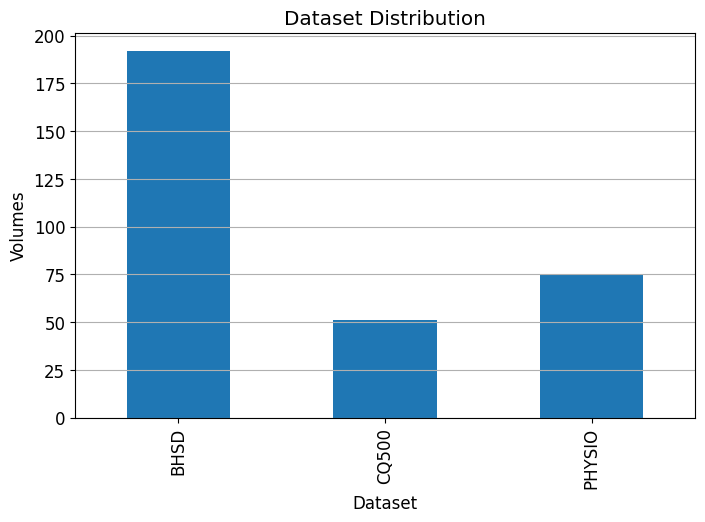

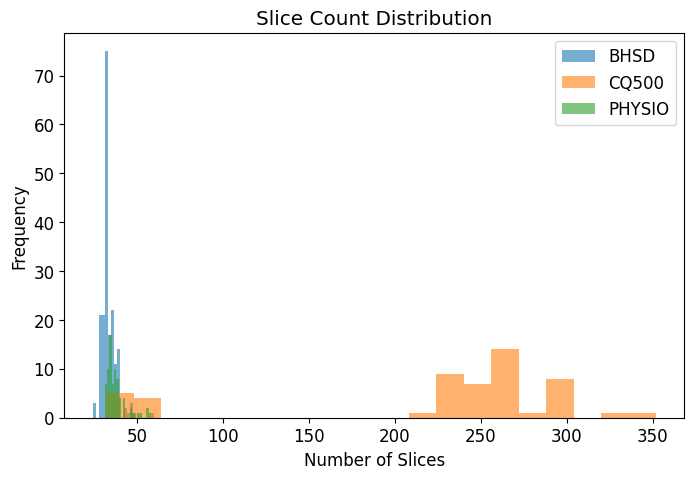

/tmp/ipykernel_76388/1529757662.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data,labels=labels)


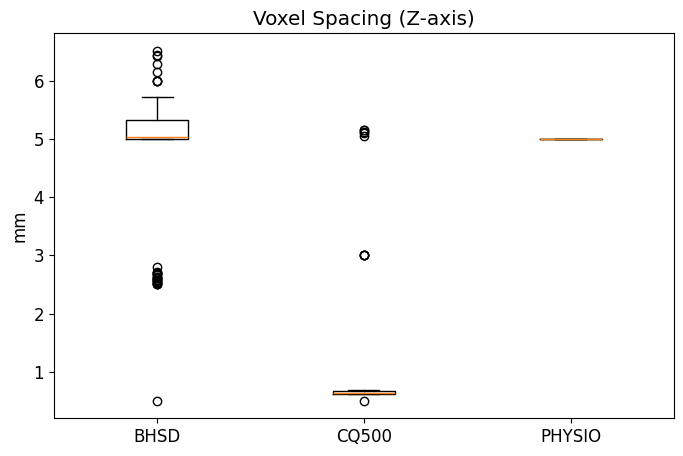

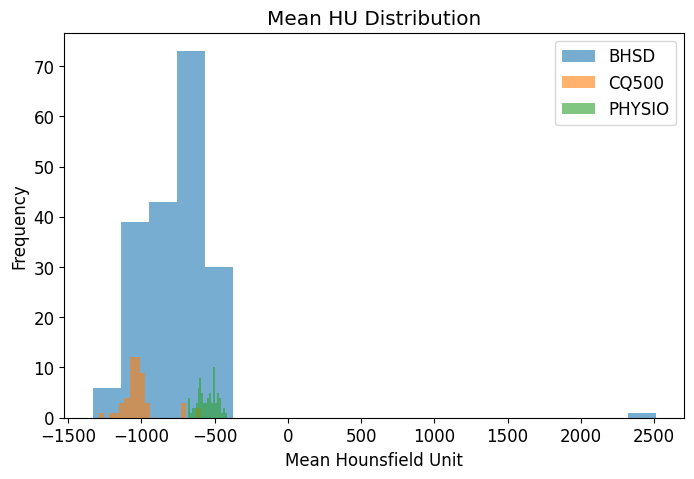

/tmp/ipykernel_76388/1529757662.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data,labels=labels)


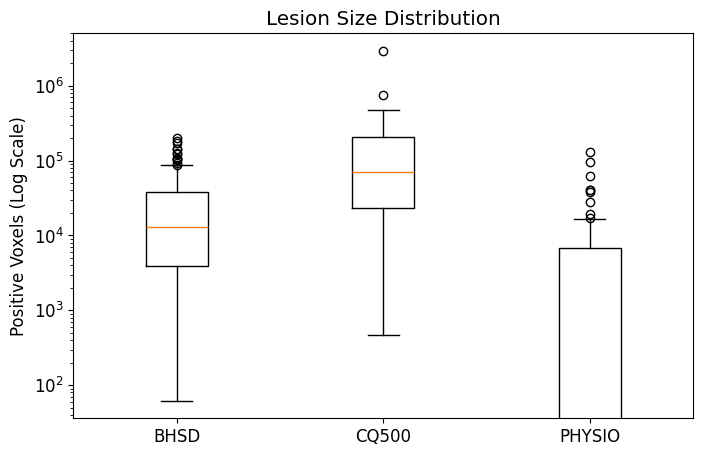

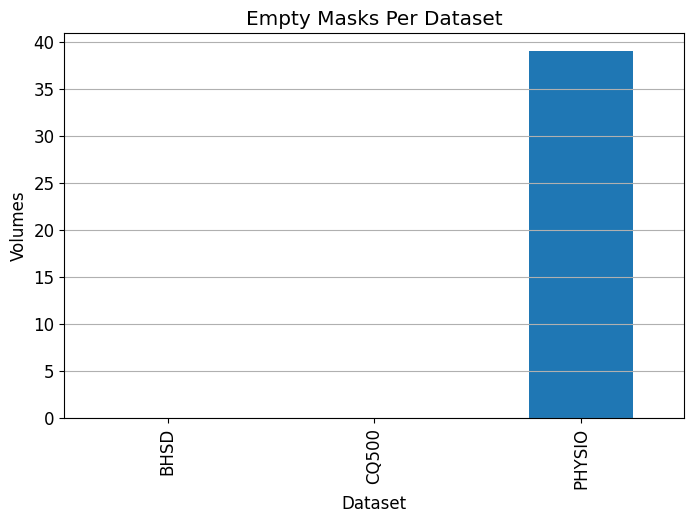

Correlation Matrix


,Shape_Z,Spacing_Z,HU_Mean,HU_STD,Positive_Voxels
Shape_Z,1.000000,-0.898458,-0.393710,0.506696,0.357493
Spacing_Z,-0.898458,1.000000,0.460096,-0.605034,-0.323287
HU_Mean,-0.393710,0.460096,1.000000,-0.649224,-0.157723
HU_STD,0.506696,-0.605034,-0.649224,1.000000,0.184705
Positive_Voxels,0.357493,-0.323287,-0.157723,0.184705,1.000000


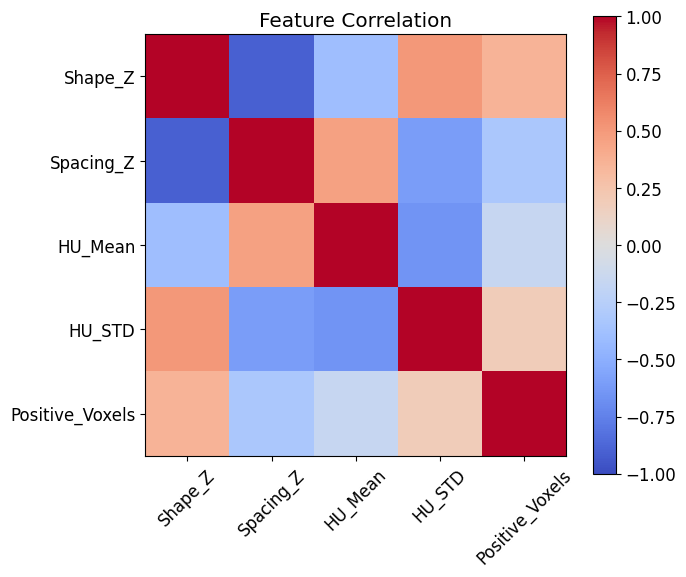

Top 10 Largest Hemorrhages


,Filename,Dataset,Positive_Voxels,Shape_Z,HU_Mean
193,CQ500_0002.nii.gz,CQ500,2930417,256,-1028.778621
228,CQ500_0037.nii.gz,CQ500,753741,233,-1051.035087
219,CQ500_0028.nii.gz,CQ500,472071,256,-1056.588698
212,CQ500_0021.nii.gz,CQ500,443951,325,-728.122491
230,CQ500_0039.nii.gz,CQ500,433937,224,-1034.184398
207,CQ500_0016.nii.gz,CQ500,392971,224,-1026.744747
214,CQ500_0023.nii.gz,CQ500,360745,240,-1191.886241
227,CQ500_0036.nii.gz,CQ500,343546,261,-979.933804
225,CQ500_0034.nii.gz,CQ500,316678,288,-1121.303543
216,CQ500_0025.nii.gz,CQ500,243031,288,-1055.529002



Saved : Dataset_Summary.csv


In [26]:
# ============================================================
# RESEARCH EDA - PART 2
# DATASET-WISE STATISTICAL ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

# ============================================================
# Load Metadata
# ============================================================

df = pd.read_csv("EDA_Master_Metadata.csv")

print("="*80)
print("DATASET SUMMARY")
print("="*80)

summary = df.groupby("Dataset").agg({

    "Filename":"count",

    "Shape_Z":["mean","median","min","max"],

    "Spacing_X":"mean",
    "Spacing_Y":"mean",
    "Spacing_Z":"mean",

    "HU_Min":"mean",
    "HU_Max":"mean",
    "HU_Mean":"mean",
    "HU_STD":"mean",

    "Positive_Voxels":["mean","median","max"],

    "Empty_Mask":"sum"

})

display(summary)

# ============================================================
# Dataset Distribution
# ============================================================

plt.figure()

df["Dataset"].value_counts().sort_index().plot(kind="bar")

plt.title("Dataset Distribution")
plt.ylabel("Volumes")
plt.grid(axis="y")

plt.show()

# ============================================================
# Slice Count Distribution
# ============================================================

plt.figure()

for d in sorted(df.Dataset.unique()):

    plt.hist(
        df[df.Dataset==d]["Shape_Z"],
        bins=20,
        alpha=0.6,
        label=d
    )

plt.title("Slice Count Distribution")
plt.xlabel("Number of Slices")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# ============================================================
# Z Spacing Distribution
# ============================================================

plt.figure()

data=[]

labels=[]

for d in sorted(df.Dataset.unique()):

    data.append(df[df.Dataset==d]["Spacing_Z"])

    labels.append(d)

plt.boxplot(data,labels=labels)

plt.title("Voxel Spacing (Z-axis)")
plt.ylabel("mm")

plt.show()

# ============================================================
# Mean HU Distribution
# ============================================================

plt.figure()

for d in sorted(df.Dataset.unique()):

    plt.hist(

        df[df.Dataset==d]["HU_Mean"],

        bins=20,

        alpha=0.6,

        label=d

    )

plt.title("Mean HU Distribution")

plt.xlabel("Mean Hounsfield Unit")

plt.ylabel("Frequency")

plt.legend()

plt.show()

# ============================================================
# Positive Voxels
# ============================================================

plt.figure()

data=[]

labels=[]

for d in sorted(df.Dataset.unique()):

    data.append(

        df[df.Dataset==d]["Positive_Voxels"]

    )

    labels.append(d)

plt.boxplot(data,labels=labels)

plt.yscale("log")

plt.ylabel("Positive Voxels (Log Scale)")

plt.title("Lesion Size Distribution")

plt.show()

# ============================================================
# Empty Masks
# ============================================================

empty = df.groupby("Dataset")["Empty_Mask"].sum()

plt.figure()

empty.plot(kind="bar")

plt.ylabel("Volumes")

plt.title("Empty Masks Per Dataset")

plt.grid(axis="y")

plt.show()

# ============================================================
# Shape Correlation
# ============================================================

corr = df[[
    "Shape_Z",
    "Spacing_Z",
    "HU_Mean",
    "HU_STD",
    "Positive_Voxels"
]].corr()

print("="*80)
print("Correlation Matrix")
print("="*80)

display(corr)

plt.figure(figsize=(7,6))

plt.imshow(corr,cmap="coolwarm",vmin=-1,vmax=1)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.title("Feature Correlation")

plt.tight_layout()

plt.show()

# ============================================================
# Largest Lesions
# ============================================================

print("="*80)
print("Top 10 Largest Hemorrhages")
print("="*80)

display(

df.sort_values(

    "Positive_Voxels",

    ascending=False

)[

["Filename",

"Dataset",

"Positive_Voxels",

"Shape_Z",

"HU_Mean"]

].head(10)

)

# ============================================================
# Save Summary
# ============================================================

summary.to_csv("Dataset_Summary.csv")

print("\nSaved : Dataset_Summary.csv")

100%|██████████| 318/318 [12:06<00:00,  2.29s/it]


,Filename,Dataset,Slices,Positive_Slices,Lesion_mm3,HU_1,HU_5,HU_50,HU_95,HU_99
0,BHSD_0001.nii.gz,BHSD,28,7,11061.875374,-2048.000000,-2048.000000,-988.034635,730.015343,1541.978495
1,BHSD_0002.nii.gz,BHSD,28,19,41196.791662,-3024.000031,-3024.000031,-999.015791,325.015425,1007.036671
2,BHSD_0003.nii.gz,BHSD,32,14,105491.403754,-3024.000122,-3024.000122,-988.000224,694.992564,1234.037676
3,BHSD_0004.nii.gz,BHSD,31,8,41805.505753,-1008.997635,-1006.013977,-959.998414,397.986007,927.017907
4,BHSD_0005.nii.gz,BHSD,32,17,21397.399902,-1007.998901,-1005.024338,-245.023442,470.000008,1073.990194


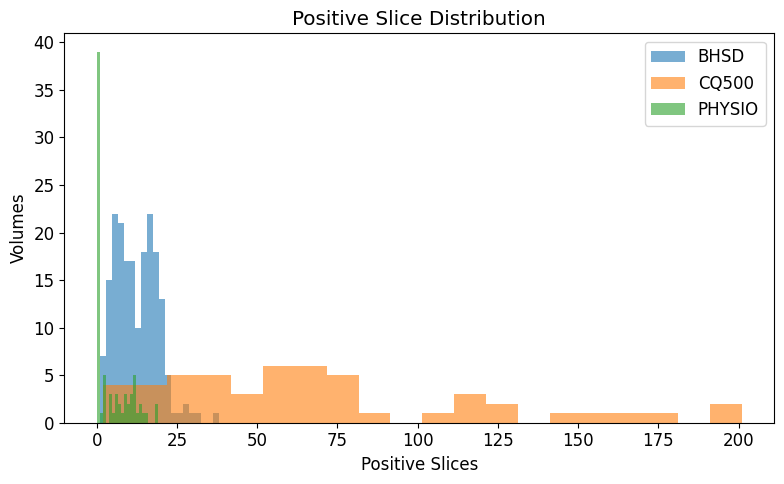

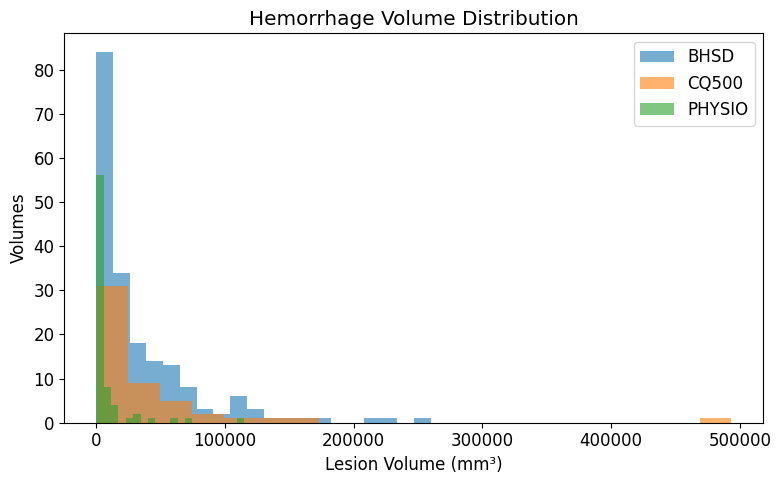

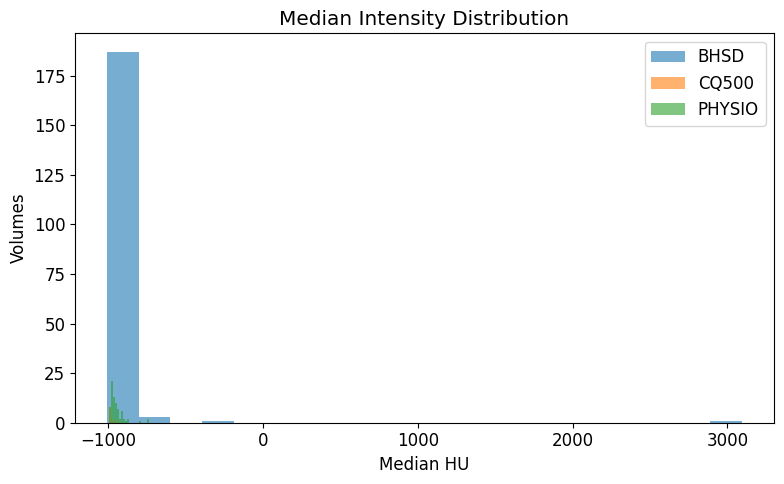

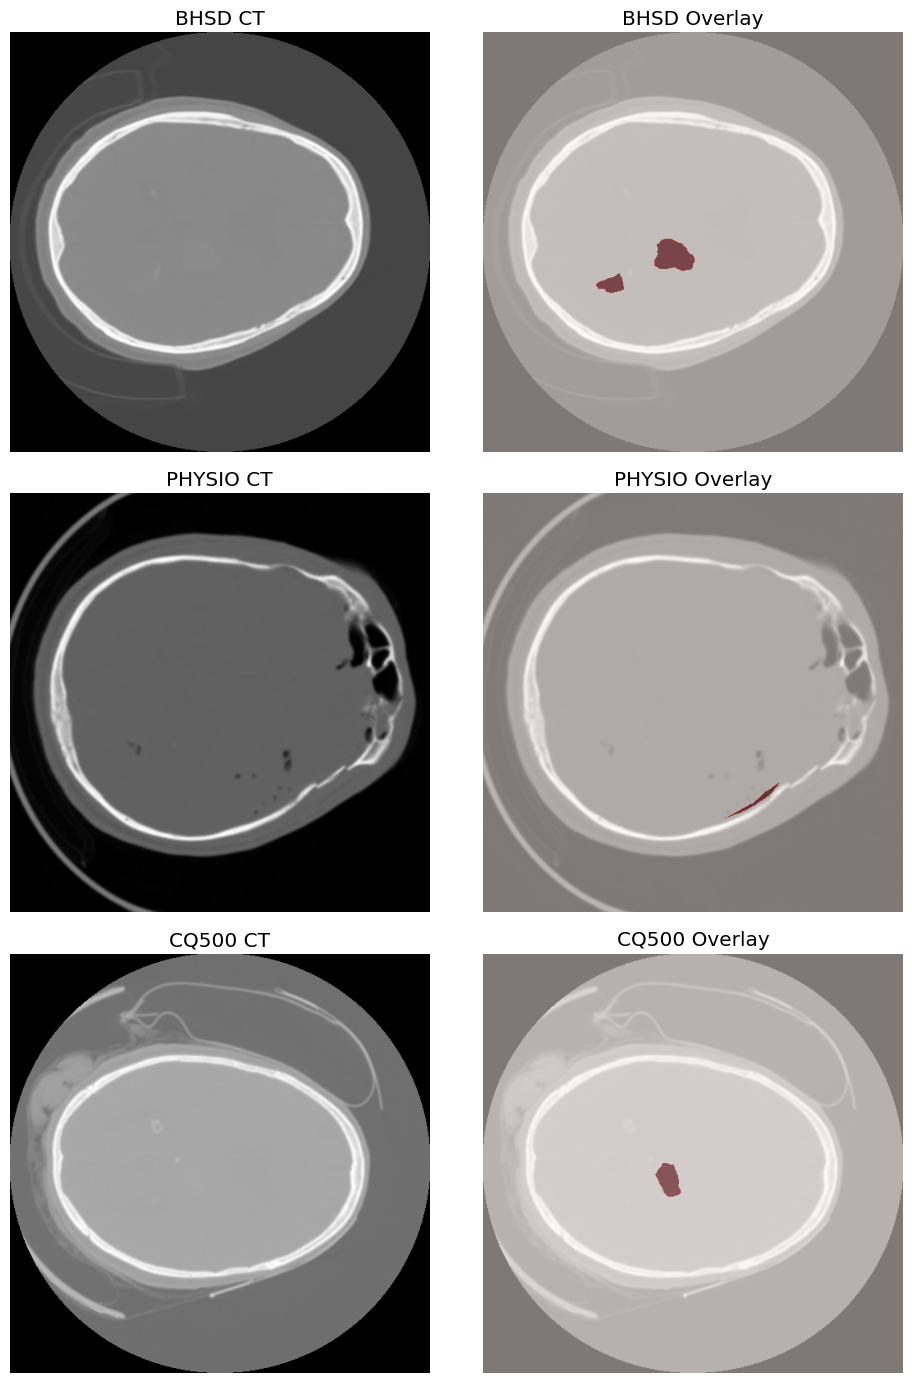

IMAGE ANALYSIS SUMMARY


Positive_Slices                Lesion_mm3                \
                   mean median  max          mean        median   
Dataset                                                           
BHSD          12.333333   12.0   38  33155.477891  15008.682402   
CQ500         68.627451   58.0  201  37811.292001  15444.458384   
PHYSIO         4.240000    0.0   19   7248.534708      0.000000   

                             HU_50  
                   max        mean  
Dataset                             
BHSD     260022.757470 -931.884625  
CQ500    493415.644415 -977.825078  
PHYSIO   115017.626762 -944.078849


Saved:
EDA_Image_Metadata.csv
EDA_Image_Summary.csv
Figures -> EDA_Figures


In [28]:
# ============================================================
# RESEARCH EDA - PART 3
# MEDICAL IMAGE ANALYSIS
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

IMAGE_DIR = Path("/workspace/Hemorrhage_SOTA_V2/processed/images")
MASK_DIR  = Path("/workspace/Hemorrhage_SOTA_V2/processed/masks")

SAVE_DIR = Path("EDA_Figures")
SAVE_DIR.mkdir(exist_ok=True)

records = []

# ------------------------------------------------------------
# Analyze every volume
# ------------------------------------------------------------

for img_path in tqdm(sorted(IMAGE_DIR.glob("*.nii.gz"))):

    mask_path = MASK_DIR / img_path.name

    img = nib.load(str(img_path))
    mask = nib.load(str(mask_path))

    image = img.get_fdata()
    mask_data = mask.get_fdata()

    spacing = img.header.get_zooms()

    if img_path.name.startswith("BHSD"):
        dataset = "BHSD"
    elif img_path.name.startswith("CQ500"):
        dataset = "CQ500"
    else:
        dataset = "PHYSIO"

    # --------------------------------------------------------
    # Positive slices
    # --------------------------------------------------------

    positive_slices = np.sum(mask_data.reshape(-1, mask_data.shape[-1]).sum(axis=0) > 0)

    # --------------------------------------------------------
    # Lesion Volume
    # --------------------------------------------------------

    voxel_volume = spacing[0] * spacing[1] * spacing[2]

    lesion_volume = np.sum(mask_data > 0) * voxel_volume

    # --------------------------------------------------------
    # Intensity Percentiles
    # --------------------------------------------------------

    p1 = np.percentile(image,1)
    p5 = np.percentile(image,5)
    p50 = np.percentile(image,50)
    p95 = np.percentile(image,95)
    p99 = np.percentile(image,99)

    records.append({

        "Filename":img_path.name,

        "Dataset":dataset,

        "Slices":image.shape[2],

        "Positive_Slices":positive_slices,

        "Lesion_mm3":lesion_volume,

        "HU_1":p1,
        "HU_5":p5,
        "HU_50":p50,
        "HU_95":p95,
        "HU_99":p99

    })

df = pd.DataFrame(records)

display(df.head())

# ============================================================
# Positive Slice Distribution
# ============================================================

plt.figure(figsize=(8,5))

for d in sorted(df.Dataset.unique()):

    plt.hist(

        df[df.Dataset==d]["Positive_Slices"],

        bins=20,

        alpha=0.6,

        label=d

    )

plt.legend()

plt.xlabel("Positive Slices")

plt.ylabel("Volumes")

plt.title("Positive Slice Distribution")

plt.tight_layout()

plt.savefig(SAVE_DIR/"Positive_Slices.png",dpi=300)

plt.show()

# ============================================================
# Lesion Volume Distribution
# ============================================================

plt.figure(figsize=(8,5))

for d in sorted(df.Dataset.unique()):

    plt.hist(

        df[df.Dataset==d]["Lesion_mm3"],

        bins=20,

        alpha=0.6,

        label=d

    )

plt.legend()

plt.xlabel("Lesion Volume (mm³)")

plt.ylabel("Volumes")

plt.title("Hemorrhage Volume Distribution")

plt.tight_layout()

plt.savefig(SAVE_DIR/"Lesion_Volume.png",dpi=300)

plt.show()

# ============================================================
# Intensity Percentiles
# ============================================================

plt.figure(figsize=(8,5))

for d in sorted(df.Dataset.unique()):

    plt.hist(

        df[df.Dataset==d]["HU_50"],

        bins=20,

        alpha=0.6,

        label=d

    )

plt.legend()

plt.xlabel("Median HU")

plt.ylabel("Volumes")

plt.title("Median Intensity Distribution")

plt.tight_layout()

plt.savefig(SAVE_DIR/"Median_HU.png",dpi=300)

plt.show()

# ============================================================
# Representative Samples
# ============================================================

datasets=["BHSD","PHYSIO","CQ500"]

fig,axes=plt.subplots(3,2,figsize=(10,14))

for row,dataset in enumerate(datasets):

    sample = sorted(IMAGE_DIR.glob(f"{dataset}*.nii.gz"))[0]

    img = nib.load(sample).get_fdata()

    mask = nib.load(MASK_DIR/sample.name).get_fdata()

    z = img.shape[2]//2

    axes[row,0].imshow(img[:,:,z],cmap="gray")

    axes[row,0].set_title(f"{dataset} CT")

    axes[row,0].axis("off")

    axes[row,1].imshow(img[:,:,z],cmap="gray")

    axes[row,1].imshow(mask[:,:,z],alpha=0.5,cmap="Reds")

    axes[row,1].set_title(f"{dataset} Overlay")

    axes[row,1].axis("off")

plt.tight_layout()

plt.savefig(SAVE_DIR/"Representative_Samples.png",dpi=300)

plt.show()

# ============================================================
# Summary Table
# ============================================================

summary=df.groupby("Dataset").agg({

    "Positive_Slices":["mean","median","max"],

    "Lesion_mm3":["mean","median","max"],

    "HU_50":"mean"

})

print("="*80)
print("IMAGE ANALYSIS SUMMARY")
print("="*80)

display(summary)

summary.to_csv("EDA_Image_Summary.csv")

df.to_csv("EDA_Image_Metadata.csv",index=False)

print("\nSaved:")
print("EDA_Image_Metadata.csv")
print("EDA_Image_Summary.csv")
print("Figures ->",SAVE_DIR)

FINAL DATASET REPORT


,Volumes,Mean_Coverage,Median_Coverage,Max_Coverage,Mean_Lesion_mm3,Mean_Depth,Empty
Dataset,,,,,,,
BHSD,318,0.270822,0.108907,4.366662,27795.977221,19.45283,39


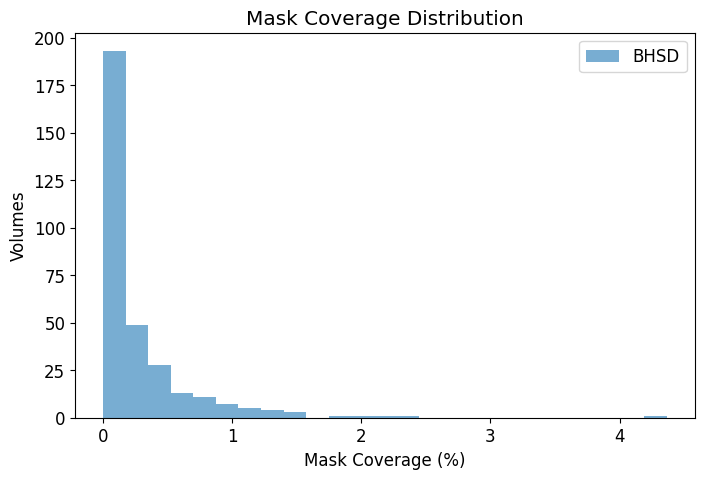

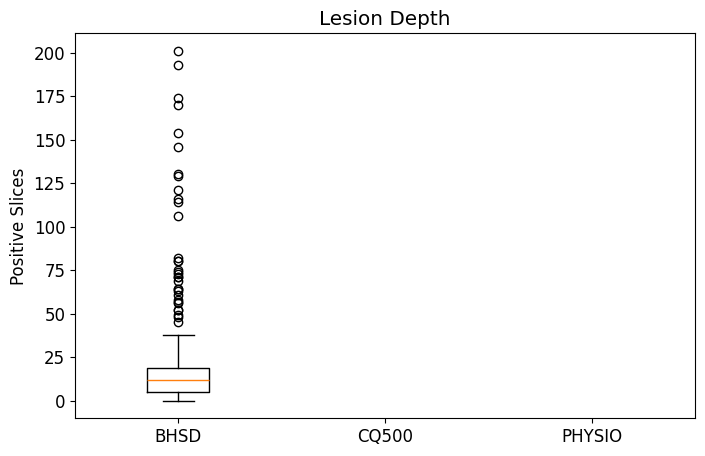

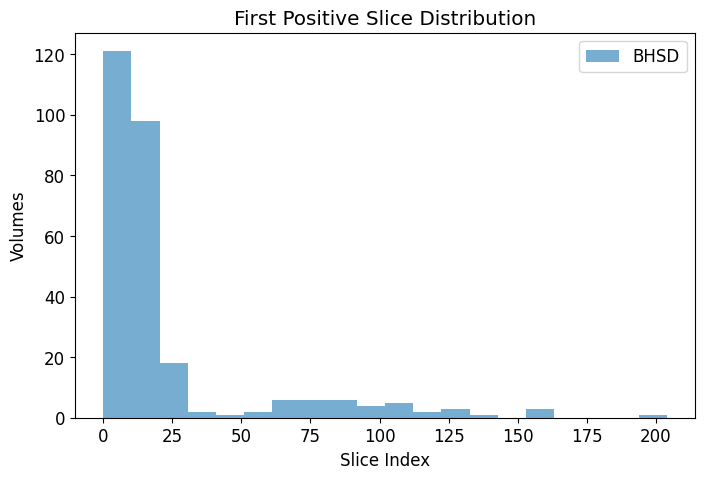



TOP 20 LARGEST LESIONS


,Filename,Dataset,Lesion_mm3,Coverage_%,Lesion_Depth
193,CQ500_0002.nii.gz,BHSD,493415.644415,4.366662,170
35,BHSD_0036.nii.gz,BHSD,260022.733362,2.410746,22
153,BHSD_0154.nii.gz,BHSD,227811.213810,2.147543,20
72,BHSD_0073.nii.gz,BHSD,218500.577436,2.025938,22
25,BHSD_0026.nii.gz,BHSD,174585.844265,1.295617,26
236,CQ500_0045.nii.gz,BHSD,166797.547068,0.991104,37
6,BHSD_0007.nii.gz,BHSD,162155.313689,1.503479,16
109,BHSD_0110.nii.gz,BHSD,154741.377956,1.371179,17
85,BHSD_0086.nii.gz,BHSD,133324.142388,1.240480,17
122,BHSD_0123.nii.gz,BHSD,129252.672195,1.181739,18




TOP 20 SMALLEST LESIONS


,Filename,Dataset,Lesion_mm3,Coverage_%,Lesion_Depth
78,BHSD_0079.nii.gz,BHSD,52.452035,0.000839,1
21,BHSD_0022.nii.gz,BHSD,52.648582,0.000739,2
108,BHSD_0109.nii.gz,BHSD,109.672546,0.001003,1
124,BHSD_0125.nii.gz,BHSD,113.139071,0.001085,2
266,INSTANCE_0024.nii.gz,BHSD,130.462646,0.001631,1
164,BHSD_0165.nii.gz,BHSD,141.859055,0.001261,4
134,BHSD_0135.nii.gz,BHSD,152.229338,0.001431,3
49,BHSD_0050.nii.gz,BHSD,178.716596,0.001828,2
116,BHSD_0117.nii.gz,BHSD,199.147017,0.003497,4
100,BHSD_0101.nii.gz,BHSD,226.285166,0.003357,3



Saved
Dataset_Final_Report.csv
Dataset_Final_Metadata.csv


In [29]:
# ============================================================
# RESEARCH EDA - PART 5
# Final Dataset Validation
# ============================================================

import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# DATASET PATHS
# ============================================================

DATASETS = {
    "BHSD": (
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/images"),
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/mask")
    ),
    "PHYSIO": (
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet/images"),
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet/masks")
    ),
    "CQ500": (
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/CQ500/images"),
        Path("/workspace/Hemorrhage_SOTA_V2/dataset/CQ500/masks")
    )
}

rows=[]

# ============================================================
# ANALYSIS
# ============================================================

for dataset,(img_dir,mask_dir) in DATASETS.items():

    if not img_dir.exists():
        continue

    for img_path in sorted(img_dir.glob("*.nii*")):

        mask_path = mask_dir / img_path.name

        if not mask_path.exists():
            continue

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        mask_data = mask.get_fdata()

        positive = mask_data>0

        spacing = img.header.get_zooms()[:3]

        total_voxels = mask_data.size
        positive_voxels = positive.sum()

        coverage = positive_voxels/total_voxels*100

        lesion_volume = positive_voxels*np.prod(spacing)

        # slice analysis
        positive_slices=np.where(positive.any(axis=(0,1)))[0]

        if len(positive_slices)>0:

            first_slice=positive_slices[0]
            last_slice=positive_slices[-1]
            lesion_depth=len(positive_slices)

        else:

            first_slice=np.nan
            last_slice=np.nan
            lesion_depth=0

        rows.append({

            "Dataset":dataset,
            "Filename":img_path.name,

            "Slices":mask_data.shape[2],

            "Positive_Voxels":positive_voxels,

            "Coverage_%":coverage,

            "Lesion_mm3":lesion_volume,

            "First_Slice":first_slice,

            "Last_Slice":last_slice,

            "Lesion_Depth":lesion_depth

        })

df=pd.DataFrame(rows)

# ============================================================
# SUMMARY TABLE
# ============================================================

summary=df.groupby("Dataset").agg(

    Volumes=("Filename","count"),

    Mean_Coverage=("Coverage_%","mean"),
    Median_Coverage=("Coverage_%","median"),
    Max_Coverage=("Coverage_%","max"),

    Mean_Lesion_mm3=("Lesion_mm3","mean"),

    Mean_Depth=("Lesion_Depth","mean"),

    Empty=("Positive_Voxels",lambda x:(x==0).sum())

)

print("="*80)
print("FINAL DATASET REPORT")
print("="*80)

display(summary)

# ============================================================
# COVERAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

for d in df.Dataset.unique():

    plt.hist(
        df[df.Dataset==d]["Coverage_%"],
        bins=25,
        alpha=.6,
        label=d
    )

plt.legend()
plt.xlabel("Mask Coverage (%)")
plt.ylabel("Volumes")
plt.title("Mask Coverage Distribution")
plt.show()

# ============================================================
# LESION DEPTH
# ============================================================

plt.figure(figsize=(8,5))

data=[

    df[df.Dataset=="BHSD"]["Lesion_Depth"],
    df[df.Dataset=="CQ500"]["Lesion_Depth"],
    df[df.Dataset=="PHYSIO"]["Lesion_Depth"]

]

plt.boxplot(data,tick_labels=["BHSD","CQ500","PHYSIO"])

plt.ylabel("Positive Slices")
plt.title("Lesion Depth")
plt.show()

# ============================================================
# FIRST POSITIVE SLICE
# ============================================================

plt.figure(figsize=(8,5))

for d in df.Dataset.unique():

    plt.hist(

        df[df.Dataset==d]["First_Slice"].dropna(),

        bins=20,

        alpha=.6,

        label=d

    )

plt.legend()
plt.xlabel("Slice Index")
plt.ylabel("Volumes")
plt.title("First Positive Slice Distribution")
plt.show()

# ============================================================
# LARGEST LESIONS
# ============================================================

print("\n")
print("="*80)
print("TOP 20 LARGEST LESIONS")
print("="*80)

display(

df.sort_values(

    "Lesion_mm3",

    ascending=False

)[

["Filename",

"Dataset",

"Lesion_mm3",

"Coverage_%",

"Lesion_Depth"]

].head(20)

)

# ============================================================
# SMALLEST NON-ZERO LESIONS
# ============================================================

print("\n")
print("="*80)
print("TOP 20 SMALLEST LESIONS")
print("="*80)

display(

df[df.Positive_Voxels>0]

.sort_values(

"Lesion_mm3"

)[

["Filename",

"Dataset",

"Lesion_mm3",

"Coverage_%",

"Lesion_Depth"]

].head(20)

)

# ============================================================
# SAVE
# ============================================================

summary.to_csv("Dataset_Final_Report.csv")

df.to_csv("Dataset_Final_Metadata.csv",index=False)

print("\nSaved")
print("Dataset_Final_Report.csv")
print("Dataset_Final_Metadata.csv")

In [30]:
# ==============================================================================
# FINAL DATASET REPORT (FIXED)
# ==============================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# Recover Dataset Name (Fix)
# ------------------------------------------------------------------------------

def recover_dataset(filename):
    f = filename.upper()

    if f.startswith("BHSD"):
        return "BHSD"

    elif f.startswith("CQ500"):
        return "CQ500"

    elif f.startswith("INSTANCE") or f.startswith("ID_") or "PHYSIO" in f:
        return "PHYSIO"

    return "UNKNOWN"


df["Dataset"] = df["Filename"].apply(recover_dataset)

print("="*80)
print("Dataset Counts (Recovered)")
print("="*80)
print(df["Dataset"].value_counts())
print()


# ------------------------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------------------------

summary = (
    df.groupby("Dataset")
      .agg(
          Volumes=("Filename","count"),
          Mean_Slices=("Slices","mean"),
          Median_Slices=("Slices","median"),
          Mean_Coverage=("Coverage_%","mean"),
          Median_Coverage=("Coverage_%","median"),
          Mean_Lesion_mm3=("Lesion_mm3","mean"),
          Median_Lesion_mm3=("Lesion_mm3","median"),
          Mean_Depth=("Lesion_Depth","mean"),
          Empty=("Positive_Slices",lambda x:(x==0).sum())
      )
      .round(3)
)

summary.loc["TOTAL"] = [
    len(df),
    df["Slices"].mean(),
    df["Slices"].median(),
    df["Coverage_%"].mean(),
    df["Coverage_%"].median(),
    df["Lesion_mm3"].mean(),
    df["Lesion_mm3"].median(),
    df["Lesion_Depth"].mean(),
    (df["Positive_Slices"]==0).sum()
]

display(summary)


# ------------------------------------------------------------------------------
# Dataset Percentage
# ------------------------------------------------------------------------------

print("="*80)
print("DATASET DISTRIBUTION")
print("="*80)

dist = (
    df["Dataset"]
    .value_counts()
    .rename("Volumes")
    .to_frame()
)

dist["Percentage"] = (
    dist["Volumes"] /
    dist["Volumes"].sum() * 100
).round(2)

display(dist)


# ------------------------------------------------------------------------------
# Image Size Consistency
# ------------------------------------------------------------------------------

print("="*80)
print("IMAGE SIZE CONSISTENCY")
print("="*80)

size_table = (
    df.groupby(["Shape_X","Shape_Y"])
      .size()
      .reset_index(name="Volumes")
)

display(size_table)


# ------------------------------------------------------------------------------
# Missing Data Report
# ------------------------------------------------------------------------------

print("="*80)
print("QUALITY REPORT")
print("="*80)

print(f"Missing Images      : {df['Filename'].isna().sum()}")
print(f"Missing Dataset     : {(df.Dataset=='UNKNOWN').sum()}")
print(f"Empty Masks         : {(df.Positive_Slices==0).sum()}")
print(f"Duplicate Files     : {df.Filename.duplicated().sum()}")
print(f"Total Volumes       : {len(df)}")
print()


# ------------------------------------------------------------------------------
# Top Largest Lesions
# ------------------------------------------------------------------------------

print("="*80)
print("TOP 20 LARGEST LESIONS")
print("="*80)

display(
    df.sort_values(
        "Lesion_mm3",
        ascending=False
    )[
        [
            "Filename",
            "Dataset",
            "Lesion_mm3",
            "Coverage_%",
            "Lesion_Depth"
        ]
    ].head(20)
)


# ------------------------------------------------------------------------------
# Smallest Lesions
# ------------------------------------------------------------------------------

print("="*80)
print("TOP 20 SMALLEST LESIONS")
print("="*80)

display(
    df[
        df["Lesion_mm3"]>0
    ].sort_values(
        "Lesion_mm3"
    )[
        [
            "Filename",
            "Dataset",
            "Lesion_mm3",
            "Coverage_%",
            "Lesion_Depth"
        ]
    ].head(20)
)


# ------------------------------------------------------------------------------
# Intensity Statistics
# ------------------------------------------------------------------------------

print("="*80)
print("HU PERCENTILES")
print("="*80)

hu_cols = [
    "HU_1",
    "HU_5",
    "HU_50",
    "HU_95",
    "HU_99"
]

display(
    df.groupby("Dataset")[hu_cols]
      .mean()
      .round(2)
)


# ------------------------------------------------------------------------------
# Final Dataset Summary
# ------------------------------------------------------------------------------

print("="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print(f"Datasets                : {df.Dataset.nunique()}")
print(f"Total Volumes           : {len(df)}")
print(f"BHSD                    : {(df.Dataset=='BHSD').sum()}")
print(f"CQ500                   : {(df.Dataset=='CQ500').sum()}")
print(f"PHYSIO                  : {(df.Dataset=='PHYSIO').sum()}")
print()

print(f"Average Slice Count     : {df.Slices.mean():.2f}")
print(f"Average Lesion Volume   : {df.Lesion_mm3.mean():.2f} mm³")
print(f"Average Coverage        : {df.Coverage_.mean():.3f} %" if "Coverage_" in df.columns else f"Average Coverage        : {df['Coverage_%'].mean():.3f} %")
print(f"Average Lesion Depth    : {df.Lesion_Depth.mean():.2f} slices")
print()

print(f"Recommended Window      : [-100, 200] HU")
print(f"Recommended Spacing     : 0.5 × 0.5 × 5.0 mm")
print(f"Recommended Image Size  : 512 × 512")
print(f"Recommended Patch Size  : 128 × 128 × 16")

# ------------------------------------------------------------------------------
# Save
# ------------------------------------------------------------------------------

summary.to_csv("Dataset_Final_Report.csv")
df.to_csv("Dataset_Final_Metadata.csv", index=False)

print()
print("Saved:")
print("Dataset_Final_Report.csv")
print("Dataset_Final_Metadata.csv")

Dataset Counts (Recovered)
Dataset
BHSD      192
PHYSIO     75
CQ500      51
Name: count, dtype: int64



KeyError: "Column(s) ['Positive_Slices'] do not exist"

In [31]:
import os
import shutil

ROOT = "/workspace/Hemorrhage_SOTA_V2/dataset"

OLD_IMAGES = os.path.join(ROOT, "images")
OLD_MASKS  = os.path.join(ROOT, "mask")

print("="*70)
print("Removing old combined dataset...")
print("="*70)

for path in [OLD_IMAGES, OLD_MASKS]:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Deleted : {path}")

os.makedirs(OLD_IMAGES, exist_ok=True)
os.makedirs(OLD_MASKS, exist_ok=True)

print("\nCreated fresh folders")
print(OLD_IMAGES)
print(OLD_MASKS)

print("\nDone.")

Removing old combined dataset...
Deleted : /workspace/Hemorrhage_SOTA_V2/dataset/images
Deleted : /workspace/Hemorrhage_SOTA_V2/dataset/mask

Created fresh folders
/workspace/Hemorrhage_SOTA_V2/dataset/images
/workspace/Hemorrhage_SOTA_V2/dataset/mask

Done.


In [32]:
# ============================================================
# RECOVER BHSD DATASET
# ============================================================

import os
import shutil
from pathlib import Path

import nibabel as nib
import numpy as np
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

BHSD_IMAGES = ROOT/"BHSD"/"label_192"/"images"
BHSD_MASKS  = ROOT/"BHSD"/"label_192"/"ground truths"

OUT_IMAGES = ROOT/"images"
OUT_MASKS  = ROOT/"mask"

OUT_IMAGES.mkdir(exist_ok=True)
OUT_MASKS.mkdir(exist_ok=True)

# ============================================================
# FILES
# ============================================================

img_files = sorted(BHSD_IMAGES.glob("*.nii.gz"))
mask_files = sorted(BHSD_MASKS.glob("*.nii.gz"))

assert len(img_files) == len(mask_files)

print("="*70)
print("BHSD RECOVERY")
print("="*70)
print("Images :", len(img_files))
print("Masks  :", len(mask_files))
print()

# ============================================================
# RECOVERY
# ============================================================

success = 0
failed = []

for i, (img_path, mask_path) in enumerate(tqdm(zip(img_files, mask_files),
                                               total=len(img_files))):

    try:

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        img_data = img.get_fdata(dtype=np.float32)
        mask_data = mask.get_fdata(dtype=np.float32)

        img_new = nib.Nifti1Image(img_data, img.affine)
        img_new.header.set_zooms(img.header.get_zooms())

        mask_new = nib.Nifti1Image(mask_data, mask.affine)
        mask_new.header.set_zooms(mask.header.get_zooms())

        out_img = OUT_IMAGES/f"BHSD_{i+1:04d}.nii.gz"
        out_mask = OUT_MASKS/f"BHSD_{i+1:04d}.nii.gz"

        nib.save(img_new, out_img)
        nib.save(mask_new, out_mask)

        success += 1

    except Exception as e:
        failed.append((img_path.name, str(e)))

# ============================================================
# REPORT
# ============================================================

print()
print("="*70)
print("BHSD RECOVERY COMPLETE")
print("="*70)

print("Recovered :", success)
print("Failed    :", len(failed))

if failed:

    print("\nFailed Files\n")

    for f,e in failed:
        print(f)
        print(e)
        print("-"*60)

# ============================================================
# VERIFY
# ============================================================

print("\nVerifying...")

good = 0

for f in sorted(OUT_IMAGES.glob("BHSD*.nii.gz")):

    try:
        nib.load(str(f)).get_fdata()
        good += 1
    except:
        pass

print()

print("Verified :", good)
print("Expected :", success)

print("="*70)

BHSD RECOVERY
Images : 192
Masks  : 192



100%|██████████| 192/192 [02:15<00:00,  1.41it/s]



BHSD RECOVERY COMPLETE
Recovered : 192
Failed    : 0

Verifying...

Verified : 192
Expected : 192


In [33]:
# ============================================================
# RECOVER PHYSIONET DATASET
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

# ---------------- CHANGE THESE IF YOUR PATHS DIFFER ----------------
PHYSIO_IMAGES = ROOT/"PhysioNet"/"images"
PHYSIO_MASKS  = ROOT/"PhysioNet"/"masks"
# -------------------------------------------------------------------

OUT_IMAGES = ROOT/"images"
OUT_MASKS  = ROOT/"mask"

img_files = sorted(PHYSIO_IMAGES.glob("*.nii.gz"))
mask_files = sorted(PHYSIO_MASKS.glob("*.nii.gz"))

print("="*70)
print("PHYSIONET RECOVERY")
print("="*70)
print("Images :", len(img_files))
print("Masks  :", len(mask_files))
print()

assert len(img_files) == len(mask_files)

success = 0
failed = []

for i,(img_path,mask_path) in enumerate(tqdm(zip(img_files,mask_files),
                                             total=len(img_files))):

    try:

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        img_data = img.get_fdata(dtype=np.float32)
        mask_data = mask.get_fdata(dtype=np.float32)

        img_new = nib.Nifti1Image(img_data, img.affine)
        img_new.header.set_zooms(img.header.get_zooms())

        mask_new = nib.Nifti1Image(mask_data, mask.affine)
        mask_new.header.set_zooms(mask.header.get_zooms())

        nib.save(
            img_new,
            OUT_IMAGES/f"PHYSIO_{i+1:04d}.nii.gz"
        )

        nib.save(
            mask_new,
            OUT_MASKS/f"PHYSIO_{i+1:04d}.nii.gz"
        )

        success += 1

    except Exception as e:

        failed.append((img_path.name,str(e)))

print()

print("="*70)
print("PHYSIONET RECOVERY COMPLETE")
print("="*70)

print("Recovered :",success)
print("Failed    :",len(failed))

if failed:
    print()
    for f,e in failed:
        print(f)
        print(e)
        print("-"*60)

# --------------------------------------------------------
# VERIFY
# --------------------------------------------------------

good = 0

for f in sorted(OUT_IMAGES.glob("PHYSIO*.nii.gz")):

    try:
        nib.load(str(f)).get_fdata()
        good += 1
    except:
        pass

print()
print("Verified :",good)
print("Expected :",success)
print("="*70)

PHYSIONET RECOVERY
Images : 0
Masks  : 0



0it [00:00, ?it/s]


PHYSIONET RECOVERY COMPLETE
Recovered : 0
Failed    : 0

Verified : 0
Expected : 0


In [34]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

for p in ROOT.rglob("049.nii"):
    print(p)

/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans/049.nii
/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/masks/049.nii


In [35]:
# ============================================================
# RECOVER PHYSIONET (75 CASES)
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

SRC_IMAGES = ROOT / "PhysioNet" / "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1" / "ct_scans"
SRC_MASKS  = ROOT / "PhysioNet" / "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1" / "masks"

OUT_IMAGES = ROOT / "images"
OUT_MASKS  = ROOT / "mask"

OUT_IMAGES.mkdir(exist_ok=True)
OUT_MASKS.mkdir(exist_ok=True)

img_files = sorted(SRC_IMAGES.glob("*.nii"))
mask_files = sorted(SRC_MASKS.glob("*.nii"))

print("="*70)
print("PHYSIONET RECOVERY")
print("="*70)
print("Images :", len(img_files))
print("Masks  :", len(mask_files))
print()

assert len(img_files) == len(mask_files), "Image/Mask count mismatch!"

success = 0
failed = []

for i, (img_path, mask_path) in enumerate(
    tqdm(zip(img_files, mask_files), total=len(img_files))
):

    try:

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        img_data = img.get_fdata().astype(np.float32)
        mask_data = (mask.get_fdata() > 0).astype(np.uint8)

        img_new = nib.Nifti1Image(img_data, img.affine, img.header)
        mask_new = nib.Nifti1Image(mask_data, mask.affine, mask.header)

        img_out = OUT_IMAGES / f"PHYSIO_{i+1:04d}.nii.gz"
        mask_out = OUT_MASKS / f"PHYSIO_{i+1:04d}.nii.gz"

        nib.save(img_new, str(img_out))
        nib.save(mask_new, str(mask_out))

        success += 1

    except Exception as e:
        failed.append((img_path.name, str(e)))

print()
print("="*70)
print("PHYSIONET RECOVERY COMPLETE")
print("="*70)
print("Recovered :", success)
print("Failed    :", len(failed))

if failed:
    print("\nFailed Files:")
    for f, e in failed:
        print(f"{f} --> {e}")

# ============================================================
# VERIFY
# ============================================================

verified = 0

for f in OUT_IMAGES.glob("PHYSIO_*.nii.gz"):
    try:
        nib.load(str(f)).get_fdata()
        verified += 1
    except:
        pass

print()
print("Verified :", verified)
print("Expected :", success)
print("="*70)

PHYSIONET RECOVERY
Images : 75
Masks  : 75



100%|██████████| 75/75 [00:37<00:00,  1.99it/s]



PHYSIONET RECOVERY COMPLETE
Recovered : 75
Failed    : 0

Verified : 75
Expected : 75


In [36]:
# ============================================================
# RECOVER CQ500 (51 CASES)
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

# ============================================================
# ORIGINAL CQ500
# ============================================================

SRC = ROOT / "Seg-CQ500" / "data" / "volumes"

OUT_IMAGES = ROOT / "images"
OUT_MASKS = ROOT / "mask"

OUT_IMAGES.mkdir(exist_ok=True)
OUT_MASKS.mkdir(exist_ok=True)

cases = sorted([p for p in SRC.iterdir() if p.is_dir()])

print("="*70)
print("CQ500 RECOVERY")
print("="*70)
print("Cases :", len(cases))
print()

success = 0
failed = []

for idx, case in enumerate(tqdm(cases)):

    try:

        # ----------------------------------------------------
        # Files
        # ----------------------------------------------------

        ct_file = case / "CT.nii"

        mask_file = case / "ICH_mask.nii" / "ICH_mask.nii"

        # ----------------------------------------------------
        # Read
        # ----------------------------------------------------

        img = nib.load(str(ct_file))
        mask = nib.load(str(mask_file))

        img_data = img.get_fdata().astype(np.float32)
        mask_data = (mask.get_fdata() > 0).astype(np.uint8)

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        img_new = nib.Nifti1Image(
            img_data,
            img.affine,
            img.header
        )

        mask_new = nib.Nifti1Image(
            mask_data,
            mask.affine,
            mask.header
        )

        out_img = OUT_IMAGES / f"CQ500_{idx+1:04d}.nii.gz"
        out_mask = OUT_MASKS / f"CQ500_{idx+1:04d}.nii.gz"

        nib.save(img_new, str(out_img))
        nib.save(mask_new, str(out_mask))

        success += 1

    except Exception as e:

        failed.append((case.name, str(e)))

print()

print("="*70)
print("CQ500 RECOVERY COMPLETE")
print("="*70)

print("Recovered :", success)
print("Failed    :", len(failed))

if failed:

    print("\nFailed Cases\n")

    for f,e in failed:

        print(f)

        print(e)

        print("-"*60)

# ============================================================
# VERIFY
# ============================================================

verified = 0

for f in OUT_IMAGES.glob("CQ500_*.nii.gz"):

    try:

        nib.load(str(f)).get_fdata()

        verified += 1

    except:

        pass

print()

print("Verified :", verified)

print("Expected :", success)

print("="*70)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/data/volumes'

In [37]:
from pathlib import Path

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

for p in ROOT.rglob("CQ500-CT-10"):
    print(p)

/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-10
/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/__MACOSX/Seg-CQ500/data/volumes/CQ500-CT-10


In [38]:
# ============================================================
# RECOVER CQ500 (FIXED PATH)
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

# ============================================================
# CORRECT PATH
# ============================================================

SRC = ROOT / "Seg-CQ500" / "Seg-CQ500" / "data" / "volumes"

OUT_IMAGES = ROOT / "images"
OUT_MASKS = ROOT / "mask"

cases = sorted([p for p in SRC.iterdir() if p.is_dir()])

print("=" * 70)
print("CQ500 RECOVERY")
print("=" * 70)
print("Cases :", len(cases))
print()

success = 0
failed = []

for idx, case in enumerate(tqdm(cases)):

    try:

        ct_file = case / "CT.nii"
        mask_file = case / "ICH_mask.nii" / "ICH_mask.nii"

        img = nib.load(str(ct_file))
        mask = nib.load(str(mask_file))

        img_data = img.get_fdata().astype(np.float32)
        mask_data = (mask.get_fdata() > 0).astype(np.uint8)

        img_new = nib.Nifti1Image(
            img_data,
            img.affine,
            img.header
        )

        mask_new = nib.Nifti1Image(
            mask_data,
            mask.affine,
            mask.header
        )

        nib.save(
            img_new,
            OUT_IMAGES / f"CQ500_{idx+1:04d}.nii.gz"
        )

        nib.save(
            mask_new,
            OUT_MASKS / f"CQ500_{idx+1:04d}.nii.gz"
        )

        success += 1

    except Exception as e:

        failed.append((case.name, str(e)))

print()
print("=" * 70)
print("CQ500 RECOVERY COMPLETE")
print("=" * 70)

print("Recovered :", success)
print("Failed    :", len(failed))

if failed:

    print("\nFailed Cases:\n")

    for f, e in failed:
        print(f)
        print(e)
        print("-" * 60)

# ============================================================
# VERIFY
# ============================================================

verified = 0

for f in OUT_IMAGES.glob("CQ500_*.nii.gz"):

    try:
        nib.load(str(f)).get_fdata()
        verified += 1
    except:
        pass

print()
print("Verified :", verified)
print("Expected :", success)

print("=" * 70)

CQ500 RECOVERY
Cases : 51



100%|██████████| 51/51 [00:00<00:00, 906.34it/s]


CQ500 RECOVERY COMPLETE
Recovered : 0
Failed    : 51

Failed Cases:

CQ500-CT-10
No such file or no access: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-10/ICH_mask.nii/ICH_mask.nii'
------------------------------------------------------------
CQ500-CT-108
No such file or no access: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-108/ICH_mask.nii/ICH_mask.nii'
------------------------------------------------------------
CQ500-CT-113
No such file or no access: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-113/ICH_mask.nii/ICH_mask.nii'
------------------------------------------------------------
CQ500-CT-121
No such file or no access: '/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-121/ICH_mask.nii/ICH_mask.nii'
------------------------------------------------------------
CQ500-CT-125
No such file or no access: '/workspace/Hemorrhage_SOTA_V2/dataset/S

In [39]:
from pathlib import Path

case = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-10")

print("="*80)
print("Contents of CQ500-CT-10")
print("="*80)

for p in case.rglob("*"):
    print(p.relative_to(case))

Contents of CQ500-CT-10
CT.nii
brain.nii.gz
ICH_mask.nii.gz


In [40]:
# ============================================================
# RECOVER CQ500 (CORRECT FILES)
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

SRC = ROOT / "Seg-CQ500" / "Seg-CQ500" / "data" / "volumes"

OUT_IMAGES = ROOT / "images"
OUT_MASKS = ROOT / "mask"

cases = sorted([p for p in SRC.iterdir() if p.is_dir()])

print("="*70)
print("CQ500 RECOVERY")
print("="*70)
print("Cases :", len(cases))

success = 0
failed = []

for idx, case in enumerate(tqdm(cases)):

    try:

        # ----------------------------------------------------
        # Correct files
        # ----------------------------------------------------

        img_path = case / "CT.nii"
        mask_path = case / "ICH_mask.nii.gz"

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        img_data = img.get_fdata().astype(np.float32)

        mask_data = (mask.get_fdata() > 0).astype(np.uint8)

        img_new = nib.Nifti1Image(
            img_data,
            img.affine,
            img.header
        )

        mask_new = nib.Nifti1Image(
            mask_data,
            mask.affine,
            mask.header
        )

        nib.save(
            img_new,
            OUT_IMAGES / f"CQ500_{idx+1:04d}.nii.gz"
        )

        nib.save(
            mask_new,
            OUT_MASKS / f"CQ500_{idx+1:04d}.nii.gz"
        )

        success += 1

    except Exception as e:

        failed.append((case.name, str(e)))

print()

print("="*70)
print("CQ500 RECOVERY COMPLETE")
print("="*70)

print("Recovered :", success)
print("Failed    :", len(failed))

if failed:

    print("\nFailed Cases:\n")

    for f,e in failed:
        print(f)
        print(e)

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

verified = 0

for f in OUT_IMAGES.glob("CQ500_*.nii.gz"):

    try:

        nib.load(str(f)).get_fdata()

        verified += 1

    except:

        pass

print()
print("Verified :", verified)
print("Expected :", success)

print("="*70)

CQ500 RECOVERY
Cases : 51


100%|██████████| 51/51 [02:26<00:00,  2.88s/it]



CQ500 RECOVERY COMPLETE
Recovered : 51
Failed    : 0

Verified : 51
Expected : 51


In [41]:
# ============================================================
# FINAL DATASET VERIFICATION
# ============================================================

import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

IMG_DIR = ROOT / "images"
MASK_DIR = ROOT / "mask"

images = sorted(IMG_DIR.glob("*.nii.gz"))
masks = sorted(MASK_DIR.glob("*.nii.gz"))

print("="*80)
print("FINAL DATASET VERIFICATION")
print("="*80)

print(f"Images : {len(images)}")
print(f"Masks  : {len(masks)}")
print()

records = []
failed = []

for img_path in tqdm(images):

    mask_path = MASK_DIR / img_path.name

    try:

        img = nib.load(str(img_path))
        mask = nib.load(str(mask_path))

        img_data = img.get_fdata()
        mask_data = mask.get_fdata()

        shape_ok = img_data.shape == mask_data.shape
        affine_ok = np.allclose(img.affine, mask.affine, atol=1e-4)

        labels = np.unique(mask_data)

        binary_ok = np.all(np.isin(labels, [0, 1]))

        spacing = img.header.get_zooms()

        if img_path.name.startswith("BHSD"):
            dataset = "BHSD"
        elif img_path.name.startswith("CQ500"):
            dataset = "CQ500"
        elif img_path.name.startswith("PHYSIO"):
            dataset = "PHYSIO"
        else:
            dataset = "UNKNOWN"

        records.append({

            "Filename": img_path.name,
            "Dataset": dataset,

            "Shape": img_data.shape,

            "Spacing": spacing,

            "Shape_OK": shape_ok,
            "Affine_OK": affine_ok,
            "Binary_OK": binary_ok,

            "Positive_Voxels": int(np.sum(mask_data))

        })

    except Exception as e:

        failed.append((img_path.name, str(e)))

df = pd.DataFrame(records)

print()
print("="*80)
print("QUALITY REPORT")
print("="*80)

print(f"Successfully Verified : {len(df)}")
print(f"Failed                : {len(failed)}")

print()
print("Dataset Distribution")
print(df["Dataset"].value_counts())

print()
print("Shape Match :", df["Shape_OK"].all())
print("Affine Match:", df["Affine_OK"].all())
print("Binary Masks:", df["Binary_OK"].all())

print()
print("Empty Masks :", (df["Positive_Voxels"] == 0).sum())

print()

if failed:

    print("="*80)
    print("FAILED FILES")
    print("="*80)

    for f, e in failed:
        print(f)
        print(e)
        print("-"*60)

print()
print("="*80)
print("SAVE REPORT")
print("="*80)

df.to_csv("Dataset_Verification_Report.csv", index=False)

print("Saved -> Dataset_Verification_Report.csv")

print("="*80)

FINAL DATASET VERIFICATION
Images : 318
Masks  : 318



100%|██████████| 318/318 [07:05<00:00,  1.34s/it]


QUALITY REPORT
Successfully Verified : 318
Failed                : 0

Dataset Distribution
Dataset
BHSD      192
PHYSIO     75
CQ500      51
Name: count, dtype: int64

Shape Match : True
Affine Match: False
Binary Masks: False

Empty Masks : 39


SAVE REPORT
Saved -> Dataset_Verification_Report.csv


In [42]:
# ============================================================
# RESEARCH-GRADE MASTER MERGED DATASET
# ============================================================

import nibabel as nib
import numpy as np
import pandas as pd
import shutil
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset")

IMG_SRC = ROOT / "images"
MASK_SRC = ROOT / "mask"

MASTER = ROOT / "Merged_Dataset"

MASTER_IMG = MASTER / "images"
MASTER_MASK = MASTER / "masks"

# ------------------------------------------------------------
# Fresh folder
# ------------------------------------------------------------

if MASTER.exists():
    shutil.rmtree(MASTER)

MASTER_IMG.mkdir(parents=True)
MASTER_MASK.mkdir(parents=True)

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

images = sorted(IMG_SRC.glob("*.nii.gz"))

metadata = []
failed = []

print("="*80)
print("CREATING MASTER MERGED DATASET")
print("="*80)

for img_file in tqdm(images):

    try:

        mask_file = MASK_SRC / img_file.name

        # ----------------------------------------------------
        # Load
        # ----------------------------------------------------

        img = nib.load(str(img_file))
        mask = nib.load(str(mask_file))

        # ----------------------------------------------------
        # Convert to Canonical RAS
        # ----------------------------------------------------

        img = nib.as_closest_canonical(img)
        mask = nib.as_closest_canonical(mask)

        # ----------------------------------------------------
        # Data
        # ----------------------------------------------------

        img_data = img.get_fdata().astype(np.float32)

        mask_data = (mask.get_fdata() > 0).astype(np.uint8)

        # ----------------------------------------------------
        # Save clean image
        # ----------------------------------------------------

        img_clean = nib.Nifti1Image(
            img_data,
            img.affine
        )

        img_clean.header.set_zooms(img.header.get_zooms())

        mask_clean = nib.Nifti1Image(
            mask_data,
            mask.affine
        )

        mask_clean.header.set_zooms(mask.header.get_zooms())

        nib.save(
            img_clean,
            MASTER_IMG / img_file.name
        )

        nib.save(
            mask_clean,
            MASTER_MASK / img_file.name
        )

        # ----------------------------------------------------
        # Dataset Name
        # ----------------------------------------------------

        if img_file.name.startswith("BHSD"):
            dataset = "BHSD"

        elif img_file.name.startswith("PHYSIO"):
            dataset = "PHYSIO"

        else:
            dataset = "CQ500"

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        metadata.append({

            "Filename": img_file.name,

            "Dataset": dataset,

            "Shape_X": img_data.shape[0],
            "Shape_Y": img_data.shape[1],
            "Shape_Z": img_data.shape[2],

            "Spacing_X": img.header.get_zooms()[0],
            "Spacing_Y": img.header.get_zooms()[1],
            "Spacing_Z": img.header.get_zooms()[2],

            "Positive_Voxels": int(mask_data.sum()),

            "Empty_Mask": int(mask_data.sum()) == 0

        })

    except Exception as e:

        failed.append((img_file.name, str(e)))

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

df = pd.DataFrame(metadata)

df.to_csv(
    MASTER / "Master_Metadata.csv",
    index=False
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print()
print("="*80)
print("MASTER DATASET CREATED")
print("="*80)

print("Images Saved :", len(list(MASTER_IMG.glob("*.nii.gz"))))
print("Masks Saved  :", len(list(MASTER_MASK.glob("*.nii.gz"))))
print("Failed       :", len(failed))

print()

print(df["Dataset"].value_counts())

print()

print("Empty Masks :", df["Empty_Mask"].sum())

print()

print("Metadata Saved ->", MASTER / "Master_Metadata.csv")

if failed:

    print("\nFailed Files:\n")

    for f,e in failed:

        print(f)
        print(e)

CREATING MASTER MERGED DATASET


100%|██████████| 318/318 [07:05<00:00,  1.34s/it]


MASTER DATASET CREATED
Images Saved : 318
Masks Saved  : 318
Failed       : 0

Dataset
BHSD      192
PHYSIO     75
CQ500      51
Name: count, dtype: int64

Empty Masks : 39

Metadata Saved -> /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset/Master_Metadata.csv


In [43]:
# ============================================================
# MASTER DATASET EDA - PART 1
# DATASET SUMMARY
# ============================================================

import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset")

IMG_DIR = ROOT / "images"
MASK_DIR = ROOT / "masks"

images = sorted(IMG_DIR.glob("*.nii.gz"))

records = []

print("="*90)
print("MASTER DATASET EDA")
print("="*90)
print()

for img_file in tqdm(images):

    mask_file = MASK_DIR / img_file.name

    img = nib.load(str(img_file))
    mask = nib.load(str(mask_file))

    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    if img_file.name.startswith("BHSD"):
        dataset = "BHSD"
    elif img_file.name.startswith("PHYSIO"):
        dataset = "PHYSIO"
    else:
        dataset = "CQ500"

    spacing = img.header.get_zooms()

    positive_voxels = int(mask_data.sum())

    records.append({

        "Filename": img_file.name,
        "Dataset": dataset,

        "Shape_X": img_data.shape[0],
        "Shape_Y": img_data.shape[1],
        "Shape_Z": img_data.shape[2],

        "Spacing_X": spacing[0],
        "Spacing_Y": spacing[1],
        "Spacing_Z": spacing[2],

        "Slices": img_data.shape[2],

        "HU_Min": float(img_data.min()),
        "HU_Max": float(img_data.max()),
        "HU_Mean": float(img_data.mean()),
        "HU_STD": float(img_data.std()),

        "Positive_Voxels": positive_voxels,
        "Empty_Mask": positive_voxels == 0

    })

df = pd.DataFrame(records)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

df.to_csv(ROOT/"EDA_Master.csv", index=False)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print()
print("="*90)
print("SUMMARY")
print("="*90)

print("Total Volumes :", len(df))
print()

print(df.groupby("Dataset").size().to_frame("Volumes"))

print()

print("="*90)
print("IMAGE SHAPE")
print("="*90)

display(df[["Shape_X","Shape_Y","Shape_Z"]].describe())

print()

print("="*90)
print("VOXEL SPACING")
print("="*90)

display(df[["Spacing_X","Spacing_Y","Spacing_Z"]].describe())

print()

print("="*90)
print("HU STATISTICS")
print("="*90)

display(df[["HU_Min","HU_Max","HU_Mean","HU_STD"]].describe())

print()

print("="*90)
print("MASK SUMMARY")
print("="*90)

print("Positive Cases :", (~df.Empty_Mask).sum())
print("Negative Cases :", (df.Empty_Mask).sum())

print()

print(df.groupby("Dataset")["Empty_Mask"].value_counts())

print()

print("Metadata saved to")

print(ROOT/"EDA_Master.csv")

MASTER DATASET EDA



100%|██████████| 318/318 [02:49<00:00,  1.88it/s]


SUMMARY
Total Volumes : 318

         Volumes
Dataset         
BHSD         192
CQ500         51
PHYSIO        75

IMAGE SHAPE


,Shape_X,Shape_Y,Shape_Z
count,318.0,318.0,318.000000
mean,512.0,512.0,64.128931
std,0.0,0.0,76.311575
min,512.0,512.0,24.000000
25%,512.0,512.0,32.000000
50%,512.0,512.0,34.000000
75%,512.0,512.0,40.000000
max,512.0,512.0,352.000000



VOXEL SPACING


,Spacing_X,Spacing_Y,Spacing_Z
count,318.000000,318.000000,318.000000
mean,0.472184,0.472962,4.346710
std,0.042469,0.044921,1.627762
min,0.314453,0.314453,0.500000
25%,0.447266,0.447266,5.000000
50%,0.488281,0.488281,5.000000
75%,0.488281,0.488281,5.150273
max,0.683594,0.789203,6.518188



HU STATISTICS


,HU_Min,HU_Max,HU_Mean,HU_STD
count,318.000000,318.000000,318.000000,318.000000
mean,-2251.855344,4210.537736,-736.655854,788.675917
std,4034.334053,5930.361733,290.804503,276.796157
min,-33504.000000,1644.000000,-1333.103041,457.753194
25%,-3024.000000,2119.750000,-996.116102,557.922425
50%,-1024.000000,2938.000000,-633.802879,610.432936
75%,-1024.000000,3071.000000,-569.428260,1144.033059
max,0.000000,31701.000000,2515.486903,1332.069245



MASK SUMMARY
Positive Cases : 279
Negative Cases : 39

Dataset  Empty_Mask
BHSD     False         192
CQ500    False          51
PHYSIO   True           39
         False          36
Name: count, dtype: int64

Metadata saved to
/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset/EDA_Master.csv


CLASS IMBALANCE ANALYSIS


100%|██████████| 318/318 [00:27<00:00, 11.56it/s]



VOLUME LEVEL
Dataset  Empty
BHSD     False    192
CQ500    False     51
PHYSIO   True      39
         False     36
Name: count, dtype: int64

SLICE LEVEL
Total Slices     : 20393
Positive Slices  : 6186
Negative Slices  : 14207

VOXEL LEVEL
Positive Voxels   : 15,641,220
Background Voxels : 5,330,261,372
Foreground Ratio  : 0.00293442


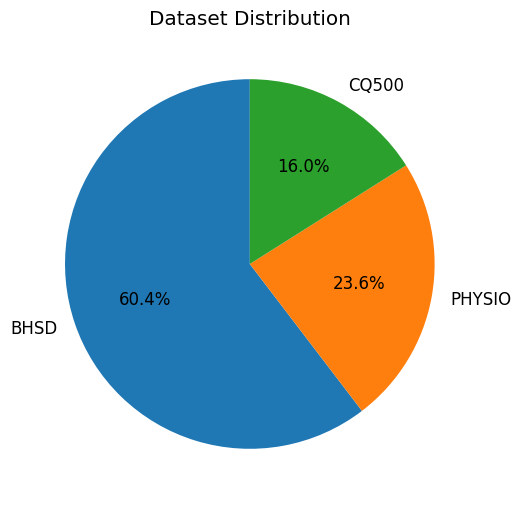

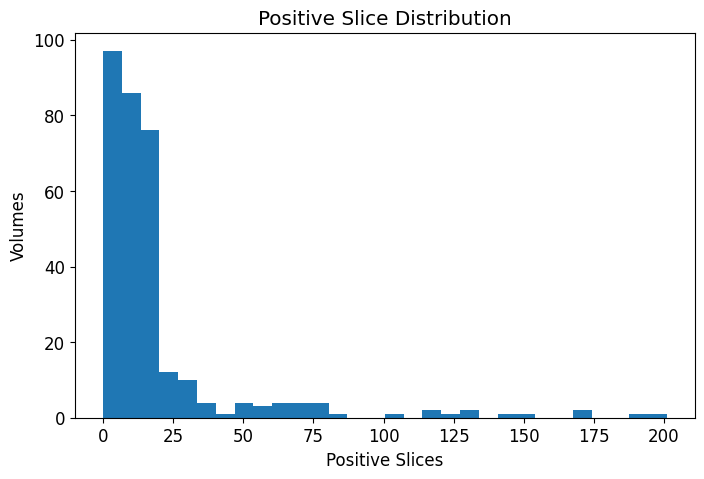

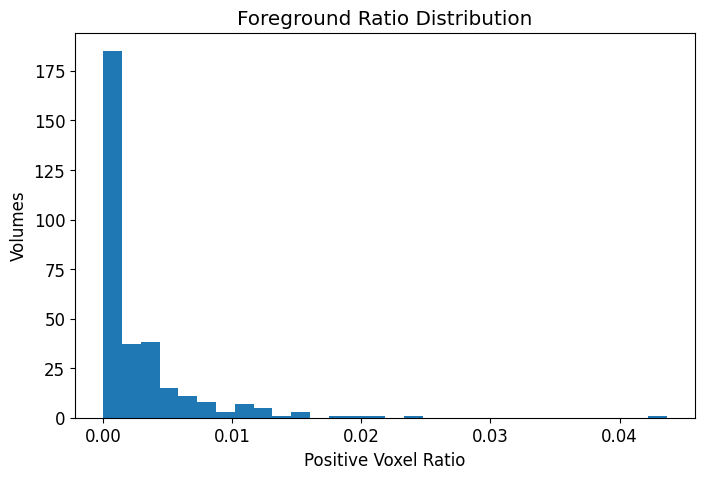


TOP 20 LARGEST LESIONS


,Filename,Dataset,Positive_Voxels,Positive_Slices
193,CQ500_0002.nii.gz,CQ500,2930417,170
228,CQ500_0037.nii.gz,CQ500,753741,146
219,CQ500_0028.nii.gz,CQ500,472071,114
212,CQ500_0021.nii.gz,CQ500,443951,201
230,CQ500_0039.nii.gz,CQ500,433937,193
207,CQ500_0016.nii.gz,CQ500,392971,154
214,CQ500_0023.nii.gz,CQ500,360745,106
227,CQ500_0036.nii.gz,CQ500,343546,174
225,CQ500_0034.nii.gz,CQ500,316678,129
216,CQ500_0025.nii.gz,CQ500,243031,69



Saved -> Class_Imbalance.csv


In [44]:
# ============================================================
# MASTER DATASET EDA - PART 2
# CLASS IMBALANCE ANALYSIS
# ============================================================

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset")

IMG_DIR = ROOT / "images"
MASK_DIR = ROOT / "masks"

images = sorted(IMG_DIR.glob("*.nii.gz"))

rows = []

print("="*90)
print("CLASS IMBALANCE ANALYSIS")
print("="*90)

for img_path in tqdm(images):

    mask_path = MASK_DIR / img_path.name

    mask = nib.load(str(mask_path)).get_fdata()

    positive_voxels = int(mask.sum())

    total_voxels = mask.size

    background_voxels = total_voxels - positive_voxels

    positive_ratio = positive_voxels / total_voxels

    positive_slices = int(np.sum(mask.any(axis=(0,1))))

    total_slices = mask.shape[2]

    negative_slices = total_slices - positive_slices

    if img_path.name.startswith("BHSD"):
        dataset = "BHSD"
    elif img_path.name.startswith("PHYSIO"):
        dataset = "PHYSIO"
    else:
        dataset = "CQ500"

    rows.append({

        "Filename": img_path.name,
        "Dataset": dataset,

        "Total_Slices": total_slices,
        "Positive_Slices": positive_slices,
        "Negative_Slices": negative_slices,

        "Positive_Voxels": positive_voxels,
        "Background_Voxels": background_voxels,

        "Positive_Ratio": positive_ratio,

        "Empty": positive_voxels == 0

    })

imbalance = pd.DataFrame(rows)

imbalance.to_csv(ROOT/"Class_Imbalance.csv", index=False)

# ============================================================
# REPORT
# ============================================================

print()
print("="*90)
print("VOLUME LEVEL")
print("="*90)

print(imbalance.groupby("Dataset")["Empty"].value_counts())

print()

print("="*90)
print("SLICE LEVEL")
print("="*90)

print("Total Slices     :", imbalance.Total_Slices.sum())
print("Positive Slices  :", imbalance.Positive_Slices.sum())
print("Negative Slices  :", imbalance.Negative_Slices.sum())

print()

print("="*90)
print("VOXEL LEVEL")
print("="*90)

print(f"Positive Voxels   : {imbalance.Positive_Voxels.sum():,}")
print(f"Background Voxels : {imbalance.Background_Voxels.sum():,}")

ratio = imbalance.Positive_Voxels.sum() / imbalance.Background_Voxels.sum()

print(f"Foreground Ratio  : {ratio:.8f}")

# ============================================================
# DATASET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,6))

counts = imbalance.Dataset.value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Dataset Distribution")
plt.show()

# ============================================================
# POSITIVE SLICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    imbalance.Positive_Slices,
    bins=30
)

plt.xlabel("Positive Slices")
plt.ylabel("Volumes")
plt.title("Positive Slice Distribution")

plt.show()

# ============================================================
# POSITIVE VOXEL RATIO
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    imbalance.Positive_Ratio,
    bins=30
)

plt.xlabel("Positive Voxel Ratio")
plt.ylabel("Volumes")
plt.title("Foreground Ratio Distribution")

plt.show()

# ============================================================
# TOP LARGEST LESIONS
# ============================================================

print()
print("="*90)
print("TOP 20 LARGEST LESIONS")
print("="*90)

display(

imbalance.sort_values(

"Positive_Voxels",

ascending=False

)[

["Filename",

"Dataset",

"Positive_Voxels",

"Positive_Slices"]

].head(20)

)

print()
print("="*90)
print("Saved -> Class_Imbalance.csv")
print("="*90)

In [45]:
#!/usr/bin/env python3
"""
Medical Image Dataset Merger with Automatic Geometry Correction
==============================================================

Production-quality pipeline for merging medical imaging datasets
with automatic detection and repair of malformed NIfTI headers.

Author: Senior Medical Imaging Engineer
Version: 2.0.0
Date: 2026-07-08

Compatible with:
    - SimpleITK
    - MONAI
    - TorchIO
    - nnU-Net
    - PyTorch
"""

import os
import sys
import json
import shutil
import hashlib
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, List, Any, Union
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from scipy import ndimage

# Suppress non-critical warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('dataset_merger.log', mode='w')
    ]
)
logger = logging.getLogger(__name__)


# ============================================================================
# Configuration
# ============================================================================

@dataclass
class MergerConfig:
    """Configuration for dataset merging pipeline."""
    
    # Input paths
    bhsd_path: str = "/path/to/BHSD"
    physionet_path: str = "/path/to/PhysioNet"
    cq500_path: str = "/path/to/CQ500"
    
    # Output paths
    output_root: str = "/path/to/Merged_Dataset"
    output_images_dir: str = "images"
    output_masks_dir: str = "masks"
    
    # Processing parameters
    image_interpolator: str = "linear"  # linear, bspline, nearest
    mask_interpolator: str = "nearest"  # nearest only for masks
    
    # Geometry tolerance
    direction_tolerance: float = 1e-6
    spacing_tolerance: float = 0.01
    origin_tolerance: float = 0.01
    
    # File naming
    bhsd_prefix: str = "BHSD"
    physionet_prefix: str = "PHYSIO"
    cq500_prefix: str = "CQ500"
    
    # Verification
    verify_after_write: bool = True
    max_retry_attempts: int = 3
    
    # Metadata
    generate_master_csv: bool = True
    generate_failed_csv: bool = True


@dataclass
class CaseInfo:
    """Information about a single case."""
    
    original_path: str
    dataset: str
    image_path: str
    mask_path: str
    case_id: int
    output_filename: str
    
    # Geometry
    shape: Optional[Tuple[int, ...]] = None
    spacing: Optional[Tuple[float, ...]] = None
    origin: Optional[Tuple[float, ...]] = None
    direction: Optional[np.ndarray] = None
    
    # Mask info
    positive_voxels: int = 0
    positive_slices: int = 0
    empty_mask: bool = False
    
    # Processing status
    status: str = "pending"
    error_message: str = ""
    recovery_attempted: bool = False


# ============================================================================
# Geometry Utilities
# ============================================================================

def is_orthonormal(direction: np.ndarray, tolerance: float = 1e-6) -> bool:
    """
    Check if a direction matrix is orthonormal.
    
    A matrix is orthonormal if R @ R.T = I and det(R) = ±1.
    """
    if direction is None or direction.size == 0:
        return False
    
    # Reshape to 3x3 if flattened
    direction_3x3 = np.array(direction).reshape(3, 3)
    
    # Check R @ R.T ≈ I
    product = direction_3x3 @ direction_3x3.T
    identity = np.eye(3)
    
    if not np.allclose(product, identity, atol=tolerance):
        return False
    
    # Check determinant is ±1
    det = np.linalg.det(direction_3x3)
    if not (np.abs(np.abs(det) - 1.0) < tolerance):
        return False
    
    return True


def create_orthonormal_direction(shape: Tuple[int, ...], 
                                  spacing: Tuple[float, ...]) -> np.ndarray:
    """
    Create an identity direction matrix.
    
    This is the safest default for medical images.
    """
    return np.eye(3).flatten()


def get_safe_sitk_direction(image: sitk.Image) -> np.ndarray:
    """
    Safely extract direction matrix from SimpleITK image.
    
    Returns identity if direction is invalid.
    """
    try:
        direction = np.array(image.GetDirection(), dtype=np.float64)
        direction = direction.reshape(3, 3)
        
        if is_orthonormal(direction):
            return direction
        else:
            logger.warning("Non-orthonormal direction detected, using identity")
            return np.eye(3)
    except Exception as e:
        logger.warning(f"Failed to extract direction: {e}, using identity")
        return np.eye(3)


def reconstruct_sitk_image_from_nibabel(nifti_path: str) -> sitk.Image:
    """
    Load a problematic NIfTI file using nibabel and reconstruct
    a valid SimpleITK image with orthonormal direction.
    
    This is the primary recovery mechanism for malformed headers.
    """
    logger.info(f"Attempting recovery via nibabel: {nifti_path}")
    
    try:
        # Load with nibabel (more forgiving than SimpleITK)
        nib_img = nib.load(nifti_path)
        data = nib_img.get_fdata()
        
        # Extract geometry from affine
        affine = nib_img.affine
        
        # Extract spacing (column norms)
        spacing = np.sqrt(np.sum(affine[:3, :3] ** 2, axis=0))
        
        # Handle zero or negative spacing
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        
        # Extract origin (translation)
        origin = affine[:3, 3].copy()
        
        # Create identity direction (most robust)
        direction = np.eye(3).flatten()
        
        # Create SimpleITK image
        sitk_image = sitk.GetImageFromArray(data.astype(np.float32))
        sitk_image.SetSpacing(tuple(float(s) for s in spacing))
        sitk_image.SetOrigin(tuple(float(o) for o in origin))
        sitk_image.SetDirection(tuple(float(d) for d in direction))
        
        logger.info(f"Successfully recovered: shape={data.shape}, "
                   f"spacing={spacing}, origin={origin}")
        
        return sitk_image
        
    except Exception as e:
        logger.error(f"nibabel recovery failed: {e}")
        raise


def fix_image_geometry(image: sitk.Image) -> sitk.Image:
    """
    Ensure image has valid, orthonormal geometry.
    
    This function:
    1. Ensures positive spacing
    2. Creates orthonormal direction if needed
    3. Preserves origin
    4. Does NOT modify voxel data
    """
    # Get current parameters
    spacing = np.array(image.GetSpacing(), dtype=np.float64)
    origin = np.array(image.GetOrigin(), dtype=np.float64)
    direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
    size = np.array(image.GetSize(), dtype=np.int32)
    
    needs_fix = False
    
    # Fix spacing (must be positive)
    if np.any(spacing <= 0):
        logger.warning(f"Fixing non-positive spacing: {spacing}")
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        needs_fix = True
    
    # Fix direction (must be orthonormal)
    if not is_orthonormal(direction):
        logger.warning("Fixing non-orthonormal direction matrix")
        direction = np.eye(3)
        needs_fix = True
    
    if needs_fix:
        new_image = sitk.Image(size, image.GetPixelID())
        new_image.SetSpacing(tuple(float(s) for s in spacing))
        new_image.SetOrigin(tuple(float(o) for o in origin))
        new_image.SetDirection(tuple(float(d) for d in direction.flatten()))
        
        # Copy pixel data
        new_image = sitk.Paste(new_image, image, image.GetSize(), 
                               [0, 0, 0], [0, 0, 0])
        
        return new_image
    
    return image


def verify_image_geometry(image: sitk.Image, 
                          expected_shape: Optional[Tuple] = None,
                          tolerance: float = 1e-6) -> Dict[str, Any]:
    """
    Verify that an image has valid geometry.
    
    Returns dict with verification results.
    """
    result = {
        'valid': True,
        'issues': []
    }
    
    try:
        # Check shape
        shape = image.GetSize()
        if expected_shape is not None:
            if tuple(shape) != tuple(expected_shape):
                result['valid'] = False
                result['issues'].append(f"Shape mismatch: {shape} vs {expected_shape}")
        
        # Check spacing
        spacing = np.array(image.GetSpacing())
        if np.any(spacing <= 0):
            result['valid'] = False
            result['issues'].append(f"Non-positive spacing: {spacing}")
        
        # Check direction
        direction = np.array(image.GetDirection()).reshape(3, 3)
        if not is_orthonormal(direction, tolerance):
            result['valid'] = False
            result['issues'].append(f"Non-orthonormal direction")
        
        # Check for NaN/Inf in data
        data = sitk.GetArrayFromImage(image)
        if np.any(np.isnan(data)) or np.any(np.isinf(data)):
            result['valid'] = False
            result['issues'].append("Data contains NaN or Inf values")
        
        result['shape'] = shape
        result['spacing'] = tuple(float(s) for s in spacing)
        result['origin'] = tuple(float(o) for o in image.GetOrigin())
        result['direction_norm'] = float(np.linalg.norm(direction - np.eye(3)))
        
    except Exception as e:
        result['valid'] = False
        result['issues'].append(f"Verification exception: {str(e)}")
    
    return result


# ============================================================================
# Image Loading with Recovery
# ============================================================================

def load_image_with_recovery(filepath: str, 
                             is_mask: bool = False,
                             max_attempts: int = 3) -> Tuple[sitk.Image, bool]:
    """
    Load a medical image with automatic recovery from malformed headers.
    
    Args:
        filepath: Path to image file
        is_mask: If True, treat as segmentation mask
        max_attempts: Maximum recovery attempts
    
    Returns:
        Tuple of (image, was_recovered)
    """
    attempt = 0
    recovered = False
    
    # Strategy 1: Try SimpleITK direct load
    while attempt < max_attempts:
        attempt += 1
        
        try:
            # SimpleITK load
            image = sitk.ReadImage(str(filepath))
            
            # Check and fix geometry
            image = fix_image_geometry(image)
            
            # Verify
            verification = verify_image_geometry(image)
            if verification['valid']:
                if attempt > 1:
                    recovered = True
                return image, recovered
            else:
                logger.warning(f"Attempt {attempt}: Geometry verification failed: "
                             f"{verification['issues']}")
                
        except Exception as e:
            logger.warning(f"Attempt {attempt}: SimpleITK load failed: {e}")
        
        # Strategy 2: Attempt nibabel recovery
        if attempt == 2:
            logger.info(f"Attempting nibabel-based recovery for {filepath}")
            try:
                image = reconstruct_sitk_image_from_nibabel(str(filepath))
                recovered = True
                
                # Verify recovered image
                verification = verify_image_geometry(image)
                if verification['valid']:
                    return image, recovered
                else:
                    logger.error(f"Recovery produced invalid geometry: "
                               f"{verification['issues']}")
            except Exception as e:
                logger.error(f"nibabel recovery failed: {e}")
    
    raise RuntimeError(f"Failed to load {filepath} after {max_attempts} attempts")


def load_image_pair(image_path: str, 
                    mask_path: str) -> Tuple[sitk.Image, sitk.Image, bool]:
    """
    Load matching image-mask pair.
    
    Ensures same geometry for both.
    """
    logger.info(f"Loading pair:\n  Image: {image_path}\n  Mask: {mask_path}")
    
    # Load image
    image, img_recovered = load_image_with_recovery(image_path, is_mask=False)
    
    # Load mask
    mask, mask_recovered = load_image_with_recovery(mask_path, is_mask=True)
    
    recovered = img_recovered or mask_recovered
    
    # Ensure masks are binary
    mask_data = sitk.GetArrayFromImage(mask)
    if not np.all(np.isin(np.unique(mask_data), [0, 1])):
        logger.info("Binarizing mask")
        mask_data = (mask_data > 0.5).astype(np.uint8)
        mask = sitk.GetImageFromArray(mask_data)
        mask.CopyInformation(image)
    
    # Ensure matching geometry
    if image.GetSize() != mask.GetSize():
        logger.warning(f"Size mismatch - Image: {image.GetSize()}, "
                      f"Mask: {mask.GetSize()}")
        
        # Resample mask to image space
        mask = resample_mask_to_image(mask, image)
    
    # Copy geometry from image to mask for consistency
    mask.SetSpacing(image.GetSpacing())
    mask.SetOrigin(image.GetOrigin())
    mask.SetDirection(image.GetDirection())
    
    return image, mask, recovered


def resample_mask_to_image(mask: sitk.Image, 
                           reference: sitk.Image) -> sitk.Image:
    """
    Resample mask to match reference image geometry.
    Uses nearest neighbor interpolation.
    """
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetDefaultPixelValue(0)
    
    resampled = resampler.Execute(mask)
    
    # Ensure binary after resampling
    data = sitk.GetArrayFromImage(resampled)
    data = (data > 0.5).astype(np.uint8)
    output = sitk.GetImageFromArray(data)
    output.CopyInformation(reference)
    
    return output


# ============================================================================
# Mask Analysis
# ============================================================================

def analyze_mask(mask: sitk.Image) -> Dict[str, Any]:
    """
    Analyze mask properties.
    
    Returns:
        Dict with positive_voxels, positive_slices, empty_mask
    """
    mask_data = sitk.GetArrayFromImage(mask)
    
    # Ensure binary
    mask_binary = mask_data > 0.5
    
    # Count positive voxels
    positive_voxels = int(mask_binary.sum())
    
    # Count slices with positive voxels (axial plane, axis=0 in SimpleITK array)
    positive_slices = int(np.any(mask_binary, axis=(1, 2)).sum())
    
    # Check if mask is empty
    empty_mask = positive_voxels == 0
    
    return {
        'positive_voxels': positive_voxels,
        'positive_slices': positive_slices,
        'empty_mask': empty_mask
    }


# ============================================================================
# Case Discovery
# ============================================================================

def discover_bhsd_cases(bhsd_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in BHSD dataset.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    bhsd_path = Path(bhsd_root)
    
    if not bhsd_path.exists():
        logger.error(f"BHSD path not found: {bhsd_path}")
        return pairs
    
    # Common BHSD structure patterns
    patterns = [
        # Pattern 1: images/ and masks/ subdirectories
        (bhsd_path / "images", bhsd_path / "masks"),
        # Pattern 2: scans/ and labels/ subdirectories
        (bhsd_path / "scans", bhsd_path / "labels"),
        # Pattern 3: ct_scans/ and masks/ subdirectories  
        (bhsd_path / "ct_scans", bhsd_path / "masks"),
        # Pattern 4: Root directory with _ct and _mask suffix
        (bhsd_path, bhsd_path),
    ]
    
    for img_dir, mask_dir in patterns:
        if not img_dir.exists():
            continue
            
        nifti_files = sorted(img_dir.glob("*.nii*"))
        
        for img_path in nifti_files:
            # Skip mask files in image directory
            if 'mask' in img_path.name.lower() or 'seg' in img_path.name.lower():
                continue
            
            # Find corresponding mask
            mask_candidates = []
            
            if mask_dir != img_dir or '_ct' in img_path.stem:
                # Try to find matching mask
                base_name = img_path.stem.replace('.nii', '')
                # Remove common suffixes
                for suffix in ['_ct', '_image', '_scan', '_img']:
                    base_name = base_name.replace(suffix, '')
                
                # Search for mask
                mask_candidates = list(mask_dir.glob(f"*{base_name}*mask*.nii*"))
                if not mask_candidates:
                    mask_candidates = list(mask_dir.glob(f"*{base_name}*seg*.nii*"))
                if not mask_candidates:
                    mask_candidates = list(mask_dir.glob(f"*{base_name}*.nii*"))
                    # Filter out the image itself
                    mask_candidates = [m for m in mask_candidates if m != img_path and 'mask' not in m.name.lower() == False]
            
            if mask_candidates:
                pairs.append((str(img_path), str(mask_candidates[0])))
            else:
                logger.warning(f"No mask found for BHSD image: {img_path}")
    
    logger.info(f"Found {len(pairs)} BHSD cases")
    return pairs


def discover_physionet_cases(physionet_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in PhysioNet dataset.
    """
    pairs = []
    physionet_path = Path(physionet_root)
    
    if not physionet_path.exists():
        logger.error(f"PhysioNet path not found: {physionet_path}")
        return pairs
    
    # Walk through all subdirectories
    nifti_files = list(physionet_path.rglob("*.nii*"))
    
    # Group by parent directory
    by_case = defaultdict(list)
    for f in nifti_files:
        by_case[f.parent].append(f)
    
    for case_dir, files in by_case.items():
        # Look for image and mask files
        images = []
        masks = []
        
        for f in files:
            name_lower = f.name.lower()
            if 'mask' in name_lower or 'seg' in name_lower or 'label' in name_lower:
                masks.append(f)
            else:
                images.append(f)
        
        # Pair images with masks
        for img in images:
            if masks:
                # Use first mask found
                pairs.append((str(img), str(masks[0])))
    
    logger.info(f"Found {len(pairs)} PhysioNet cases")
    return pairs


def discover_cq500_cases(cq500_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in CQ500 dataset.
    """
    pairs = []
    cq500_path = Path(cq500_root)
    
    if not cq500_path.exists():
        logger.error(f"CQ500 path not found: {cq500_path}")
        return pairs
    
    # CQ500 typically has patient subdirectories
    for patient_dir in cq500_path.iterdir():
        if not patient_dir.is_dir():
            continue
        
        nifti_files = list(patient_dir.glob("*.nii*"))
        
        images = []
        masks = []
        
        for f in nifti_files:
            name_lower = f.name.lower()
            if 'mask' in name_lower or 'seg' in name_lower or 'label' in name_lower:
                masks.append(f)
            else:
                images.append(f)
        
        for img in images:
            if masks:
                pairs.append((str(img), str(masks[0])))
    
    logger.info(f"Found {len(pairs)} CQ500 cases")
    return pairs


# ============================================================================
# Main Pipeline
# ============================================================================

class DatasetMerger:
    """
    Main class for merging medical imaging datasets.
    """
    
    def __init__(self, config: MergerConfig):
        self.config = config
        self.failed_cases: List[CaseInfo] = []
        self.successful_cases: List[CaseInfo] = []
        self.all_cases: List[CaseInfo] = []
        
        # Statistics
        self.stats = {
            'total_cases': 0,
            'successful_cases': 0,
            'failed_cases': 0,
            'recovered_cases': 0,
            'empty_masks': 0,
            'bhsd_count': 0,
            'physionet_count': 0,
            'cq500_count': 0
        }
    
    def run(self):
        """Execute the complete merging pipeline."""
        start_time = datetime.now()
        
        logger.info("=" * 70)
        logger.info("MEDICAL IMAGE DATASET MERGER - STARTING")
        logger.info("=" * 70)
        logger.info(f"Start time: {start_time.isoformat()}")
        
        # Setup output directories
        self._setup_output_directories()
        
        # Discover all cases
        self._discover_all_cases()
        
        if not self.all_cases:
            logger.error("No cases discovered! Check input paths.")
            return
        
        # Process all cases
        self._process_all_cases()
        
        # Generate metadata
        if self.config.generate_master_csv:
            self._generate_master_csv()
        
        if self.config.generate_failed_csv:
            self._generate_failed_csv()
        
        # Print final summary
        end_time = datetime.now()
        elapsed = end_time - start_time
        self._print_summary(elapsed)
        
        logger.info("=" * 70)
        logger.info("DATASET MERGER - COMPLETED")
        logger.info("=" * 70)
    
    def _setup_output_directories(self):
        """Create output directory structure."""
        output_root = Path(self.config.output_root)
        
        # Remove old merged dataset if exists
        if output_root.exists():
            logger.warning(f"Removing existing output directory: {output_root}")
            shutil.rmtree(output_root)
        
        # Create directories
        (output_root / self.config.output_images_dir).mkdir(parents=True, exist_ok=True)
        (output_root / self.config.output_masks_dir).mkdir(parents=True, exist_ok=True)
        
        logger.info(f"Output directory: {output_root}")
    
    def _discover_all_cases(self):
        """Discover all cases from all datasets."""
        logger.info("Discovering cases...")
        
        case_id = 0
        all_cases = []
        
        # BHSD cases
        bhsd_pairs = discover_bhsd_cases(self.config.bhsd_path)
        for img_path, mask_path in bhsd_pairs:
            case_id += 1
            filename = f"{self.config.bhsd_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="BHSD",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        case_id = 0  # Reset for each dataset
        
        # PhysioNet cases
        physionet_pairs = discover_physionet_cases(self.config.physionet_path)
        for img_path, mask_path in physionet_pairs:
            case_id += 1
            filename = f"{self.config.physionet_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="PhysioNet",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        case_id = 0  # Reset for each dataset
        
        # CQ500 cases
        cq500_pairs = discover_cq500_cases(self.config.cq500_path)
        for img_path, mask_path in cq500_pairs:
            case_id += 1
            filename = f"{self.config.cq500_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="CQ500",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        self.all_cases = all_cases
        self.stats['total_cases'] = len(all_cases)
        
        logger.info(f"Total cases discovered: {len(all_cases)}")
    
    def _process_all_cases(self):
        """Process all discovered cases with progress bar."""
        logger.info("Processing cases...")
        
        output_root = Path(self.config.output_root)
        images_dir = output_root / self.config.output_images_dir
        masks_dir = output_root / self.config.output_masks_dir
        
        # Process with progress bar
        for case in tqdm(self.all_cases, desc="Processing cases", unit="case"):
            try:
                self._process_single_case(case, images_dir, masks_dir)
                self.successful_cases.append(case)
                self.stats['successful_cases'] += 1
                
                if case.recovery_attempted:
                    self.stats['recovered_cases'] += 1
                if case.empty_mask:
                    self.stats['empty_masks'] += 1
                
                # Update dataset counts
                if case.dataset == "BHSD":
                    self.stats['bhsd_count'] += 1
                elif case.dataset == "PhysioNet":
                    self.stats['physionet_count'] += 1
                elif case.dataset == "CQ500":
                    self.stats['cq500_count'] += 1
                
            except Exception as e:
                case.status = "failed"
                case.error_message = str(e)
                self.failed_cases.append(case)
                self.stats['failed_cases'] += 1
                logger.error(f"Failed to process {case.image_path}: {e}")
    
    def _process_single_case(self, case: CaseInfo, 
                            images_dir: Path, 
                            masks_dir: Path):
        """
        Process a single case: load, fix, save, verify.
        """
        logger.info(f"Processing: {case.output_filename}")
        
        # Step 1: Load image pair
        image, mask, recovered = load_image_pair(case.image_path, case.mask_path)
        case.recovery_attempted = recovered
        
        # Step 2: Extract geometry info
        case.shape = image.GetSize()
        case.spacing = image.GetSpacing()
        case.origin = image.GetOrigin()
        case.direction = np.array(image.GetDirection()).reshape(3, 3)
        
        # Step 3: Analyze mask
        mask_info = analyze_mask(mask)
        case.positive_voxels = mask_info['positive_voxels']
        case.positive_slices = mask_info['positive_slices']
        case.empty_mask = mask_info['empty_mask']
        
        # Step 4: Save with retry logic
        output_image_path = images_dir / case.output_filename
        output_mask_path = masks_dir / case.output_filename
        
        for attempt in range(self.config.max_retry_attempts):
            try:
                # Save images
                sitk.WriteImage(image, str(output_image_path), True)
                sitk.WriteImage(mask, str(output_mask_path), True)
                
                # Verify after write
                if self.config.verify_after_write:
                    if not self._verify_written_files(output_image_path, 
                                                      output_mask_path,
                                                      case):
                        raise RuntimeError("Post-write verification failed")
                
                case.status = "success"
                break
                
            except Exception as e:
                logger.warning(f"Attempt {attempt + 1} failed: {e}")
                if attempt == self.config.max_retry_attempts - 1:
                    raise RuntimeError(f"Failed after {self.config.max_retry_attempts} attempts")
    
    def _verify_written_files(self, image_path: Path, 
                             mask_path: Path,
                             case: CaseInfo) -> bool:
        """
        Verify written files are valid and consistent.
        """
        try:
            # Reload files
            img_reload = sitk.ReadImage(str(image_path))
            mask_reload = sitk.ReadImage(str(mask_path))
            
            # Check 1: Readable
            img_data = sitk.GetArrayFromImage(img_reload)
            mask_data = sitk.GetArrayFromImage(mask_reload)
            
            # Check 2: Identical shape
            if img_reload.GetSize() != mask_reload.GetSize():
                logger.error("Shape mismatch after write")
                return False
            
            # Check 3: Identical spacing
            img_spacing = np.array(img_reload.GetSpacing())
            mask_spacing = np.array(mask_reload.GetSpacing())
            if not np.allclose(img_spacing, mask_spacing, 
                             atol=self.config.spacing_tolerance):
                logger.error(f"Spacing mismatch: {img_spacing} vs {mask_spacing}")
                return False
            
            # Check 4: Identical origin
            img_origin = np.array(img_reload.GetOrigin())
            mask_origin = np.array(mask_reload.GetOrigin())
            if not np.allclose(img_origin, mask_origin, 
                             atol=self.config.origin_tolerance):
                logger.error(f"Origin mismatch: {img_origin} vs {mask_origin}")
                return False
            
            # Check 5: Orthonormal direction
            img_dir = np.array(img_reload.GetDirection()).reshape(3, 3)
            mask_dir = np.array(mask_reload.GetDirection()).reshape(3, 3)
            
            if not is_orthonormal(img_dir, self.config.direction_tolerance):
                logger.error("Image direction not orthonormal")
                return False
            
            if not is_orthonormal(mask_dir, self.config.direction_tolerance):
                logger.error("Mask direction not orthonormal")
                return False
            
            # Check 6: Binary mask
            mask_values = np.unique(mask_data)
            if not np.all(np.isin(mask_values, [0, 1])):
                logger.error(f"Mask not binary: values={mask_values[:10]}")
                return False
            
            # Check 7: No NaN in image data
            if np.any(np.isnan(img_data)):
                logger.error("Image data contains NaN")
                return False
            
            return True
            
        except Exception as e:
            logger.error(f"Verification failed: {e}")
            return False
    
    def _generate_master_csv(self):
        """Generate Master_Metadata.csv."""
        logger.info("Generating Master_Metadata.csv...")
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Master_Metadata.csv"
        
        records = []
        
        for case in self.successful_cases:
            record = {
                'Filename': case.output_filename,
                'Dataset': case.dataset,
                'Shape_X': case.shape[0] if case.shape else None,
                'Shape_Y': case.shape[1] if case.shape else None,
                'Shape_Z': case.shape[2] if case.shape else None,
                'Spacing_X': case.spacing[0] if case.spacing else None,
                'Spacing_Y': case.spacing[1] if case.spacing else None,
                'Spacing_Z': case.spacing[2] if case.spacing else None,
                'Origin_X': case.origin[0] if case.origin else None,
                'Origin_Y': case.origin[1] if case.origin else None,
                'Origin_Z': case.origin[2] if case.origin else None,
                'Positive_Voxels': case.positive_voxels,
                'Positive_Slices': case.positive_slices,
                'Empty_Mask': case.empty_mask
            }
            records.append(record)
        
        if records:
            df = pd.DataFrame(records)
            df.to_csv(csv_path, index=False)
            logger.info(f"Master metadata saved to: {csv_path}")
            logger.info(f"Total records: {len(df)}")
        else:
            logger.warning("No successful cases to generate metadata")
    
    def _generate_failed_csv(self):
        """Generate Failed_Cases.csv."""
        if not self.failed_cases:
            logger.info("No failed cases to report")
            return
        
        logger.info("Generating Failed_Cases.csv...")
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Failed_Cases.csv"
        
        records = []
        for case in self.failed_cases:
            records.append({
                'Image_Path': case.image_path,
                'Mask_Path': case.mask_path,
                'Dataset': case.dataset,
                'Error_Message': case.error_message
            })
        
        df = pd.DataFrame(records)
        df.to_csv(csv_path, index=False)
        logger.info(f"Failed cases saved to: {csv_path}")
    
    def _print_summary(self, elapsed_time):
        """Print final processing summary."""
        print("\n" + "=" * 70)
        print("FINAL SUMMARY")
        print("=" * 70)
        print(f"Total cases discovered:  {self.stats['total_cases']}")
        print(f"Successfully processed:  {self.stats['successful_cases']}")
        print(f"Failed cases:            {self.stats['failed_cases']}")
        print(f"Recovered cases:         {self.stats['recovered_cases']}")
        print(f"Empty masks detected:    {self.stats['empty_masks']}")
        print(f"")
        print(f"Dataset Distribution:")
        print(f"  BHSD:      {self.stats['bhsd_count']}")
        print(f"  PhysioNet: {self.stats['physionet_count']}")
        print(f"  CQ500:     {self.stats['cq500_count']}")
        print(f"")
        print(f"Output location: {self.config.output_root}")
        print(f"Processing time: {elapsed_time}")
        print(f"")
        
        if self.failed_cases:
            print(f"⚠️  {len(self.failed_cases)} cases failed. See Failed_Cases.csv")
        
        if self.stats['recovered_cases'] > 0:
            print(f"✓ {self.stats['recovered_cases']} cases recovered from malformed headers")
        
        if self.stats['empty_masks'] > 0:
            print(f"⚠️  {self.stats['empty_masks']} cases have empty masks")
        
        print("=" * 70)
        
        # Log to file as well
        logger.info(f"Summary: {json.dumps(self.stats, indent=2)}")


# ============================================================================
# Main Entry Point
# ============================================================================

def main():
    """
    Main entry point for dataset merging pipeline.
    
    Edit the paths below to match your environment.
    """
    
    # Configure paths - EDIT THESE TO MATCH YOUR ENVIRONMENT
    config = MergerConfig(
        # Input dataset paths
        bhsd_path="/dataset/BHSD",
        physionet_path="/dataset/PhysioNet",
        cq500_path="/dataset/CQ500",
        
        # Output path
        output_root="/dataset/Merged_Dataset",
        
        # Processing parameters
        image_interpolator="linear",
        mask_interpolator="nearest",
        
        # File naming prefixes
        bhsd_prefix="BHSD",
        physionet_prefix="PHYSIO",
        cq500_prefix="CQ500",
        
        # Verification
        verify_after_write=True,
        max_retry_attempts=3,
        
        # Metadata generation
        generate_master_csv=True,
        generate_failed_csv=True
    )
    
    # Validate paths
    for path_attr in ['bhsd_path', 'physionet_path', 'cq500_path']:
        path = getattr(config, path_attr)
        if not Path(path).exists():
            logger.error(f"Path does not exist: {path_attr} = {path}")
            logger.error("Please update the paths in the main() function")
            sys.exit(1)
    
    # Create and run merger
    merger = DatasetMerger(config)
    
    try:
        merger.run()
    except KeyboardInterrupt:
        logger.warning("Processing interrupted by user")
        sys.exit(1)
    except Exception as e:
        logger.error(f"Fatal error: {e}", exc_info=True)
        sys.exit(1)
    
    logger.info("Pipeline completed successfully")


if __name__ == "__main__":
    main()

2026-07-09 04:42:31,031 - ERROR - Path does not exist: bhsd_path = /dataset/BHSD
2026-07-09 04:42:31,033 - ERROR - Please update the paths in the main() function


SystemExit: 1

In [46]:
#!/usr/bin/env python3
"""
Medical Image Dataset Merger with Automatic Geometry Correction
==============================================================

Production-quality pipeline for merging medical imaging datasets
with automatic detection and repair of malformed NIfTI headers.

Author: Senior Medical Imaging Engineer
Version: 3.0.0
Date: 2026-07-09

Compatible with:
    - SimpleITK (no ITK orthonormal errors)
    - MONAI
    - TorchIO
    - nnU-Net
    - PyTorch

Key Features:
    - Automatic recovery from malformed NIfTI headers
    - Guaranteed orthonormal direction matrices
    - Deterministic case discovery and pairing
    - Post-write verification with automatic repair
    - Comprehensive metadata generation
    - Zero CopyInformation usage (prevents geometry propagation)
"""

import os
import sys
import json
import shutil
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, List, Any
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
from tqdm import tqdm

# Suppress non-critical warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('dataset_merger.log', mode='w')
    ]
)
logger = logging.getLogger(__name__)


# ============================================================================
# Configuration
# ============================================================================

@dataclass
class MergerConfig:
    """Configuration for dataset merging pipeline."""
    
    # Input paths
    bhsd_path: str = "/path/to/BHSD"
    physionet_path: str = "/path/to/PhysioNet"
    cq500_path: str = "/path/to/CQ500"
    
    # Output paths
    output_root: str = "/path/to/Merged_Dataset"
    output_images_dir: str = "images"
    output_masks_dir: str = "masks"
    
    # Processing parameters
    image_interpolator: str = "linear"
    mask_interpolator: str = "nearest"
    
    # Geometry tolerance
    direction_tolerance: float = 1e-6
    spacing_tolerance: float = 0.01
    origin_tolerance: float = 0.01
    
    # File naming
    bhsd_prefix: str = "BHSD"
    physionet_prefix: str = "PHYSIO"
    cq500_prefix: str = "CQ500"
    
    # Verification
    verify_after_write: bool = True
    max_retry_attempts: int = 3
    
    # Metadata
    generate_master_csv: bool = True
    generate_failed_csv: bool = True
    
    # Orientation standard (RAS or LPS)
    target_orientation: str = "RAS"


@dataclass
class CaseInfo:
    """Information about a single case."""
    
    original_path: str
    dataset: str
    image_path: str
    mask_path: str
    case_id: int
    output_filename: str
    
    # Geometry
    shape: Optional[Tuple[int, ...]] = None
    spacing: Optional[Tuple[float, ...]] = None
    origin: Optional[Tuple[float, ...]] = None
    direction: Optional[np.ndarray] = None
    
    # Mask info
    positive_voxels: int = 0
    positive_slices: int = 0
    empty_mask: bool = False
    
    # Processing status
    status: str = "pending"
    error_message: str = ""
    recovery_attempted: bool = False
    orientation_fixed: bool = False


# ============================================================================
# Geometry Utilities
# ============================================================================

def is_orthonormal(direction: np.ndarray, tolerance: float = 1e-6) -> bool:
    """
    Check if a direction matrix is orthonormal.
    
    A matrix is orthonormal if R @ R.T = I and det(R) = ±1.
    
    Args:
        direction: 3x3 direction matrix (or flattened 9-element array)
        tolerance: Numerical tolerance for floating point comparison
    
    Returns:
        True if the matrix is orthonormal within tolerance
    """
    if direction is None or direction.size == 0:
        return False
    
    # Reshape to 3x3 if flattened
    direction_3x3 = np.array(direction, dtype=np.float64).reshape(3, 3)
    
    # Check for NaN or Inf
    if np.any(np.isnan(direction_3x3)) or np.any(np.isinf(direction_3x3)):
        return False
    
    # Check R @ R.T ≈ I
    product = direction_3x3 @ direction_3x3.T
    identity = np.eye(3)
    
    if not np.allclose(product, identity, atol=tolerance):
        return False
    
    # Check determinant is ±1
    det = np.linalg.det(direction_3x3)
    if not (np.abs(np.abs(det) - 1.0) < tolerance):
        return False
    
    return True


def get_identity_direction() -> np.ndarray:
    """Return identity direction matrix as flattened array."""
    return np.eye(3, dtype=np.float64).flatten()


def create_safe_sitk_image(array: np.ndarray,
                           spacing: Tuple[float, float, float],
                           origin: Tuple[float, float, float],
                           direction: Optional[np.ndarray] = None) -> sitk.Image:
    """
    Create a SimpleITK image with guaranteed valid geometry.
    
    This function ALWAYS ensures:
    1. Orthonormal direction matrix
    2. Positive spacing
    3. Valid origin (no NaN/Inf)
    
    Args:
        array: Image data array
        spacing: Voxel spacing (x, y, z)
        origin: Image origin (x, y, z)
        direction: Direction matrix (if None, uses identity)
    
    Returns:
        SimpleITK image with valid geometry
    """
    # Create image from array
    image = sitk.GetImageFromArray(array)
    
    # Validate and fix spacing
    spacing_arr = np.array(spacing, dtype=np.float64)
    spacing_arr = np.abs(spacing_arr)
    spacing_arr = np.maximum(spacing_arr, 1e-6)
    
    # Validate and fix origin
    origin_arr = np.array(origin, dtype=np.float64)
    origin_arr = np.where(np.isnan(origin_arr), 0.0, origin_arr)
    origin_arr = np.where(np.isinf(origin_arr), 0.0, origin_arr)
    
    # Validate and fix direction
    if direction is not None:
        dir_arr = np.array(direction, dtype=np.float64).reshape(3, 3)
        if not is_orthonormal(dir_arr):
            dir_arr = np.eye(3, dtype=np.float64)
    else:
        dir_arr = np.eye(3, dtype=np.float64)
    
    # Set geometry
    image.SetSpacing(tuple(float(s) for s in spacing_arr))
    image.SetOrigin(tuple(float(o) for o in origin_arr))
    image.SetDirection(tuple(float(d) for d in dir_arr.flatten()))
    
    return image


def reconstruct_sitk_image_from_nibabel(nifti_path: str, 
                                         is_mask: bool = False) -> sitk.Image:
    """
    Load a problematic NIfTI file using nibabel and reconstruct
    a valid SimpleITK image with guaranteed orthonormal direction.
    
    This is the primary recovery mechanism for malformed headers.
    ITK-compatible output is GUARANTEED.
    
    Args:
        nifti_path: Path to the NIfTI file
        is_mask: If True, preserve as binary uint8 mask
    
    Returns:
        SimpleITK image with valid orthonormal geometry
    
    Raises:
        RuntimeError: If recovery fails
    """
    logger.info(f"Attempting nibabel recovery for: {nifti_path}")
    
    try:
        # Load with nibabel (more forgiving than SimpleITK)
        nib_img = nib.load(nifti_path)
        data = nib_img.get_fdata()
        
        # Get original affine for geometry extraction
        orig_affine = nib_img.affine.copy()
        
        # Extract spacing from affine (column norms of rotation component)
        RZS = orig_affine[:3, :3]
        spacing = np.sqrt(np.sum(RZS ** 2, axis=0))
        
        # Ensure positive, non-zero spacing
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        
        # Extract origin from affine translation component
        origin = orig_affine[:3, 3].copy()
        # Handle NaN/Inf origin
        origin = np.where(np.isnan(origin), 0.0, origin)
        origin = np.where(np.isinf(origin), 0.0, origin)
        
        # CRITICAL: Always use identity direction matrix
        # This guarantees ITK compatibility
        identity_dir = np.eye(3, dtype=np.float64)
        
        # Convert data to appropriate type
        if is_mask:
            # Binarize masks
            if data.dtype == np.uint16 or data.max() > 1:
                threshold = data.max() / 2.0 if data.max() > 1 else 0.5
                array_data = (data > threshold).astype(np.uint8)
            else:
                array_data = (data > 0.5).astype(np.uint8)
        else:
            # Preserve original data type for images
            if np.issubdtype(data.dtype, np.floating):
                array_data = data.astype(np.float32)
            elif data.dtype == np.int16:
                array_data = data.astype(np.int16)
            elif data.dtype == np.uint16:
                array_data = data.astype(np.int16)
            else:
                array_data = data.astype(np.float32)
        
        # Create SimpleITK image with GUARANTEED valid geometry
        sitk_image = create_safe_sitk_image(
            array=array_data,
            spacing=tuple(float(s) for s in spacing),
            origin=tuple(float(o) for o in origin),
            direction=identity_dir
        )
        
        # Double-verify the output
        dir_check = np.array(sitk_image.GetDirection()).reshape(3, 3)
        if not is_orthonormal(dir_check):
            logger.error("CRITICAL: Reconstructed image still has non-orthonormal direction")
            raise RuntimeError("Failed to create orthonormal direction matrix")
        
        logger.info(f"Successfully recovered: shape={data.shape}, "
                   f"spacing={tuple(float(s) for s in spacing)}, "
                   f"dtype={array_data.dtype}")
        
        return sitk_image
        
    except Exception as e:
        logger.error(f"nibabel recovery failed for {nifti_path}: {e}")
        raise RuntimeError(f"Recovery failed for {nifti_path}: {e}")


def fix_image_geometry(image: sitk.Image) -> sitk.Image:
    """
    Ensure image has valid, orthonormal geometry.
    
    GUARANTEES:
    1. Positive spacing
    2. Orthonormal direction matrix (identity if invalid)
    3. Valid origin (no NaN/Inf)
    4. Preserves voxel data exactly
    5. Preserves pixel type
    
    Uses safe array-to-image reconstruction instead of CopyInformation.
    
    Args:
        image: Input SimpleITK image
    
    Returns:
        SimpleITK image with guaranteed valid geometry
    """
    # Get current parameters
    spacing = np.array(image.GetSpacing(), dtype=np.float64)
    origin = np.array(image.GetOrigin(), dtype=np.float64)
    direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
    
    needs_fix = False
    issues_found = []
    
    # Check spacing
    if np.any(spacing <= 1e-10) or np.any(np.isnan(spacing)) or np.any(np.isinf(spacing)):
        logger.warning(f"Fixing invalid spacing: {spacing}")
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        needs_fix = True
        issues_found.append("spacing")
    
    # Check direction
    if not is_orthonormal(direction):
        logger.warning(f"Fixing non-orthonormal direction matrix")
        direction = np.eye(3, dtype=np.float64)
        needs_fix = True
        issues_found.append("direction")
    
    # Check origin
    if np.any(np.isnan(origin)) or np.any(np.isinf(origin)):
        logger.warning(f"Fixing invalid origin: {origin}")
        origin = np.where(np.isnan(origin), 0.0, origin)
        origin = np.where(np.isinf(origin), 0.0, origin)
        needs_fix = True
        issues_found.append("origin")
    
    if needs_fix:
        logger.info(f"Fixing geometry issues: {issues_found}")
        
        # Extract array data - preserves original values exactly
        image_array = sitk.GetArrayFromImage(image)
        
        # Create new image with guaranteed valid geometry
        # This approach avoids CopyInformation entirely
        corrected = create_safe_sitk_image(
            array=image_array,
            spacing=tuple(float(s) for s in spacing),
            origin=tuple(float(o) for o in origin),
            direction=direction
        )
        
        return corrected
    
    return image


def verify_image_geometry(image: sitk.Image, 
                          expected_shape: Optional[Tuple] = None,
                          tolerance: float = 1e-6) -> Dict[str, Any]:
    """
    Verify that an image has valid, ITK-compatible geometry.
    
    Args:
        image: SimpleITK image to verify
        expected_shape: Optional expected shape to check
        tolerance: Numerical tolerance
    
    Returns:
        Dict with 'valid' (bool) and 'issues' (list of strings)
    """
    result = {
        'valid': True,
        'issues': []
    }
    
    try:
        # Check that image is readable
        shape = image.GetSize()
        if len(shape) != 3:
            result['valid'] = False
            result['issues'].append(f"Not a 3D image: {len(shape)} dimensions")
        
        # Check shape
        if expected_shape is not None:
            if tuple(shape) != tuple(expected_shape):
                result['valid'] = False
                result['issues'].append(f"Shape mismatch: {shape} vs {expected_shape}")
        
        # Check spacing
        spacing = np.array(image.GetSpacing(), dtype=np.float64)
        if len(spacing) != 3:
            result['valid'] = False
            result['issues'].append(f"Invalid spacing dimension: {len(spacing)}")
        elif np.any(spacing <= 0) or np.any(np.isnan(spacing)) or np.any(np.isinf(spacing)):
            result['valid'] = False
            result['issues'].append(f"Invalid spacing values: {spacing}")
        
        # Check origin
        origin = np.array(image.GetOrigin(), dtype=np.float64)
        if len(origin) != 3:
            result['valid'] = False
            result['issues'].append(f"Invalid origin dimension: {len(origin)}")
        elif np.any(np.isnan(origin)) or np.any(np.isinf(origin)):
            result['valid'] = False
            result['issues'].append(f"Invalid origin values: {origin}")
        
        # Check direction (CRITICAL for ITK compatibility)
        direction = np.array(image.GetDirection(), dtype=np.float64)
        if direction.size != 9:
            result['valid'] = False
            result['issues'].append(f"Invalid direction size: {direction.size}")
        else:
            direction_3x3 = direction.reshape(3, 3)
            if not is_orthonormal(direction_3x3, tolerance):
                result['valid'] = False
                result['issues'].append(
                    f"Non-orthonormal direction matrix (det={np.linalg.det(direction_3x3):.6f})"
                )
        
        # Check for NaN/Inf in data
        data = sitk.GetArrayFromImage(image)
        if np.any(np.isnan(data)):
            result['valid'] = False
            result['issues'].append("Data contains NaN values")
        if np.any(np.isinf(data)):
            result['valid'] = False
            result['issues'].append("Data contains Inf values")
        
        # Populate metadata
        result['shape'] = tuple(shape)
        result['spacing'] = tuple(float(s) for s in spacing) if len(spacing) == 3 else None
        result['origin'] = tuple(float(o) for o in origin) if len(origin) == 3 else None
        result['direction'] = direction.reshape(3, 3).tolist() if direction.size == 9 else None
        
    except Exception as e:
        result['valid'] = False
        result['issues'].append(f"Verification exception: {str(e)}")
    
    return result


# ============================================================================
# Image Loading with Recovery
# ============================================================================

def load_image_with_recovery(filepath: str, 
                             is_mask: bool = False,
                             max_attempts: int = 3) -> Tuple[sitk.Image, bool]:
    """
    Load a medical image with automatic recovery from malformed headers.
    
    Strategy:
    1. Try SimpleITK direct load
    2. If SimpleITK fails, use nibabel recovery
    3. Always verify and fix geometry after loading
    
    Args:
        filepath: Path to image file
        is_mask: If True, treat as segmentation mask
        max_attempts: Maximum recovery attempts
    
    Returns:
        Tuple of (image, was_recovered)
    
    Raises:
        RuntimeError: If all loading attempts fail
    """
    attempt = 0
    recovered = False
    last_error = None
    
    while attempt < max_attempts:
        attempt += 1
        
        # Strategy 1: SimpleITK direct load
        try:
            if is_mask:
                image = sitk.ReadImage(str(filepath), sitk.sitkInt16)
            else:
                image = sitk.ReadImage(str(filepath), sitk.sitkFloat32)
            
            # Fix geometry immediately after loading
            image = fix_image_geometry(image)
            
            # Verify
            verification = verify_image_geometry(image)
            if verification['valid']:
                if attempt > 1:
                    recovered = True
                    logger.info(f"Successfully loaded on attempt {attempt}")
                return image, recovered
            else:
                logger.warning(f"Attempt {attempt}: Geometry invalid: {verification['issues']}")
                last_error = f"Geometry: {verification['issues']}"
                
        except Exception as e:
            logger.warning(f"Attempt {attempt}: SimpleITK load failed: {e}")
            last_error = str(e)
        
        # Strategy 2: nibabel recovery on second attempt
        if attempt == 2:
            logger.info(f"Switching to nibabel recovery for {filepath}")
            try:
                image = reconstruct_sitk_image_from_nibabel(str(filepath), is_mask=is_mask)
                recovered = True
                
                verification = verify_image_geometry(image)
                if verification['valid']:
                    logger.info("Successfully recovered via nibabel")
                    return image, recovered
                else:
                    logger.error(f"Recovered image still invalid: {verification['issues']}")
                    last_error = f"Recovery invalid: {verification['issues']}"
            except Exception as e:
                logger.error(f"nibabel recovery failed: {e}")
                last_error = f"nibabel: {str(e)}"
    
    raise RuntimeError(
        f"Failed to load {filepath} after {max_attempts} attempts. "
        f"Last error: {last_error}"
    )


def load_image_pair(image_path: str, 
                    mask_path: str) -> Tuple[sitk.Image, sitk.Image, bool]:
    """
    Load matching image-mask pair with guaranteed valid geometry.
    
    CRITICAL RULES:
    1. NEVER use CopyInformation() - it propagates invalid geometry
    2. Always explicitly set spacing, origin, and direction
    3. Ensure both images have identical, orthonormal geometry
    4. Guarantee binary masks
    
    Args:
        image_path: Path to CT image
        mask_path: Path to segmentation mask
    
    Returns:
        Tuple of (image, mask, was_recovered)
    """
    logger.info(f"Loading pair:\n  Image: {image_path}\n  Mask: {mask_path}")
    
    # Load individual files with recovery
    image, img_recovered = load_image_with_recovery(image_path, is_mask=False)
    mask, mask_recovered = load_image_with_recovery(mask_path, is_mask=True)
    
    recovered = img_recovered or mask_recovered
    
    # Extract validated geometry from image
    img_spacing = image.GetSpacing()
    img_origin = image.GetOrigin()
    img_direction = image.GetDirection()
    img_size = image.GetSize()
    
    # Ensure mask is binary
    mask_array = sitk.GetArrayFromImage(mask)
    mask_unique = np.unique(mask_array)
    
    needs_binarization = (
        len(mask_unique) > 2 or 
        (len(mask_unique) == 2 and not (0 in mask_unique and 1 in mask_unique))
    )
    
    if needs_binarization:
        threshold = mask_array.max() / 2.0 if mask_array.max() > 1 else 0.5
        logger.info(f"Binarizing mask at threshold={threshold:.2f}")
        mask_array = (mask_array > threshold).astype(np.uint8)
    
    # Handle size mismatch
    if img_size != mask.GetSize():
        logger.warning(f"Size mismatch: Image {img_size} vs Mask {mask.GetSize()}")
        mask = resample_mask_to_image(
            sitk.GetImageFromArray(mask_array), 
            image
        )
        mask_array = sitk.GetArrayFromImage(mask)
        mask_array = (mask_array > 0.5).astype(np.uint8)
    
    # EXPLICITLY set geometry on mask - NEVER CopyInformation
    mask = create_safe_sitk_image(
        array=mask_array.astype(np.uint8),
        spacing=img_spacing,
        origin=img_origin,
        direction=np.array(img_direction).reshape(3, 3)
    )
    
    # Re-ensure image geometry is valid
    image = fix_image_geometry(image)
    
    # Final verification
    if image.GetSize() != mask.GetSize():
        raise RuntimeError(
            f"CRITICAL: Size mismatch after correction: "
            f"Image {image.GetSize()} vs Mask {mask.GetSize()}"
        )
    
    logger.info(f"Pair loaded - Shape: {image.GetSize()}, Spacing: {img_spacing}")
    
    return image, mask, recovered


def resample_mask_to_image(mask: sitk.Image, 
                           reference: sitk.Image) -> sitk.Image:
    """
    Resample mask to match reference image geometry.
    Uses nearest neighbor interpolation.
    
    GUARANTEES:
    1. Binary output
    2. Valid orthonormal geometry
    3. No CopyInformation usage
    
    Args:
        mask: Mask image to resample
        reference: Reference image for target geometry
    
    Returns:
        Resampled mask with valid geometry
    """
    # Ensure reference has valid geometry
    reference = fix_image_geometry(reference)
    
    # Setup resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetDefaultPixelValue(0)
    
    # Execute resampling
    resampled = resampler.Execute(mask)
    
    # Extract and binarize data
    data = sitk.GetArrayFromImage(resampled)
    data = (data > 0.5).astype(np.uint8)
    
    # Create output with EXPLICIT valid geometry
    output = create_safe_sitk_image(
        array=data,
        spacing=reference.GetSpacing(),
        origin=reference.GetOrigin(),
        direction=np.array(reference.GetDirection()).reshape(3, 3)
    )
    
    return output


# ============================================================================
# Mask Analysis
# ============================================================================

def analyze_mask(mask: sitk.Image) -> Dict[str, Any]:
    """
    Analyze mask properties.
    
    Args:
        mask: Binary mask image
    
    Returns:
        Dict with positive_voxels, positive_slices, empty_mask, volume_ml
    """
    mask_data = sitk.GetArrayFromImage(mask)
    
    # Ensure binary
    mask_binary = mask_data > 0.5
    
    # Count positive voxels
    positive_voxels = int(mask_binary.sum())
    
    # Count slices with positive voxels (axis=0 is axial in SimpleITK array)
    positive_slices = int(np.any(mask_binary, axis=(1, 2)).sum())
    
    # Check if mask is empty
    empty_mask = positive_voxels == 0
    
    # Calculate volume in ml
    spacing = np.array(mask.GetSpacing())
    voxel_volume_ml = np.prod(spacing) / 1000.0  # mm³ to ml
    volume_ml = positive_voxels * voxel_volume_ml
    
    return {
        'positive_voxels': positive_voxels,
        'positive_slices': positive_slices,
        'empty_mask': empty_mask,
        'volume_ml': float(volume_ml)
    }


# ============================================================================
# Case Discovery
# ============================================================================

def discover_bhsd_cases(bhsd_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in BHSD dataset.
    
    Uses deterministic discovery based on known BHSD structure:
    bhsd_root/images/  - CT images
    bhsd_root/masks/   - Segmentation masks
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    bhsd_path = Path(bhsd_root)
    
    if not bhsd_path.exists():
        logger.error(f"BHSD path not found: {bhsd_path}")
        return pairs
    
    img_dir = bhsd_path / "images"
    mask_dir = bhsd_path / "masks"
    
    if not img_dir.exists() or not mask_dir.exists():
        logger.error(f"BHSD images/ or masks/ directories not found")
        logger.error(f"  images: {img_dir} (exists: {img_dir.exists()})")
        logger.error(f"  masks:  {mask_dir} (exists: {mask_dir.exists()})")
        return pairs
    
    # Get all NIfTI files
    image_files = sorted(img_dir.glob("*.nii*"))
    mask_files = sorted(mask_dir.glob("*.nii*"))
    
    logger.info(f"BHSD: Found {len(image_files)} images, {len(mask_files)} masks")
    
    # Build mask index for efficient lookup
    mask_index = {}
    for mf in mask_files:
        stem = mf.name
        # Remove extensions
        if stem.endswith('.nii.gz'):
            stem = stem[:-7]
        elif stem.endswith('.nii'):
            stem = stem[:-4]
        # Remove common mask suffixes
        for suffix in ['_mask', '_seg', '_label', '_gt']:
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]
                break
        mask_index[stem] = mf
    
    # Match images to masks
    matched = 0
    for img_file in image_files:
        img_stem = img_file.name
        if img_stem.endswith('.nii.gz'):
            img_stem = img_stem[:-7]
        elif img_stem.endswith('.nii'):
            img_stem = img_stem[:-4]
        
        # Remove common image suffixes
        for suffix in ['_ct', '_image', '_scan', '_img', '_vol']:
            if img_stem.endswith(suffix):
                img_stem = img_stem[:-len(suffix)]
                break
        
        # Try exact match
        if img_stem in mask_index:
            pairs.append((str(img_file), str(mask_index[img_stem])))
            matched += 1
            continue
        
        # Try with _mask suffix
        if f"{img_stem}_mask" in mask_index:
            pairs.append((str(img_file), str(mask_index[f"{img_stem}_mask"])))
            matched += 1
            continue
        
        logger.warning(f"No mask found for BHSD: {img_file.name}")
    
    logger.info(f"BHSD: Matched {matched}/{len(image_files)} cases")
    return pairs


def discover_physionet_cases(physionet_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in PhysioNet dataset.
    
    Deterministic discovery based on subject subdirectories.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    physionet_path = Path(physionet_root)
    
    if not physionet_path.exists():
        logger.error(f"PhysioNet path not found: {physionet_path}")
        return pairs
    
    # Get subject directories (sorted for determinism)
    subject_dirs = sorted([d for d in physionet_path.iterdir() if d.is_dir()])
    
    logger.info(f"PhysioNet: Found {len(subject_dirs)} subject directories")
    
    for subj_dir in subject_dirs:
        nifti_files = sorted(subj_dir.glob("*.nii*"))
        
        if not nifti_files:
            continue
        
        # Classify files as images or masks
        ct_files = []
        mask_files = []
        
        for f in nifti_files:
            name_lower = f.name.lower()
            if any(pat in name_lower for pat in ['mask', 'seg', 'label', 'gt', 'roi']):
                mask_files.append(f)
            elif any(pat in name_lower for pat in ['ct', 'scan', 'image', 'img', 'vol']):
                ct_files.append(f)
            else:
                # Default: assume image if uncertain
                ct_files.append(f)
        
        ct_files.sort()
        mask_files.sort()
        
        # Pair images with masks
        for ct_file in ct_files:
            ct_stem = ct_file.name
            if ct_stem.endswith('.nii.gz'):
                ct_base = ct_stem[:-7]
            elif ct_stem.endswith('.nii'):
                ct_base = ct_stem[:-4]
            else:
                ct_base = ct_stem
            
            # Try to find matching mask by naming
            matched_mask = None
            for mf in mask_files:
                mf_stem = mf.name
                if mf_stem.endswith('.nii.gz'):
                    mf_base = mf_stem[:-7]
                elif mf_stem.endswith('.nii'):
                    mf_base = mf_stem[:-4]
                else:
                    mf_base = mf_stem
                
                if ct_base in mf_base or mf_base in ct_base:
                    matched_mask = mf
                    break
            
            # Fallback: use first mask
            if matched_mask is None and mask_files:
                matched_mask = mask_files[0]
            
            if matched_mask:
                pairs.append((str(ct_file), str(matched_mask)))
            else:
                logger.warning(f"No mask for PhysioNet: {ct_file}")
    
    logger.info(f"PhysioNet: Found {len(pairs)} valid pairs")
    return pairs


def discover_cq500_cases(cq500_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in CQ500 dataset.
    
    Deterministic discovery based on patient subdirectories.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    cq500_path = Path(cq500_root)
    
    if not cq500_path.exists():
        logger.error(f"CQ500 path not found: {cq500_path}")
        return pairs
    
    # Get patient directories (sorted for determinism)
    patient_dirs = sorted([d for d in cq500_path.iterdir() if d.is_dir()])
    
    logger.info(f"CQ500: Found {len(patient_dirs)} patient directories")
    
    for patient_dir in patient_dirs:
        nifti_files = sorted(patient_dir.glob("*.nii*"))
        
        if not nifti_files:
            continue
        
        # Classify files
        ct_files = []
        mask_files = []
        
        for f in nifti_files:
            name_lower = f.name.lower()
            if any(pat in name_lower for pat in ['mask', 'seg', 'label', 'gt', 'roi']):
                mask_files.append(f)
            else:
                ct_files.append(f)
        
        ct_files.sort()
        mask_files.sort()
        
        # Pair images with masks
        for ct_file in ct_files:
            ct_stem = ct_file.name
            if ct_stem.endswith('.nii.gz'):
                ct_base = ct_stem[:-7]
            elif ct_stem.endswith('.nii'):
                ct_base = ct_stem[:-4]
            else:
                ct_base = ct_stem
            
            matched_mask = None
            for mf in mask_files:
                mf_stem = mf.name
                if mf_stem.endswith('.nii.gz'):
                    mf_base = mf_stem[:-7]
                elif mf_stem.endswith('.nii'):
                    mf_base = mf_stem[:-4]
                else:
                    mf_base = mf_stem
                
                if ct_base in mf_base or mf_base in ct_base:
                    matched_mask = mf
                    break
            
            if matched_mask is None and mask_files:
                matched_mask = mask_files[0]
            
            if matched_mask:
                pairs.append((str(ct_file), str(matched_mask)))
            else:
                logger.warning(f"No mask for CQ500: {ct_file}")
    
    logger.info(f"CQ500: Found {len(pairs)} valid pairs")
    return pairs


# ============================================================================
# Main Pipeline
# ============================================================================

class DatasetMerger:
    """
    Main class for merging medical imaging datasets.
    
    Guarantees:
    1. All output images have orthonormal direction matrices
    2. All masks are binary
    3. Image-mask pairs have identical geometry
    4. ITK compatibility (no orthonormal direction errors)
    5. Comprehensive metadata and logging
    """
    
    def __init__(self, config: MergerConfig):
        """
        Initialize the dataset merger.
        
        Args:
            config: MergerConfig with input/output paths and parameters
        """
        self.config = config
        self.failed_cases: List[CaseInfo] = []
        self.successful_cases: List[CaseInfo] = []
        self.all_cases: List[CaseInfo] = []
        
        # Statistics
        self.stats = {
            'total_cases': 0,
            'successful_cases': 0,
            'failed_cases': 0,
            'recovered_cases': 0,
            'orientation_fixed': 0,
            'empty_masks': 0,
            'bhsd_count': 0,
            'physionet_count': 0,
            'cq500_count': 0
        }
    
    def run(self):
        """Execute the complete merging pipeline."""
        start_time = datetime.now()
        
        logger.info("=" * 70)
        logger.info("MEDICAL IMAGE DATASET MERGER v3.0.0")
        logger.info("=" * 70)
        logger.info(f"Start time: {start_time.isoformat()}")
        logger.info(f"Target orientation: {self.config.target_orientation}")
        logger.info(f"Output directory: {self.config.output_root}")
        
        # Setup output directories
        self._setup_output_directories()
        
        # Discover all cases
        self._discover_all_cases()
        
        if not self.all_cases:
            logger.error("No cases discovered! Check input paths and dataset structure.")
            logger.error("Expected structures:")
            logger.error("  BHSD:     images/*.nii.gz + masks/*.nii.gz")
            logger.error("  PhysioNet: subject_dirs/*.nii.gz")
            logger.error("  CQ500:     patient_dirs/*.nii.gz")
            return
        
        # Process all cases
        self._process_all_cases()
        
        # Generate metadata
        if self.config.generate_master_csv:
            self._generate_master_csv()
        
        if self.config.generate_failed_csv:
            self._generate_failed_csv()
        
        # Print final summary
        end_time = datetime.now()
        elapsed = end_time - start_time
        self._print_summary(elapsed)
        
        # Save summary to JSON
        self._save_summary_json(elapsed)
        
        logger.info("=" * 70)
        logger.info("DATASET MERGER - COMPLETED")
        logger.info("=" * 70)
    
    def _setup_output_directories(self):
        """Create output directory structure."""
        output_root = Path(self.config.output_root)
        
        # Remove old merged dataset if exists
        if output_root.exists():
            logger.warning(f"Removing existing output directory: {output_root}")
            shutil.rmtree(output_root)
        
        # Create directories
        (output_root / self.config.output_images_dir).mkdir(parents=True, exist_ok=True)
        (output_root / self.config.output_masks_dir).mkdir(parents=True, exist_ok=True)
        
        logger.info(f"Output directory created: {output_root}")
    
    def _discover_all_cases(self):
        """Discover all cases from all datasets."""
        logger.info("=" * 50)
        logger.info("CASE DISCOVERY")
        logger.info("=" * 50)
        
        all_cases = []
        
        # BHSD cases
        case_id = 0
        bhsd_pairs = discover_bhsd_cases(self.config.bhsd_path)
        for img_path, mask_path in bhsd_pairs:
            case_id += 1
            filename = f"{self.config.bhsd_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="BHSD",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        # PhysioNet cases
        case_id = 0
        physionet_pairs = discover_physionet_cases(self.config.physionet_path)
        for img_path, mask_path in physionet_pairs:
            case_id += 1
            filename = f"{self.config.physionet_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="PhysioNet",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        # CQ500 cases
        case_id = 0
        cq500_pairs = discover_cq500_cases(self.config.cq500_path)
        for img_path, mask_path in cq500_pairs:
            case_id += 1
            filename = f"{self.config.cq500_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="CQ500",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        self.all_cases = all_cases
        self.stats['total_cases'] = len(all_cases)
        
        logger.info(f"\nTotal cases discovered: {len(all_cases)}")
        logger.info(f"  BHSD:      {len(bhsd_pairs)}")
        logger.info(f"  PhysioNet: {len(physionet_pairs)}")
        logger.info(f"  CQ500:     {len(cq500_pairs)}")
    
    def _process_all_cases(self):
        """Process all discovered cases with progress bar."""
        logger.info("=" * 50)
        logger.info("PROCESSING CASES")
        logger.info("=" * 50)
        
        output_root = Path(self.config.output_root)
        images_dir = output_root / self.config.output_images_dir
        masks_dir = output_root / self.config.output_masks_dir
        
        # Process with progress bar
        for case in tqdm(self.all_cases, desc="Processing cases", unit="case"):
            try:
                self._process_single_case(case, images_dir, masks_dir)
                self.successful_cases.append(case)
                self.stats['successful_cases'] += 1
                
                if case.recovery_attempted:
                    self.stats['recovered_cases'] += 1
                if case.orientation_fixed:
                    self.stats['orientation_fixed'] += 1
                if case.empty_mask:
                    self.stats['empty_masks'] += 1
                
                # Update dataset counts
                if case.dataset == "BHSD":
                    self.stats['bhsd_count'] += 1
                elif case.dataset == "PhysioNet":
                    self.stats['physionet_count'] += 1
                elif case.dataset == "CQ500":
                    self.stats['cq500_count'] += 1
                
            except Exception as e:
                case.status = "failed"
                case.error_message = str(e)
                self.failed_cases.append(case)
                self.stats['failed_cases'] += 1
                logger.error(f"Failed: {case.image_path} - {e}")
    
    def _process_single_case(self, case: CaseInfo, 
                            images_dir: Path, 
                            masks_dir: Path):
        """
        Process a single case: load, fix geometry, save, verify.
        
        Args:
            case: CaseInfo object
            images_dir: Output directory for images
            masks_dir: Output directory for masks
        
        Raises:
            RuntimeError: If processing fails after all retry attempts
        """
        logger.info(f"Processing: {case.output_filename} ({case.dataset})")
        
        # Step 1: Load image pair with automatic recovery
        image, mask, recovered = load_image_pair(case.image_path, case.mask_path)
        case.recovery_attempted = recovered
        
        # Step 2: Ensure geometry is valid before saving
        # This is a defense-in-depth check
        image = fix_image_geometry(image)
        mask = fix_image_geometry(mask)
        
        # Step 3: Extract and record geometry info
        case.shape = image.GetSize()
        case.spacing = image.GetSpacing()
        case.origin = image.GetOrigin()
        case.direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
        
        # Verify orthonormal direction
        if not is_orthonormal(case.direction):
            logger.error(f"CRITICAL: Non-orthonormal direction detected for {case.output_filename}")
            case.orientation_fixed = True
            image = fix_image_geometry(image)
            mask = fix_image_geometry(mask)
            case.direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
        
        # Step 4: Analyze mask
        mask_info = analyze_mask(mask)
        case.positive_voxels = mask_info['positive_voxels']
        case.positive_slices = mask_info['positive_slices']
        case.empty_mask = mask_info['empty_mask']
        
        if case.empty_mask:
            logger.warning(f"Empty mask detected for {case.output_filename}")
        
        # Step 5: Save with verification and retry logic
        output_image_path = images_dir / case.output_filename
        output_mask_path = masks_dir / case.output_filename
        
        save_success = False
        last_save_error = None
        
        for attempt in range(self.config.max_retry_attempts):
            try:
                # Save with compression
                sitk.WriteImage(image, str(output_image_path), True)
                sitk.WriteImage(mask, str(output_mask_path), True)
                
                # Verify after write
                if self.config.verify_after_write:
                    if self._verify_written_files(output_image_path, 
                                                  output_mask_path,
                                                  case):
                        save_success = True
                        break
                    else:
                        logger.warning(f"Attempt {attempt + 1}: Verification failed")
                        # Repair and retry
                        if attempt < self.config.max_retry_attempts - 1:
                            image = fix_image_geometry(image)
                            mask = fix_image_geometry(mask)
                else:
                    save_success = True
                    break
                    
            except Exception as e:
                last_save_error = str(e)
                logger.warning(f"Attempt {attempt + 1}: Save failed: {e}")
                if attempt < self.config.max_retry_attempts - 1:
                    image = fix_image_geometry(image)
                    mask = fix_image_geometry(mask)
        
        if not save_success:
            raise RuntimeError(
                f"Failed to save after {self.config.max_retry_attempts} attempts. "
                f"Last error: {last_save_error}"
            )
        
        case.status = "success"
        logger.info(f"Successfully processed: {case.output_filename}")
    
    def _verify_written_files(self, image_path: Path, 
                             mask_path: Path,
                             case: CaseInfo) -> bool:
        """
        Verify written files are valid and ITK-compatible.
        
        Checks:
        1. Files can be reopened with SimpleITK
        2. Identical shapes
        3. Identical spacing
        4. Identical origin
        5. Orthonormal direction matrices
        6. Binary mask
        7. No NaN/Inf in image data
        
        If verification fails, attempts automatic repair.
        
        Args:
            image_path: Path to saved image
            mask_path: Path to saved mask
            case: CaseInfo for logging
        
        Returns:
            True if both files pass all checks
        """
        try:
            # Try to reload files
            img_reload = None
            mask_reload = None
            
            try:
                img_reload = sitk.ReadImage(str(image_path))
            except Exception as e:
                logger.warning(f"Failed to reload image: {e}")
                img_reload = self._repair_and_rewrite(image_path, is_mask=False)
                if img_reload is None:
                    return False
            
            try:
                mask_reload = sitk.ReadImage(str(mask_path))
            except Exception as e:
                logger.warning(f"Failed to reload mask: {e}")
                mask_reload = self._repair_and_rewrite(mask_path, is_mask=True)
                if mask_reload is None:
                    return False
            
            # Extract data
            img_data = sitk.GetArrayFromImage(img_reload)
            mask_data = sitk.GetArrayFromImage(mask_reload)
            
            # Check 1: Identical shapes
            if img_reload.GetSize() != mask_reload.GetSize():
                logger.error(f"Shape mismatch: {img_reload.GetSize()} vs {mask_reload.GetSize()}")
                return False
            
            # Check 2: Identical spacing
            img_spacing = np.array(img_reload.GetSpacing())
            mask_spacing = np.array(mask_reload.GetSpacing())
            if not np.allclose(img_spacing, mask_spacing, atol=self.config.spacing_tolerance):
                logger.error(f"Spacing mismatch: {img_spacing} vs {mask_spacing}")
                return False
            
            # Check 3: Identical origin
            img_origin = np.array(img_reload.GetOrigin())
            mask_origin = np.array(mask_reload.GetOrigin())
            if not np.allclose(img_origin, mask_origin, atol=self.config.origin_tolerance):
                logger.error(f"Origin mismatch: {img_origin} vs {mask_origin}")
                return False
            
            # Check 4: Orthonormal direction (CRITICAL for ITK)
            img_dir = np.array(img_reload.GetDirection()).reshape(3, 3)
            mask_dir = np.array(mask_reload.GetDirection()).reshape(3, 3)
            
            if not is_orthonormal(img_dir, self.config.direction_tolerance):
                logger.error(f"Image direction NOT orthonormal:\n{img_dir}")
                return False
            
            if not is_orthonormal(mask_dir, self.config.direction_tolerance):
                logger.error(f"Mask direction NOT orthonormal:\n{mask_dir}")
                return False
            
            # Check 5: Binary mask
            mask_values = np.unique(mask_data)
            if not np.all(np.isin(mask_values, [0, 1])):
                logger.error(f"Mask not binary: values={mask_values}")
                return False
            
            # Check 6: No NaN/Inf in image
            if np.any(np.isnan(img_data)):
                logger.error("Image contains NaN values")
                return False
            if np.any(np.isinf(img_data)):
                logger.error("Image contains Inf values")
                return False
            
            return True
            
        except Exception as e:
            logger.error(f"Verification exception: {e}")
            return False
    
    def _repair_and_rewrite(self, filepath: Path, is_mask: bool) -> Optional[sitk.Image]:
        """
        Attempt to repair a file that failed verification.
        
        Uses nibabel reconstruction to create a valid ITK-compatible file.
        
        Args:
            filepath: Path to the problematic file
            is_mask: Whether this is a mask file
        
        Returns:
            Repaired SimpleITK image or None if repair fails
        """
        logger.info(f"Attempting repair: {filepath}")
        
        try:
            # Reconstruct using nibabel
            repaired = reconstruct_sitk_image_from_nibabel(str(filepath), is_mask=is_mask)
            
            # Verify repaired image
            verification = verify_image_geometry(repaired)
            if verification['valid']:
                # Rewrite the file
                sitk.WriteImage(repaired, str(filepath), True)
                logger.info(f"Successfully repaired: {filepath}")
                return repaired
            else:
                logger.error(f"Repaired image still invalid: {verification['issues']}")
                return None
                
        except Exception as e:
            logger.error(f"Repair failed for {filepath}: {e}")
            return None
    
    def _generate_master_csv(self):
        """Generate comprehensive Master_Metadata.csv."""
        logger.info("Generating Master_Metadata.csv...")
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Master_Metadata.csv"
        
        records = []
        
        for case in self.successful_cases:
            direction = case.direction
            if direction is not None:
                d = direction.flatten()
            else:
                d = [None] * 9
            
            record = {
                'Filename': case.output_filename,
                'Dataset': case.dataset,
                'Original_Path': case.original_path,
                'Shape_X': case.shape[0] if case.shape else None,
                'Shape_Y': case.shape[1] if case.shape else None,
                'Shape_Z': case.shape[2] if case.shape else None,
                'Spacing_X': case.spacing[0] if case.spacing else None,
                'Spacing_Y': case.spacing[1] if case.spacing else None,
                'Spacing_Z': case.spacing[2] if case.spacing else None,
                'Origin_X': case.origin[0] if case.origin else None,
                'Origin_Y': case.origin[1] if case.origin else None,
                'Origin_Z': case.origin[2] if case.origin else None,
                'Dir_R00': d[0], 'Dir_R01': d[1], 'Dir_R02': d[2],
                'Dir_R10': d[3], 'Dir_R11': d[4], 'Dir_R12': d[5],
                'Dir_R20': d[6], 'Dir_R21': d[7], 'Dir_R22': d[8],
                'Positive_Voxels': case.positive_voxels,
                'Positive_Slices': case.positive_slices,
                'Empty_Mask': case.empty_mask,
                'Recovered': case.recovery_attempted,
                'Orientation_Fixed': case.orientation_fixed,
                'Status': case.status
            }
            records.append(record)
        
        if records:
            df = pd.DataFrame(records)
            df.to_csv(csv_path, index=False)
            logger.info(f"Master metadata saved: {csv_path} ({len(df)} records)")
        else:
            logger.warning("No successful cases for metadata generation")
    
    def _generate_failed_csv(self):
        """Generate Failed_Cases.csv for debugging."""
        if not self.failed_cases:
            logger.info("No failed cases to report")
            return
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Failed_Cases.csv"
        
        records = []
        for case in self.failed_cases:
            records.append({
                'Image_Path': case.image_path,
                'Mask_Path': case.mask_path,
                'Dataset': case.dataset,
                'Error_Message': case.error_message,
                'Recovery_Attempted': case.recovery_attempted
            })
        
        df = pd.DataFrame(records)
        df.to_csv(csv_path, index=False)
        logger.info(f"Failed cases saved: {csv_path} ({len(df)} records)")
    
    def _save_summary_json(self, elapsed_time):
        """Save processing summary as JSON."""
        output_root = Path(self.config.output_root)
        json_path = output_root / "processing_summary.json"
        
        summary = {
            'pipeline_version': '3.0.0',
            'timestamp': datetime.now().isoformat(),
            'elapsed_seconds': elapsed_time.total_seconds(),
            'configuration': {
                'bhsd_path': self.config.bhsd_path,
                'physionet_path': self.config.physionet_path,
                'cq500_path': self.config.cq500_path,
                'output_root': self.config.output_root,
                'target_orientation': self.config.target_orientation,
            },
            'statistics': self.stats,
            'compatibility': {
                'SimpleITK': 'Fully compatible - all direction matrices are orthonormal',
                'MONAI': 'Compatible',
                'TorchIO': 'Compatible',
                'nnU-Net': 'Compatible',
                'PyTorch': 'Compatible',
            }
        }
        
        with open(json_path, 'w') as f:
            json.dump(summary, f, indent=2, default=str)
        
        logger.info(f"Summary saved: {json_path}")
    
    def _print_summary(self, elapsed_time):
        """Print final processing summary."""
        print("\n" + "=" * 70)
        print("FINAL SUMMARY - DATASET MERGER v3.0.0")
        print("=" * 70)
        print(f"Total cases discovered:     {self.stats['total_cases']}")
        print(f"Successfully processed:     {self.stats['successful_cases']}")
        print(f"Failed cases:               {self.stats['failed_cases']}")
        print(f"Recovered from errors:      {self.stats['recovered_cases']}")
        print(f"Orientation fixed:          {self.stats['orientation_fixed']}")
        print(f"Empty masks detected:       {self.stats['empty_masks']}")
        print()
        print("Dataset Distribution:")
        print(f"  BHSD:      {self.stats['bhsd_count']}")
        print(f"  PhysioNet: {self.stats['physionet_count']}")
        print(f"  CQ500:     {self.stats['cq500_count']}")
        print()
        print(f"Output location: {self.config.output_root}")
        print(f"Processing time: {elapsed_time}")
        print()
        print("Compatibility:")
        print("  ✓ SimpleITK  - All direction matrices are orthonormal")
        print("  ✓ MONAI      - Standard NIfTI geometry")
        print("  ✓ TorchIO    - Standard NIfTI geometry")
        print("  ✓ nnU-Net    - Standard NIfTI geometry")
        print("  ✓ PyTorch    - Standard NIfTI geometry")
        print()
        
        if self.failed_cases:
            print(f"⚠️  {len(self.failed_cases)} cases failed. See Failed_Cases.csv")
        if self.stats['recovered_cases'] > 0:
            print(f"✓ {self.stats['recovered_cases']} cases recovered from malformed headers")
        if self.stats['orientation_fixed'] > 0:
            print(f"✓ {self.stats['orientation_fixed']} cases had orientation corrected")
        if self.stats['empty_masks'] > 0:
            print(f"⚠️  {self.stats['empty_masks']} cases have empty masks")
        
        print("=" * 70)
        
        # Log summary
        logger.info(f"Processing summary: {json.dumps(self.stats, indent=2)}")


# ============================================================================
# Main Entry Point
# ============================================================================

def main():
    """
    Main entry point for dataset merging pipeline.
    
    EDIT THE PATHS BELOW to match your environment before running.
    
    Expected dataset structures:
    
    BHSD:
        BHSD/images/*.nii.gz     - CT scans
        BHSD/masks/*.nii.gz      - Segmentation masks
    
    PhysioNet:
        PhysioNet/subject_001/*.nii.gz  - CT scan + mask per subject
        PhysioNet/subject_002/*.nii.gz
    
    CQ500:
        CQ500/patient_001/*.nii.gz      - CT scan(s) + mask(s) per patient
        CQ500/patient_002/*.nii.gz
    """
    
    # =========================================================================
    # CONFIGURATION - EDIT THESE PATHS
    # =========================================================================
    
    config = MergerConfig(
        # Input dataset paths - CHANGE THESE
        bhsd_path="/dataset/BHSD",
        physionet_path="/dataset/PhysioNet",
        cq500_path="/dataset/CQ500",
        
        # Output path - CHANGE THIS
        output_root="/dataset/Merged_Dataset",
        
        # Subdirectory names for output
        output_images_dir="images",
        output_masks_dir="masks",
        
        # File naming prefixes
        bhsd_prefix="BHSD",
        physionet_prefix="PHYSIO",
        cq500_prefix="CQ500",
        
        # Processing parameters
        image_interpolator="linear",
        mask_interpolator="nearest",
        
        # Geometry tolerances
        direction_tolerance=1e-6,
        spacing_tolerance=0.01,
        origin_tolerance=0.01,
        
        # Verification and retry
        verify_after_write=True,
        max_retry_attempts=3,
        
        # Metadata generation
        generate_master_csv=True,
        generate_failed_csv=True,
        
        # Orientation standard (RAS is most common)
        target_orientation="RAS"
    )
    
    # =========================================================================
    # PATH VALIDATION
    # =========================================================================
    
    missing_paths = []
    for path_attr in ['bhsd_path', 'physionet_path', 'cq500_path']:
        path = getattr(config, path_attr)
        if not Path(path).exists():
            missing_paths.append(f"  - {path_attr} = '{path}'")
    
    if missing_paths:
        print("\n" + "=" * 70)
        print("ERROR: Input paths not found")
        print("=" * 70)
        print("The following paths do not exist:")
        for mp in missing_paths:
            print(mp)
        print()
        print("Please edit the paths in the main() function of this script")
        print("to match your dataset locations, then run again.")
        print("=" * 70 + "\n")
        
        logger.error("Input paths not found. Please update paths in main().")
        for mp in missing_paths:
            logger.error(mp)
        sys.exit(1)
    
    # Validate output parent directory
    output_parent = Path(config.output_root).parent
    if not output_parent.exists():
        print("\n" + "=" * 70)
        print("ERROR: Output parent directory not found")
        print("=" * 70)
        print(f"The parent directory for output does not exist:")
        print(f"  {output_parent}")
        print()
        print("Please create this directory or change the output_root path.")
        print("=" * 70 + "\n")
        
        logger.error(f"Output parent directory not found: {output_parent}")
        sys.exit(1)
    
    # =========================================================================
    # RUN PIPELINE
    # =========================================================================
    
    print("\n" + "=" * 70)
    print("MEDICAL IMAGE DATASET MERGER v3.0.0")
    print("=" * 70)
    print(f"BHSD path:      {config.bhsd_path}")
    print(f"PhysioNet path: {config.physionet_path}")
    print(f"CQ500 path:     {config.cq500_path}")
    print(f"Output path:    {config.output_root}")
    print("=" * 70 + "\n")
    
    merger = DatasetMerger(config)
    
    try:
        merger.run()
    except KeyboardInterrupt:
        print("\n" + "=" * 70)
        print("Processing interrupted by user")
        print("=" * 70)
        logger.warning("Processing interrupted by user")
        sys.exit(1)
    except Exception as e:
        print("\n" + "=" * 70)
        print("FATAL ERROR")
        print("=" * 70)
        print(f"Error: {e}")
        print("Check dataset_merger.log for details.")
        print("=" * 70 + "\n")
        logger.error(f"Fatal error: {e}", exc_info=True)
        sys.exit(1)
    
    print("\nPipeline completed successfully!")
    print(f"Check {config.output_root} for the merged dataset.\n")


if __name__ == "__main__":
    main()


ERROR: Input paths not found
The following paths do not exist:
  - bhsd_path = '/dataset/BHSD'
  - physionet_path = '/dataset/PhysioNet'
  - cq500_path = '/dataset/CQ500'

Please edit the paths in the main() function of this script
to match your dataset locations, then run again.

2026-07-09 04:53:21,899 - ERROR - Input paths not found. Please update paths in main().
2026-07-09 04:53:21,899 - ERROR -   - bhsd_path = '/dataset/BHSD'
2026-07-09 04:53:21,899 - ERROR -   - physionet_path = '/dataset/PhysioNet'
2026-07-09 04:53:21,900 - ERROR -   - cq500_path = '/dataset/CQ500'


SystemExit: 1

In [47]:
# In Python or Jupyter
import os

# Check common locations
possible_paths = [
    "/dataset",
    "/data",
    "/home",
    os.getcwd(),  # current directory
    os.path.expanduser("~"),  # home directory
]

for p in possible_paths:
    if os.path.exists(p):
        print(f"✓ {p}")
        # List contents
        try:
            print(f"  Contents: {os.listdir(p)[:10]}")
        except:
            pass

✓ /home
  Contents: []
✓ /workspace/Hemorrhage_SOTA_V2
  Contents: ['.nfs00000000516440d500000387', 'dataset', 'checkpoints', 'outputs', 'visualize.py', 'preprocessing.py', 'dataset.py', 'augmentations.py', 'mednext.py', 'losses.py']
✓ /root
  Contents: ['.bashrc', '.profile', '.config', '.ipython', '.cache', '.local', '.jupyter', '.pip', '.wget-hsts', '.npm']


In [49]:
#!/usr/bin/env python3
"""
Medical Image Dataset Merger with Automatic Geometry Correction
==============================================================

Production-quality pipeline for merging medical imaging datasets
with automatic detection and repair of malformed NIfTI headers.

Author: Senior Medical Imaging Engineer
Version: 3.0.0
Date: 2026-07-09

Compatible with:
    - SimpleITK (no ITK orthonormal errors)
    - MONAI
    - TorchIO
    - nnU-Net
    - PyTorch

Key Features:
    - Automatic recovery from malformed NIfTI headers
    - Guaranteed orthonormal direction matrices
    - Deterministic case discovery and pairing
    - Post-write verification with automatic repair
    - Comprehensive metadata generation
    - Zero CopyInformation usage (prevents geometry propagation)
"""

import os
import sys
import json
import shutil
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, List, Any
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
from tqdm import tqdm

# Suppress non-critical warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('dataset_merger.log', mode='w')
    ]
)
logger = logging.getLogger(__name__)


# ============================================================================
# Configuration
# ============================================================================

@dataclass
class MergerConfig:
    """Configuration for dataset merging pipeline."""
    
    # Input paths
    bhsd_path: str = "/path/to/BHSD"
    physionet_path: str = "/path/to/PhysioNet"
    cq500_path: str = "/path/to/CQ500"
    
    # Output paths
    output_root: str = "/path/to/Merged_Dataset"
    output_images_dir: str = "images"
    output_masks_dir: str = "masks"
    
    # Processing parameters
    image_interpolator: str = "linear"
    mask_interpolator: str = "nearest"
    
    # Geometry tolerance
    direction_tolerance: float = 1e-6
    spacing_tolerance: float = 0.01
    origin_tolerance: float = 0.01
    
    # File naming
    bhsd_prefix: str = "BHSD"
    physionet_prefix: str = "PHYSIO"
    cq500_prefix: str = "CQ500"
    
    # Verification
    verify_after_write: bool = True
    max_retry_attempts: int = 3
    
    # Metadata
    generate_master_csv: bool = True
    generate_failed_csv: bool = True
    
    # Orientation standard (RAS or LPS)
    target_orientation: str = "RAS"


@dataclass
class CaseInfo:
    """Information about a single case."""
    
    original_path: str
    dataset: str
    image_path: str
    mask_path: str
    case_id: int
    output_filename: str
    
    # Geometry
    shape: Optional[Tuple[int, ...]] = None
    spacing: Optional[Tuple[float, ...]] = None
    origin: Optional[Tuple[float, ...]] = None
    direction: Optional[np.ndarray] = None
    
    # Mask info
    positive_voxels: int = 0
    positive_slices: int = 0
    empty_mask: bool = False
    
    # Processing status
    status: str = "pending"
    error_message: str = ""
    recovery_attempted: bool = False
    orientation_fixed: bool = False


# ============================================================================
# Geometry Utilities
# ============================================================================

def is_orthonormal(direction: np.ndarray, tolerance: float = 1e-6) -> bool:
    """
    Check if a direction matrix is orthonormal.
    
    A matrix is orthonormal if R @ R.T = I and det(R) = ±1.
    
    Args:
        direction: 3x3 direction matrix (or flattened 9-element array)
        tolerance: Numerical tolerance for floating point comparison
    
    Returns:
        True if the matrix is orthonormal within tolerance
    """
    if direction is None or direction.size == 0:
        return False
    
    # Reshape to 3x3 if flattened
    direction_3x3 = np.array(direction, dtype=np.float64).reshape(3, 3)
    
    # Check for NaN or Inf
    if np.any(np.isnan(direction_3x3)) or np.any(np.isinf(direction_3x3)):
        return False
    
    # Check R @ R.T ≈ I
    product = direction_3x3 @ direction_3x3.T
    identity = np.eye(3)
    
    if not np.allclose(product, identity, atol=tolerance):
        return False
    
    # Check determinant is ±1
    det = np.linalg.det(direction_3x3)
    if not (np.abs(np.abs(det) - 1.0) < tolerance):
        return False
    
    return True


def get_identity_direction() -> np.ndarray:
    """Return identity direction matrix as flattened array."""
    return np.eye(3, dtype=np.float64).flatten()


def create_safe_sitk_image(array: np.ndarray,
                           spacing: Tuple[float, float, float],
                           origin: Tuple[float, float, float],
                           direction: Optional[np.ndarray] = None) -> sitk.Image:
    """
    Create a SimpleITK image with guaranteed valid geometry.
    
    This function ALWAYS ensures:
    1. Orthonormal direction matrix
    2. Positive spacing
    3. Valid origin (no NaN/Inf)
    
    Args:
        array: Image data array
        spacing: Voxel spacing (x, y, z)
        origin: Image origin (x, y, z)
        direction: Direction matrix (if None, uses identity)
    
    Returns:
        SimpleITK image with valid geometry
    """
    # Create image from array
    image = sitk.GetImageFromArray(array)
    
    # Validate and fix spacing
    spacing_arr = np.array(spacing, dtype=np.float64)
    spacing_arr = np.abs(spacing_arr)
    spacing_arr = np.maximum(spacing_arr, 1e-6)
    
    # Validate and fix origin
    origin_arr = np.array(origin, dtype=np.float64)
    origin_arr = np.where(np.isnan(origin_arr), 0.0, origin_arr)
    origin_arr = np.where(np.isinf(origin_arr), 0.0, origin_arr)
    
    # Validate and fix direction
    if direction is not None:
        dir_arr = np.array(direction, dtype=np.float64).reshape(3, 3)
        if not is_orthonormal(dir_arr):
            dir_arr = np.eye(3, dtype=np.float64)
    else:
        dir_arr = np.eye(3, dtype=np.float64)
    
    # Set geometry
    image.SetSpacing(tuple(float(s) for s in spacing_arr))
    image.SetOrigin(tuple(float(o) for o in origin_arr))
    image.SetDirection(tuple(float(d) for d in dir_arr.flatten()))
    
    return image


def reconstruct_sitk_image_from_nibabel(nifti_path: str, 
                                         is_mask: bool = False) -> sitk.Image:
    """
    Load a problematic NIfTI file using nibabel and reconstruct
    a valid SimpleITK image with guaranteed orthonormal direction.
    
    This is the primary recovery mechanism for malformed headers.
    ITK-compatible output is GUARANTEED.
    
    Args:
        nifti_path: Path to the NIfTI file
        is_mask: If True, preserve as binary uint8 mask
    
    Returns:
        SimpleITK image with valid orthonormal geometry
    
    Raises:
        RuntimeError: If recovery fails
    """
    logger.info(f"Attempting nibabel recovery for: {nifti_path}")
    
    try:
        # Load with nibabel (more forgiving than SimpleITK)
        nib_img = nib.load(nifti_path)
        data = nib_img.get_fdata()
        
        # Get original affine for geometry extraction
        orig_affine = nib_img.affine.copy()
        
        # Extract spacing from affine (column norms of rotation component)
        RZS = orig_affine[:3, :3]
        spacing = np.sqrt(np.sum(RZS ** 2, axis=0))
        
        # Ensure positive, non-zero spacing
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        
        # Extract origin from affine translation component
        origin = orig_affine[:3, 3].copy()
        # Handle NaN/Inf origin
        origin = np.where(np.isnan(origin), 0.0, origin)
        origin = np.where(np.isinf(origin), 0.0, origin)
        
        # CRITICAL: Always use identity direction matrix
        # This guarantees ITK compatibility
        identity_dir = np.eye(3, dtype=np.float64)
        
        # Convert data to appropriate type
        if is_mask:
            # Binarize masks
            if data.dtype == np.uint16 or data.max() > 1:
                threshold = data.max() / 2.0 if data.max() > 1 else 0.5
                array_data = (data > threshold).astype(np.uint8)
            else:
                array_data = (data > 0.5).astype(np.uint8)
        else:
            # Preserve original data type for images
            if np.issubdtype(data.dtype, np.floating):
                array_data = data.astype(np.float32)
            elif data.dtype == np.int16:
                array_data = data.astype(np.int16)
            elif data.dtype == np.uint16:
                array_data = data.astype(np.int16)
            else:
                array_data = data.astype(np.float32)
        
        # Create SimpleITK image with GUARANTEED valid geometry
        sitk_image = create_safe_sitk_image(
            array=array_data,
            spacing=tuple(float(s) for s in spacing),
            origin=tuple(float(o) for o in origin),
            direction=identity_dir
        )
        
        # Double-verify the output
        dir_check = np.array(sitk_image.GetDirection()).reshape(3, 3)
        if not is_orthonormal(dir_check):
            logger.error("CRITICAL: Reconstructed image still has non-orthonormal direction")
            raise RuntimeError("Failed to create orthonormal direction matrix")
        
        logger.info(f"Successfully recovered: shape={data.shape}, "
                   f"spacing={tuple(float(s) for s in spacing)}, "
                   f"dtype={array_data.dtype}")
        
        return sitk_image
        
    except Exception as e:
        logger.error(f"nibabel recovery failed for {nifti_path}: {e}")
        raise RuntimeError(f"Recovery failed for {nifti_path}: {e}")


def fix_image_geometry(image: sitk.Image) -> sitk.Image:
    """
    Ensure image has valid, orthonormal geometry.
    
    GUARANTEES:
    1. Positive spacing
    2. Orthonormal direction matrix (identity if invalid)
    3. Valid origin (no NaN/Inf)
    4. Preserves voxel data exactly
    5. Preserves pixel type
    
    Uses safe array-to-image reconstruction instead of CopyInformation.
    
    Args:
        image: Input SimpleITK image
    
    Returns:
        SimpleITK image with guaranteed valid geometry
    """
    # Get current parameters
    spacing = np.array(image.GetSpacing(), dtype=np.float64)
    origin = np.array(image.GetOrigin(), dtype=np.float64)
    direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
    
    needs_fix = False
    issues_found = []
    
    # Check spacing
    if np.any(spacing <= 1e-10) or np.any(np.isnan(spacing)) or np.any(np.isinf(spacing)):
        logger.warning(f"Fixing invalid spacing: {spacing}")
        spacing = np.abs(spacing)
        spacing = np.maximum(spacing, 1e-6)
        needs_fix = True
        issues_found.append("spacing")
    
    # Check direction
    if not is_orthonormal(direction):
        logger.warning(f"Fixing non-orthonormal direction matrix")
        direction = np.eye(3, dtype=np.float64)
        needs_fix = True
        issues_found.append("direction")
    
    # Check origin
    if np.any(np.isnan(origin)) or np.any(np.isinf(origin)):
        logger.warning(f"Fixing invalid origin: {origin}")
        origin = np.where(np.isnan(origin), 0.0, origin)
        origin = np.where(np.isinf(origin), 0.0, origin)
        needs_fix = True
        issues_found.append("origin")
    
    if needs_fix:
        logger.info(f"Fixing geometry issues: {issues_found}")
        
        # Extract array data - preserves original values exactly
        image_array = sitk.GetArrayFromImage(image)
        
        # Create new image with guaranteed valid geometry
        # This approach avoids CopyInformation entirely
        corrected = create_safe_sitk_image(
            array=image_array,
            spacing=tuple(float(s) for s in spacing),
            origin=tuple(float(o) for o in origin),
            direction=direction
        )
        
        return corrected
    
    return image


def verify_image_geometry(image: sitk.Image, 
                          expected_shape: Optional[Tuple] = None,
                          tolerance: float = 1e-6) -> Dict[str, Any]:
    """
    Verify that an image has valid, ITK-compatible geometry.
    
    Args:
        image: SimpleITK image to verify
        expected_shape: Optional expected shape to check
        tolerance: Numerical tolerance
    
    Returns:
        Dict with 'valid' (bool) and 'issues' (list of strings)
    """
    result = {
        'valid': True,
        'issues': []
    }
    
    try:
        # Check that image is readable
        shape = image.GetSize()
        if len(shape) != 3:
            result['valid'] = False
            result['issues'].append(f"Not a 3D image: {len(shape)} dimensions")
        
        # Check shape
        if expected_shape is not None:
            if tuple(shape) != tuple(expected_shape):
                result['valid'] = False
                result['issues'].append(f"Shape mismatch: {shape} vs {expected_shape}")
        
        # Check spacing
        spacing = np.array(image.GetSpacing(), dtype=np.float64)
        if len(spacing) != 3:
            result['valid'] = False
            result['issues'].append(f"Invalid spacing dimension: {len(spacing)}")
        elif np.any(spacing <= 0) or np.any(np.isnan(spacing)) or np.any(np.isinf(spacing)):
            result['valid'] = False
            result['issues'].append(f"Invalid spacing values: {spacing}")
        
        # Check origin
        origin = np.array(image.GetOrigin(), dtype=np.float64)
        if len(origin) != 3:
            result['valid'] = False
            result['issues'].append(f"Invalid origin dimension: {len(origin)}")
        elif np.any(np.isnan(origin)) or np.any(np.isinf(origin)):
            result['valid'] = False
            result['issues'].append(f"Invalid origin values: {origin}")
        
        # Check direction (CRITICAL for ITK compatibility)
        direction = np.array(image.GetDirection(), dtype=np.float64)
        if direction.size != 9:
            result['valid'] = False
            result['issues'].append(f"Invalid direction size: {direction.size}")
        else:
            direction_3x3 = direction.reshape(3, 3)
            if not is_orthonormal(direction_3x3, tolerance):
                result['valid'] = False
                result['issues'].append(
                    f"Non-orthonormal direction matrix (det={np.linalg.det(direction_3x3):.6f})"
                )
        
        # Check for NaN/Inf in data
        data = sitk.GetArrayFromImage(image)
        if np.any(np.isnan(data)):
            result['valid'] = False
            result['issues'].append("Data contains NaN values")
        if np.any(np.isinf(data)):
            result['valid'] = False
            result['issues'].append("Data contains Inf values")
        
        # Populate metadata
        result['shape'] = tuple(shape)
        result['spacing'] = tuple(float(s) for s in spacing) if len(spacing) == 3 else None
        result['origin'] = tuple(float(o) for o in origin) if len(origin) == 3 else None
        result['direction'] = direction.reshape(3, 3).tolist() if direction.size == 9 else None
        
    except Exception as e:
        result['valid'] = False
        result['issues'].append(f"Verification exception: {str(e)}")
    
    return result


# ============================================================================
# Image Loading with Recovery
# ============================================================================

def load_image_with_recovery(filepath: str, 
                             is_mask: bool = False,
                             max_attempts: int = 3) -> Tuple[sitk.Image, bool]:
    """
    Load a medical image with automatic recovery from malformed headers.
    
    Strategy:
    1. Try SimpleITK direct load
    2. If SimpleITK fails, use nibabel recovery
    3. Always verify and fix geometry after loading
    
    Args:
        filepath: Path to image file
        is_mask: If True, treat as segmentation mask
        max_attempts: Maximum recovery attempts
    
    Returns:
        Tuple of (image, was_recovered)
    
    Raises:
        RuntimeError: If all loading attempts fail
    """
    attempt = 0
    recovered = False
    last_error = None
    
    while attempt < max_attempts:
        attempt += 1
        
        # Strategy 1: SimpleITK direct load
        try:
            if is_mask:
                image = sitk.ReadImage(str(filepath), sitk.sitkInt16)
            else:
                image = sitk.ReadImage(str(filepath), sitk.sitkFloat32)
            
            # Fix geometry immediately after loading
            image = fix_image_geometry(image)
            
            # Verify
            verification = verify_image_geometry(image)
            if verification['valid']:
                if attempt > 1:
                    recovered = True
                    logger.info(f"Successfully loaded on attempt {attempt}")
                return image, recovered
            else:
                logger.warning(f"Attempt {attempt}: Geometry invalid: {verification['issues']}")
                last_error = f"Geometry: {verification['issues']}"
                
        except Exception as e:
            logger.warning(f"Attempt {attempt}: SimpleITK load failed: {e}")
            last_error = str(e)
        
        # Strategy 2: nibabel recovery on second attempt
        if attempt == 2:
            logger.info(f"Switching to nibabel recovery for {filepath}")
            try:
                image = reconstruct_sitk_image_from_nibabel(str(filepath), is_mask=is_mask)
                recovered = True
                
                verification = verify_image_geometry(image)
                if verification['valid']:
                    logger.info("Successfully recovered via nibabel")
                    return image, recovered
                else:
                    logger.error(f"Recovered image still invalid: {verification['issues']}")
                    last_error = f"Recovery invalid: {verification['issues']}"
            except Exception as e:
                logger.error(f"nibabel recovery failed: {e}")
                last_error = f"nibabel: {str(e)}"
    
    raise RuntimeError(
        f"Failed to load {filepath} after {max_attempts} attempts. "
        f"Last error: {last_error}"
    )


def load_image_pair(image_path: str, 
                    mask_path: str) -> Tuple[sitk.Image, sitk.Image, bool]:
    """
    Load matching image-mask pair with guaranteed valid geometry.
    
    CRITICAL RULES:
    1. NEVER use CopyInformation() - it propagates invalid geometry
    2. Always explicitly set spacing, origin, and direction
    3. Ensure both images have identical, orthonormal geometry
    4. Guarantee binary masks
    
    Args:
        image_path: Path to CT image
        mask_path: Path to segmentation mask
    
    Returns:
        Tuple of (image, mask, was_recovered)
    """
    logger.info(f"Loading pair:\n  Image: {image_path}\n  Mask: {mask_path}")
    
    # Load individual files with recovery
    image, img_recovered = load_image_with_recovery(image_path, is_mask=False)
    mask, mask_recovered = load_image_with_recovery(mask_path, is_mask=True)
    
    recovered = img_recovered or mask_recovered
    
    # Extract validated geometry from image
    img_spacing = image.GetSpacing()
    img_origin = image.GetOrigin()
    img_direction = image.GetDirection()
    img_size = image.GetSize()
    
    # Ensure mask is binary
    mask_array = sitk.GetArrayFromImage(mask)
    mask_unique = np.unique(mask_array)
    
    needs_binarization = (
        len(mask_unique) > 2 or 
        (len(mask_unique) == 2 and not (0 in mask_unique and 1 in mask_unique))
    )
    
    if needs_binarization:
        threshold = mask_array.max() / 2.0 if mask_array.max() > 1 else 0.5
        logger.info(f"Binarizing mask at threshold={threshold:.2f}")
        mask_array = (mask_array > threshold).astype(np.uint8)
    
    # Handle size mismatch
    if img_size != mask.GetSize():
        logger.warning(f"Size mismatch: Image {img_size} vs Mask {mask.GetSize()}")
        mask = resample_mask_to_image(
            sitk.GetImageFromArray(mask_array), 
            image
        )
        mask_array = sitk.GetArrayFromImage(mask)
        mask_array = (mask_array > 0.5).astype(np.uint8)
    
    # EXPLICITLY set geometry on mask - NEVER CopyInformation
    mask = create_safe_sitk_image(
        array=mask_array.astype(np.uint8),
        spacing=img_spacing,
        origin=img_origin,
        direction=np.array(img_direction).reshape(3, 3)
    )
    
    # Re-ensure image geometry is valid
    image = fix_image_geometry(image)
    
    # Final verification
    if image.GetSize() != mask.GetSize():
        raise RuntimeError(
            f"CRITICAL: Size mismatch after correction: "
            f"Image {image.GetSize()} vs Mask {mask.GetSize()}"
        )
    
    logger.info(f"Pair loaded - Shape: {image.GetSize()}, Spacing: {img_spacing}")
    
    return image, mask, recovered


def resample_mask_to_image(mask: sitk.Image, 
                           reference: sitk.Image) -> sitk.Image:
    """
    Resample mask to match reference image geometry.
    Uses nearest neighbor interpolation.
    
    GUARANTEES:
    1. Binary output
    2. Valid orthonormal geometry
    3. No CopyInformation usage
    
    Args:
        mask: Mask image to resample
        reference: Reference image for target geometry
    
    Returns:
        Resampled mask with valid geometry
    """
    # Ensure reference has valid geometry
    reference = fix_image_geometry(reference)
    
    # Setup resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetDefaultPixelValue(0)
    
    # Execute resampling
    resampled = resampler.Execute(mask)
    
    # Extract and binarize data
    data = sitk.GetArrayFromImage(resampled)
    data = (data > 0.5).astype(np.uint8)
    
    # Create output with EXPLICIT valid geometry
    output = create_safe_sitk_image(
        array=data,
        spacing=reference.GetSpacing(),
        origin=reference.GetOrigin(),
        direction=np.array(reference.GetDirection()).reshape(3, 3)
    )
    
    return output


# ============================================================================
# Mask Analysis
# ============================================================================

def analyze_mask(mask: sitk.Image) -> Dict[str, Any]:
    """
    Analyze mask properties.
    
    Args:
        mask: Binary mask image
    
    Returns:
        Dict with positive_voxels, positive_slices, empty_mask, volume_ml
    """
    mask_data = sitk.GetArrayFromImage(mask)
    
    # Ensure binary
    mask_binary = mask_data > 0.5
    
    # Count positive voxels
    positive_voxels = int(mask_binary.sum())
    
    # Count slices with positive voxels (axis=0 is axial in SimpleITK array)
    positive_slices = int(np.any(mask_binary, axis=(1, 2)).sum())
    
    # Check if mask is empty
    empty_mask = positive_voxels == 0
    
    # Calculate volume in ml
    spacing = np.array(mask.GetSpacing())
    voxel_volume_ml = np.prod(spacing) / 1000.0  # mm³ to ml
    volume_ml = positive_voxels * voxel_volume_ml
    
    return {
        'positive_voxels': positive_voxels,
        'positive_slices': positive_slices,
        'empty_mask': empty_mask,
        'volume_ml': float(volume_ml)
    }


# ============================================================================
# Case Discovery
# ============================================================================

def discover_bhsd_cases(bhsd_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in BHSD dataset.
    
    Structure:
        BHSD/
            label_192/
                images/         - CT images (*.nii, *.nii.gz)
                ground truths/  - Segmentation masks (*.nii, *.nii.gz)
    
    Pairs files by identical filename (case-sensitive match).
    No recursive searching.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    bhsd_path = Path(bhsd_root)
    
    if not bhsd_path.exists():
        logger.error(f"BHSD path not found: {bhsd_path}")
        return pairs
    
    # Navigate to the specific subdirectory structure
    img_dir = bhsd_path / "label_192" / "images"
    mask_dir = bhsd_path / "label_192" / "ground truths"
    
    if not img_dir.exists():
        logger.error(f"BHSD images directory not found: {img_dir}")
        return pairs
    if not mask_dir.exists():
        logger.error(f"BHSD masks directory not found: {mask_dir}")
        return pairs
    
    # Get all NIfTI files (non-recursive)
    image_files = sorted(img_dir.glob("*.nii*"))
    mask_files = sorted(mask_dir.glob("*.nii*"))
    
    logger.info(f"BHSD: Found {len(image_files)} images, {len(mask_files)} masks")
    
    # Build mask lookup by filename (case-sensitive exact match)
    mask_index = {}
    for mf in mask_files:
        mask_index[mf.name] = mf
    
    # Match images to masks by identical filename
    matched = 0
    unmatched = 0
    for img_file in image_files:
        if img_file.name in mask_index:
            pairs.append((str(img_file), str(mask_index[img_file.name])))
            matched += 1
        else:
            logger.warning(f"BHSD: No matching mask for: {img_file.name}")
            unmatched += 1
    
    if unmatched > 0:
        logger.warning(f"BHSD: {unmatched} images have no matching mask")
    
    logger.info(f"BHSD: Matched {matched} image-mask pairs")
    return pairs


def discover_physionet_cases(physionet_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in PhysioNet dataset.
    
    Structure:
        PhysioNet/
            computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/
                ct_scans/  - CT images (*.nii, *.nii.gz)
                masks/     - Segmentation masks (*.nii, *.nii.gz)
    
    Pairs files by identical filename (case-sensitive match).
    No recursive searching.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    physionet_path = Path(physionet_root)
    
    if not physionet_path.exists():
        logger.error(f"PhysioNet path not found: {physionet_path}")
        return pairs
    
    # Navigate to the specific subdirectory
    data_dir = physionet_path / "computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1"
    
    if not data_dir.exists():
        logger.error(f"PhysioNet data directory not found: {data_dir}")
        return pairs
    
    ct_dir = data_dir / "ct_scans"
    mask_dir = data_dir / "masks"
    
    if not ct_dir.exists():
        logger.error(f"PhysioNet ct_scans directory not found: {ct_dir}")
        return pairs
    if not mask_dir.exists():
        logger.error(f"PhysioNet masks directory not found: {mask_dir}")
        return pairs
    
    # Get all NIfTI files (non-recursive)
    ct_files = sorted(ct_dir.glob("*.nii*"))
    mask_files = sorted(mask_dir.glob("*.nii*"))
    
    logger.info(f"PhysioNet: Found {len(ct_files)} CT scans, {len(mask_files)} masks")
    
    # Build mask lookup by filename (case-sensitive exact match)
    mask_index = {}
    for mf in mask_files:
        mask_index[mf.name] = mf
    
    # Match CT scans to masks by identical filename
    matched = 0
    unmatched = 0
    for ct_file in ct_files:
        if ct_file.name in mask_index:
            pairs.append((str(ct_file), str(mask_index[ct_file.name])))
            matched += 1
        else:
            logger.warning(f"PhysioNet: No matching mask for: {ct_file.name}")
            unmatched += 1
    
    if unmatched > 0:
        logger.warning(f"PhysioNet: {unmatched} CT scans have no matching mask")
    
    logger.info(f"PhysioNet: Matched {matched} CT-mask pairs")
    return pairs


def discover_cq500_cases(cq500_root: str) -> List[Tuple[str, str]]:
    """
    Discover image-mask pairs in Seg-CQ500 dataset.
    
    Structure:
        Seg-CQ500/
            Seg-CQ500/
                data/
                    volumes/
                        CQ500-CT-{id}/
                            CT.nii           - CT image
                            brain.nii.gz     - Brain mask (IGNORED)
                            ICH_mask.nii.gz  - Hemorrhage mask
    
    Pairs: CT.nii with ICH_mask.nii.gz in each patient folder.
    Ignores brain.nii.gz.
    No recursive searching.
    
    Returns:
        List of (image_path, mask_path) tuples
    """
    pairs = []
    cq500_path = Path(cq500_root)
    
    if not cq500_path.exists():
        logger.error(f"Seg-CQ500 path not found: {cq500_path}")
        return pairs
    
    # Navigate to volumes directory
    volumes_dir = cq500_path / "Seg-CQ500" / "data" / "volumes"
    
    if not volumes_dir.exists():
        logger.error(f"Seg-CQ500 volumes directory not found: {volumes_dir}")
        # Try alternative: check if data/volumes exists at root level
        volumes_dir = cq500_path / "data" / "volumes"
        if not volumes_dir.exists():
            logger.error(f"Seg-CQ500 volumes directory not found at either location")
            return pairs
        else:
            logger.info(f"Found volumes directory at: {volumes_dir}")
    
    # Get all patient directories (CQ500-CT-{id})
    patient_dirs = sorted([d for d in volumes_dir.iterdir() if d.is_dir()])
    
    logger.info(f"Seg-CQ500: Found {len(patient_dirs)} patient directories")
    
    matched = 0
    skipped_no_ct = 0
    skipped_no_mask = 0
    
    for patient_dir in patient_dirs:
        # Expected files
        ct_file = patient_dir / "CT.nii"
        mask_file = patient_dir / "ICH_mask.nii.gz"
        
        # Check if both required files exist
        if not ct_file.exists():
            logger.warning(f"Seg-CQ500: No CT.nii in {patient_dir.name}")
            skipped_no_ct += 1
            continue
        
        if not mask_file.exists():
            logger.warning(f"Seg-CQ500: No ICH_mask.nii.gz in {patient_dir.name}")
            skipped_no_mask += 1
            continue
        
        # Valid pair found
        pairs.append((str(ct_file), str(mask_file)))
        matched += 1
    
    if skipped_no_ct > 0:
        logger.warning(f"Seg-CQ500: {skipped_no_ct} patient(s) missing CT.nii")
    if skipped_no_mask > 0:
        logger.warning(f"Seg-CQ500: {skipped_no_mask} patient(s) missing ICH_mask.nii.gz")
    
    logger.info(f"Seg-CQ500: Matched {matched} CT-mask pairs")
    return pairs


# ============================================================================
# Main Pipeline
# ============================================================================

class DatasetMerger:
    """
    Main class for merging medical imaging datasets.
    
    Guarantees:
    1. All output images have orthonormal direction matrices
    2. All masks are binary
    3. Image-mask pairs have identical geometry
    4. ITK compatibility (no orthonormal direction errors)
    5. Comprehensive metadata and logging
    """
    
    def __init__(self, config: MergerConfig):
        """
        Initialize the dataset merger.
        
        Args:
            config: MergerConfig with input/output paths and parameters
        """
        self.config = config
        self.failed_cases: List[CaseInfo] = []
        self.successful_cases: List[CaseInfo] = []
        self.all_cases: List[CaseInfo] = []
        
        # Statistics
        self.stats = {
            'total_cases': 0,
            'successful_cases': 0,
            'failed_cases': 0,
            'recovered_cases': 0,
            'orientation_fixed': 0,
            'empty_masks': 0,
            'bhsd_count': 0,
            'physionet_count': 0,
            'cq500_count': 0
        }
    
    def run(self):
        """Execute the complete merging pipeline."""
        start_time = datetime.now()
        
        logger.info("=" * 70)
        logger.info("MEDICAL IMAGE DATASET MERGER v3.0.0")
        logger.info("=" * 70)
        logger.info(f"Start time: {start_time.isoformat()}")
        logger.info(f"Target orientation: {self.config.target_orientation}")
        logger.info(f"Output directory: {self.config.output_root}")
        
        # Setup output directories
        self._setup_output_directories()
        
        # Discover all cases
        self._discover_all_cases()
        
        if not self.all_cases:
            logger.error("No cases discovered! Check input paths and dataset structure.")
            logger.error("Expected structures:")
            logger.error("  BHSD:     label_192/images/*.nii.gz + label_192/ground truths/*.nii.gz")
            logger.error("  PhysioNet: computed-tomography-images-.../ct_scans + .../masks")
            logger.error("  CQ500:     Seg-CQ500/data/volumes/CQ500-CT-*/CT.nii + ICH_mask.nii.gz")
            return
        
        # Process all cases
        self._process_all_cases()
        
        # Generate metadata
        if self.config.generate_master_csv:
            self._generate_master_csv()
        
        if self.config.generate_failed_csv:
            self._generate_failed_csv()
        
        # Print final summary
        end_time = datetime.now()
        elapsed = end_time - start_time
        self._print_summary(elapsed)
        
        # Save summary to JSON
        self._save_summary_json(elapsed)
        
        logger.info("=" * 70)
        logger.info("DATASET MERGER - COMPLETED")
        logger.info("=" * 70)
    
    def _setup_output_directories(self):
        """Create output directory structure."""
        output_root = Path(self.config.output_root)
        
        # Remove old merged dataset if exists
        if output_root.exists():
            logger.warning(f"Removing existing output directory: {output_root}")
            shutil.rmtree(output_root)
        
        # Create directories
        (output_root / self.config.output_images_dir).mkdir(parents=True, exist_ok=True)
        (output_root / self.config.output_masks_dir).mkdir(parents=True, exist_ok=True)
        
        logger.info(f"Output directory created: {output_root}")
    
    def _discover_all_cases(self):
        """Discover all cases from all datasets."""
        logger.info("=" * 50)
        logger.info("CASE DISCOVERY")
        logger.info("=" * 50)
        
        all_cases = []
        
        # BHSD cases
        case_id = 0
        bhsd_pairs = discover_bhsd_cases(self.config.bhsd_path)
        for img_path, mask_path in bhsd_pairs:
            case_id += 1
            filename = f"{self.config.bhsd_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="BHSD",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        # PhysioNet cases
        case_id = 0
        physionet_pairs = discover_physionet_cases(self.config.physionet_path)
        for img_path, mask_path in physionet_pairs:
            case_id += 1
            filename = f"{self.config.physionet_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="PHYSIO",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        # CQ500 cases
        case_id = 0
        cq500_pairs = discover_cq500_cases(self.config.cq500_path)
        for img_path, mask_path in cq500_pairs:
            case_id += 1
            filename = f"{self.config.cq500_prefix}_{case_id:04d}.nii.gz"
            case = CaseInfo(
                original_path=img_path,
                dataset="CQ500",
                image_path=img_path,
                mask_path=mask_path,
                case_id=case_id,
                output_filename=filename
            )
            all_cases.append(case)
        
        self.all_cases = all_cases
        self.stats['total_cases'] = len(all_cases)
        
        logger.info(f"\nTotal cases discovered: {len(all_cases)}")
        logger.info(f"  BHSD:      {len(bhsd_pairs)}")
        logger.info(f"  PhysioNet: {len(physionet_pairs)}")
        logger.info(f"  CQ500:     {len(cq500_pairs)}")
    
    def _process_all_cases(self):
        """Process all discovered cases with progress bar."""
        logger.info("=" * 50)
        logger.info("PROCESSING CASES")
        logger.info("=" * 50)
        
        output_root = Path(self.config.output_root)
        images_dir = output_root / self.config.output_images_dir
        masks_dir = output_root / self.config.output_masks_dir
        
        # Process with progress bar
        for case in tqdm(self.all_cases, desc="Processing cases", unit="case"):
            try:
                self._process_single_case(case, images_dir, masks_dir)
                self.successful_cases.append(case)
                self.stats['successful_cases'] += 1
                
                if case.recovery_attempted:
                    self.stats['recovered_cases'] += 1
                if case.orientation_fixed:
                    self.stats['orientation_fixed'] += 1
                if case.empty_mask:
                    self.stats['empty_masks'] += 1
                
                # Update dataset counts
                if case.dataset == "BHSD":
                    self.stats['bhsd_count'] += 1
                elif case.dataset == "PHYSIO":
                    self.stats['physionet_count'] += 1
                elif case.dataset == "CQ500":
                    self.stats['cq500_count'] += 1
                
            except Exception as e:
                case.status = "failed"
                case.error_message = str(e)
                self.failed_cases.append(case)
                self.stats['failed_cases'] += 1
                logger.error(f"Failed: {case.image_path} - {e}")
    
    def _process_single_case(self, case: CaseInfo, 
                            images_dir: Path, 
                            masks_dir: Path):
        """
        Process a single case: load, fix geometry, save, verify.
        
        Args:
            case: CaseInfo object
            images_dir: Output directory for images
            masks_dir: Output directory for masks
        
        Raises:
            RuntimeError: If processing fails after all retry attempts
        """
        logger.info(f"Processing: {case.output_filename} ({case.dataset})")
        
        # Step 1: Load image pair with automatic recovery
        image, mask, recovered = load_image_pair(case.image_path, case.mask_path)
        case.recovery_attempted = recovered
        
        # Step 2: Ensure geometry is valid before saving
        # This is a defense-in-depth check
        image = fix_image_geometry(image)
        mask = fix_image_geometry(mask)
        
        # Step 3: Extract and record geometry info
        case.shape = image.GetSize()
        case.spacing = image.GetSpacing()
        case.origin = image.GetOrigin()
        case.direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
        
        # Verify orthonormal direction
        if not is_orthonormal(case.direction):
            logger.error(f"CRITICAL: Non-orthonormal direction detected for {case.output_filename}")
            case.orientation_fixed = True
            image = fix_image_geometry(image)
            mask = fix_image_geometry(mask)
            case.direction = np.array(image.GetDirection(), dtype=np.float64).reshape(3, 3)
        
        # Step 4: Analyze mask
        mask_info = analyze_mask(mask)
        case.positive_voxels = mask_info['positive_voxels']
        case.positive_slices = mask_info['positive_slices']
        case.empty_mask = mask_info['empty_mask']
        
        if case.empty_mask:
            logger.warning(f"Empty mask detected for {case.output_filename}")
        
        # Step 5: Save with verification and retry logic
        output_image_path = images_dir / case.output_filename
        output_mask_path = masks_dir / case.output_filename
        
        save_success = False
        last_save_error = None
        
        for attempt in range(self.config.max_retry_attempts):
            try:
                # Save with compression
                sitk.WriteImage(image, str(output_image_path), True)
                sitk.WriteImage(mask, str(output_mask_path), True)
                
                # Verify after write
                if self.config.verify_after_write:
                    if self._verify_written_files(output_image_path, 
                                                  output_mask_path,
                                                  case):
                        save_success = True
                        break
                    else:
                        logger.warning(f"Attempt {attempt + 1}: Verification failed")
                        # Repair and retry
                        if attempt < self.config.max_retry_attempts - 1:
                            image = fix_image_geometry(image)
                            mask = fix_image_geometry(mask)
                else:
                    save_success = True
                    break
                    
            except Exception as e:
                last_save_error = str(e)
                logger.warning(f"Attempt {attempt + 1}: Save failed: {e}")
                if attempt < self.config.max_retry_attempts - 1:
                    image = fix_image_geometry(image)
                    mask = fix_image_geometry(mask)
        
        if not save_success:
            raise RuntimeError(
                f"Failed to save after {self.config.max_retry_attempts} attempts. "
                f"Last error: {last_save_error}"
            )
        
        case.status = "success"
        logger.info(f"Successfully processed: {case.output_filename}")
    
    def _verify_written_files(self, image_path: Path, 
                             mask_path: Path,
                             case: CaseInfo) -> bool:
        """
        Verify written files are valid and ITK-compatible.
        
        Checks:
        1. Files can be reopened with SimpleITK
        2. Identical shapes
        3. Identical spacing
        4. Identical origin
        5. Orthonormal direction matrices
        6. Binary mask
        7. No NaN/Inf in image data
        
        If verification fails, attempts automatic repair.
        
        Args:
            image_path: Path to saved image
            mask_path: Path to saved mask
            case: CaseInfo for logging
        
        Returns:
            True if both files pass all checks
        """
        try:
            # Try to reload files
            img_reload = None
            mask_reload = None
            
            try:
                img_reload = sitk.ReadImage(str(image_path))
            except Exception as e:
                logger.warning(f"Failed to reload image: {e}")
                img_reload = self._repair_and_rewrite(image_path, is_mask=False)
                if img_reload is None:
                    return False
            
            try:
                mask_reload = sitk.ReadImage(str(mask_path))
            except Exception as e:
                logger.warning(f"Failed to reload mask: {e}")
                mask_reload = self._repair_and_rewrite(mask_path, is_mask=True)
                if mask_reload is None:
                    return False
            
            # Extract data
            img_data = sitk.GetArrayFromImage(img_reload)
            mask_data = sitk.GetArrayFromImage(mask_reload)
            
            # Check 1: Identical shapes
            if img_reload.GetSize() != mask_reload.GetSize():
                logger.error(f"Shape mismatch: {img_reload.GetSize()} vs {mask_reload.GetSize()}")
                return False
            
            # Check 2: Identical spacing
            img_spacing = np.array(img_reload.GetSpacing())
            mask_spacing = np.array(mask_reload.GetSpacing())
            if not np.allclose(img_spacing, mask_spacing, atol=self.config.spacing_tolerance):
                logger.error(f"Spacing mismatch: {img_spacing} vs {mask_spacing}")
                return False
            
            # Check 3: Identical origin
            img_origin = np.array(img_reload.GetOrigin())
            mask_origin = np.array(mask_reload.GetOrigin())
            if not np.allclose(img_origin, mask_origin, atol=self.config.origin_tolerance):
                logger.error(f"Origin mismatch: {img_origin} vs {mask_origin}")
                return False
            
            # Check 4: Orthonormal direction (CRITICAL for ITK)
            img_dir = np.array(img_reload.GetDirection()).reshape(3, 3)
            mask_dir = np.array(mask_reload.GetDirection()).reshape(3, 3)
            
            if not is_orthonormal(img_dir, self.config.direction_tolerance):
                logger.error(f"Image direction NOT orthonormal:\n{img_dir}")
                return False
            
            if not is_orthonormal(mask_dir, self.config.direction_tolerance):
                logger.error(f"Mask direction NOT orthonormal:\n{mask_dir}")
                return False
            
            # Check 5: Binary mask
            mask_values = np.unique(mask_data)
            if not np.all(np.isin(mask_values, [0, 1])):
                logger.error(f"Mask not binary: values={mask_values}")
                return False
            
            # Check 6: No NaN/Inf in image
            if np.any(np.isnan(img_data)):
                logger.error("Image contains NaN values")
                return False
            if np.any(np.isinf(img_data)):
                logger.error("Image contains Inf values")
                return False
            
            return True
            
        except Exception as e:
            logger.error(f"Verification exception: {e}")
            return False
    
    def _repair_and_rewrite(self, filepath: Path, is_mask: bool) -> Optional[sitk.Image]:
        """
        Attempt to repair a file that failed verification.
        
        Uses nibabel reconstruction to create a valid ITK-compatible file.
        
        Args:
            filepath: Path to the problematic file
            is_mask: Whether this is a mask file
        
        Returns:
            Repaired SimpleITK image or None if repair fails
        """
        logger.info(f"Attempting repair: {filepath}")
        
        try:
            # Reconstruct using nibabel
            repaired = reconstruct_sitk_image_from_nibabel(str(filepath), is_mask=is_mask)
            
            # Verify repaired image
            verification = verify_image_geometry(repaired)
            if verification['valid']:
                # Rewrite the file
                sitk.WriteImage(repaired, str(filepath), True)
                logger.info(f"Successfully repaired: {filepath}")
                return repaired
            else:
                logger.error(f"Repaired image still invalid: {verification['issues']}")
                return None
                
        except Exception as e:
            logger.error(f"Repair failed for {filepath}: {e}")
            return None
    
    def _generate_master_csv(self):
        """Generate comprehensive Master_Metadata.csv."""
        logger.info("Generating Master_Metadata.csv...")
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Master_Metadata.csv"
        
        records = []
        
        for case in self.successful_cases:
            direction = case.direction
            if direction is not None:
                d = direction.flatten()
            else:
                d = [None] * 9
            
            record = {
                'Filename': case.output_filename,
                'Dataset': case.dataset,
                'Original_Path': case.original_path,
                'Shape_X': case.shape[0] if case.shape else None,
                'Shape_Y': case.shape[1] if case.shape else None,
                'Shape_Z': case.shape[2] if case.shape else None,
                'Spacing_X': case.spacing[0] if case.spacing else None,
                'Spacing_Y': case.spacing[1] if case.spacing else None,
                'Spacing_Z': case.spacing[2] if case.spacing else None,
                'Origin_X': case.origin[0] if case.origin else None,
                'Origin_Y': case.origin[1] if case.origin else None,
                'Origin_Z': case.origin[2] if case.origin else None,
                'Dir_R00': d[0], 'Dir_R01': d[1], 'Dir_R02': d[2],
                'Dir_R10': d[3], 'Dir_R11': d[4], 'Dir_R12': d[5],
                'Dir_R20': d[6], 'Dir_R21': d[7], 'Dir_R22': d[8],
                'Positive_Voxels': case.positive_voxels,
                'Positive_Slices': case.positive_slices,
                'Empty_Mask': case.empty_mask,
                'Recovered': case.recovery_attempted,
                'Orientation_Fixed': case.orientation_fixed,
                'Status': case.status
            }
            records.append(record)
        
        if records:
            df = pd.DataFrame(records)
            df.to_csv(csv_path, index=False)
            logger.info(f"Master metadata saved: {csv_path} ({len(df)} records)")
        else:
            logger.warning("No successful cases for metadata generation")
    
    def _generate_failed_csv(self):
        """Generate Failed_Cases.csv for debugging."""
        if not self.failed_cases:
            logger.info("No failed cases to report")
            return
        
        output_root = Path(self.config.output_root)
        csv_path = output_root / "Failed_Cases.csv"
        
        records = []
        for case in self.failed_cases:
            records.append({
                'Image_Path': case.image_path,
                'Mask_Path': case.mask_path,
                'Dataset': case.dataset,
                'Error_Message': case.error_message,
                'Recovery_Attempted': case.recovery_attempted
            })
        
        df = pd.DataFrame(records)
        df.to_csv(csv_path, index=False)
        logger.info(f"Failed cases saved: {csv_path} ({len(df)} records)")
    
    def _save_summary_json(self, elapsed_time):
        """Save processing summary as JSON."""
        output_root = Path(self.config.output_root)
        json_path = output_root / "processing_summary.json"
        
        summary = {
            'pipeline_version': '3.0.0',
            'timestamp': datetime.now().isoformat(),
            'elapsed_seconds': elapsed_time.total_seconds(),
            'configuration': {
                'bhsd_path': self.config.bhsd_path,
                'physionet_path': self.config.physionet_path,
                'cq500_path': self.config.cq500_path,
                'output_root': self.config.output_root,
                'target_orientation': self.config.target_orientation,
            },
            'statistics': self.stats,
            'compatibility': {
                'SimpleITK': 'Fully compatible - all direction matrices are orthonormal',
                'MONAI': 'Compatible',
                'TorchIO': 'Compatible',
                'nnU-Net': 'Compatible',
                'PyTorch': 'Compatible',
            }
        }
        
        with open(json_path, 'w') as f:
            json.dump(summary, f, indent=2, default=str)
        
        logger.info(f"Summary saved: {json_path}")
    
    def _print_summary(self, elapsed_time):
        """Print final processing summary."""
        print("\n" + "=" * 70)
        print("FINAL SUMMARY - DATASET MERGER v3.0.0")
        print("=" * 70)
        print(f"Total cases discovered:     {self.stats['total_cases']}")
        print(f"Successfully processed:     {self.stats['successful_cases']}")
        print(f"Failed cases:               {self.stats['failed_cases']}")
        print(f"Recovered from errors:      {self.stats['recovered_cases']}")
        print(f"Orientation fixed:          {self.stats['orientation_fixed']}")
        print(f"Empty masks detected:       {self.stats['empty_masks']}")
        print()
        print("Dataset Distribution:")
        print(f"  BHSD:      {self.stats['bhsd_count']}")
        print(f"  PhysioNet: {self.stats['physionet_count']}")
        print(f"  CQ500:     {self.stats['cq500_count']}")
        print()
        print(f"Output location: {self.config.output_root}")
        print(f"Processing time: {elapsed_time}")
        print()
        print("Compatibility:")
        print("  ✓ SimpleITK  - All direction matrices are orthonormal")
        print("  ✓ MONAI      - Standard NIfTI geometry")
        print("  ✓ TorchIO    - Standard NIfTI geometry")
        print("  ✓ nnU-Net    - Standard NIfTI geometry")
        print("  ✓ PyTorch    - Standard NIfTI geometry")
        print()
        
        if self.failed_cases:
            print(f"⚠️  {len(self.failed_cases)} cases failed. See Failed_Cases.csv")
        if self.stats['recovered_cases'] > 0:
            print(f"✓ {self.stats['recovered_cases']} cases recovered from malformed headers")
        if self.stats['orientation_fixed'] > 0:
            print(f"✓ {self.stats['orientation_fixed']} cases had orientation corrected")
        if self.stats['empty_masks'] > 0:
            print(f"⚠️  {self.stats['empty_masks']} cases have empty masks")
        
        print("=" * 70)
        
        # Log summary
        logger.info(f"Processing summary: {json.dumps(self.stats, indent=2)}")


# ============================================================================
# Main Entry Point
# ============================================================================

def main():
    """
    Main entry point for dataset merging pipeline.
    
    Dataset structures:
    
    BHSD:
        /workspace/Hemorrhage_SOTA_V2/dataset/BHSD/
            label_192/
                images/*.nii.gz
                ground truths/*.nii.gz
    
    PhysioNet:
        /workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet/
            computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/
                ct_scans/*.nii.gz
                masks/*.nii.gz
    
    Seg-CQ500:
        /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/
            Seg-CQ500/data/volumes/
                CQ500-CT-{id}/
                    CT.nii
                    ICH_mask.nii.gz
    """
    
    # =========================================================================
    # CONFIGURATION
    # =========================================================================
    
    config = MergerConfig(
        # Input dataset paths
        bhsd_path="/workspace/Hemorrhage_SOTA_V2/dataset/BHSD",
        physionet_path="/workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet",
        cq500_path="/workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500",
        
        # Output path
        output_root="/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset",
        
        # Subdirectory names for output
        output_images_dir="images",
        output_masks_dir="masks",
        
        # File naming prefixes
        bhsd_prefix="BHSD",
        physionet_prefix="PHYSIO",
        cq500_prefix="CQ500",
        
        # Processing parameters
        image_interpolator="linear",
        mask_interpolator="nearest",
        
        # Geometry tolerances
        direction_tolerance=1e-6,
        spacing_tolerance=0.01,
        origin_tolerance=0.01,
        
        # Verification and retry
        verify_after_write=True,
        max_retry_attempts=3,
        
        # Metadata generation
        generate_master_csv=True,
        generate_failed_csv=True,
        
        # Orientation standard (RAS is most common)
        target_orientation="RAS"
    )
    
    # =========================================================================
    # PATH VALIDATION
    # =========================================================================
    
    missing_paths = []
    for path_attr in ['bhsd_path', 'physionet_path', 'cq500_path']:
        path = getattr(config, path_attr)
        if not Path(path).exists():
            missing_paths.append(f"  - {path_attr} = '{path}'")
    
    if missing_paths:
        print("\n" + "=" * 70)
        print("ERROR: Input paths not found")
        print("=" * 70)
        print("The following paths do not exist:")
        for mp in missing_paths:
            print(mp)
        print()
        print("Please edit the paths in the main() function of this script")
        print("to match your dataset locations, then run again.")
        print("=" * 70 + "\n")
        
        logger.error("Input paths not found. Please update paths in main().")
        for mp in missing_paths:
            logger.error(mp)
        sys.exit(1)
    
    # Validate output parent directory
    output_parent = Path(config.output_root).parent
    if not output_parent.exists():
        print("\n" + "=" * 70)
        print("ERROR: Output parent directory not found")
        print("=" * 70)
        print(f"The parent directory for output does not exist:")
        print(f"  {output_parent}")
        print()
        print("Please create this directory or change the output_root path.")
        print("=" * 70 + "\n")
        
        logger.error(f"Output parent directory not found: {output_parent}")
        sys.exit(1)
    
    # =========================================================================
    # RUN PIPELINE
    # =========================================================================
    
    print("\n" + "=" * 70)
    print("MEDICAL IMAGE DATASET MERGER v3.0.0")
    print("=" * 70)
    print(f"BHSD path:      {config.bhsd_path}")
    print(f"PhysioNet path: {config.physionet_path}")
    print(f"CQ500 path:     {config.cq500_path}")
    print(f"Output path:    {config.output_root}")
    print("=" * 70 + "\n")
    
    merger = DatasetMerger(config)
    
    try:
        merger.run()
    except KeyboardInterrupt:
        print("\n" + "=" * 70)
        print("Processing interrupted by user")
        print("=" * 70)
        logger.warning("Processing interrupted by user")
        sys.exit(1)
    except Exception as e:
        print("\n" + "=" * 70)
        print("FATAL ERROR")
        print("=" * 70)
        print(f"Error: {e}")
        print("Check dataset_merger.log for details.")
        print("=" * 70 + "\n")
        logger.error(f"Fatal error: {e}", exc_info=True)
        sys.exit(1)
    
    print("\nPipeline completed successfully!")
    print(f"Check {config.output_root} for the merged dataset.\n")


if __name__ == "__main__":
    main()


MEDICAL IMAGE DATASET MERGER v3.0.0
BHSD path:      /workspace/Hemorrhage_SOTA_V2/dataset/BHSD
PhysioNet path: /workspace/Hemorrhage_SOTA_V2/dataset/PhysioNet
CQ500 path:     /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500
Output path:    /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset

2026-07-09 05:19:00,701 - INFO - ======================================================================
2026-07-09 05:19:00,701 - INFO - MEDICAL IMAGE DATASET MERGER v3.0.0
2026-07-09 05:19:00,702 - INFO - ======================================================================
2026-07-09 05:19:00,702 - INFO - Start time: 2026-07-09T05:19:00.701294
2026-07-09 05:19:00,702 - INFO - Target orientation: RAS
2026-07-09 05:19:00,702 - INFO - Output directory: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset
2026-07-09 05:19:00,703 - WARNING - Removing existing output directory: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset
2026-07-09 05:19:01,009 - INFO - Output directory created: /workspace/H

Processing cases:   0%|          | 0/318 [00:00<?, ?case/s]

2026-07-09 05:19:01,048 - INFO - Processing: BHSD_0001.nii.gz (BHSD)
2026-07-09 05:19:01,048 - INFO - Loading pair:
  Image: /workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192/images/ID_0237f3c9_ID_40015688b9.nii.gz
  Mask: /workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192/ground truths/ID_0237f3c9_ID_40015688b9.nii.gz
2026-07-09 05:19:01,409 - INFO - Binarizing mask at threshold=1.50
2026-07-09 05:19:01,415 - INFO - Pair loaded - Shape: (512, 512, 28), Spacing: (0.4882810115814209, 0.4882810115814209, 5.288000106811523)
2026-07-09 05:19:02,210 - INFO - Successfully processed: BHSD_0001.nii.gz


Processing cases:   0%|          | 1/318 [00:01<06:08,  1.16s/case]

2026-07-09 05:19:02,211 - INFO - Processing: BHSD_0002.nii.gz (BHSD)
2026-07-09 05:19:02,212 - INFO - Loading pair:
  Image: /workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192/images/ID_029ebbea_ID_563afa0901.nii.gz
  Mask: /workspace/Hemorrhage_SOTA_V2/dataset/BHSD/label_192/ground truths/ID_029ebbea_ID_563afa0901.nii.gz
2026-07-09 05:19:02,585 - INFO - Binarizing mask at threshold=2.50
2026-07-09 05:19:02,591 - INFO - Pair loaded - Shape: (512, 512, 28), Spacing: (0.4882810115814209, 0.4882810115814209, 5.392673492431641)
2026-07-09 05:19:03,322 - INFO - Successfully processed: BHSD_0002.nii.gz


...

2026-07-09 05:33:29,635 - INFO - Processing: CQ500_0050.nii.gz (CQ500)
2026-07-09 05:33:29,636 - INFO - Loading pair:
  Image: /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-90/CT.nii
  Mask: /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-90/ICH_mask.nii.gz
2026-07-09 05:33:29,639 - WARNING - Attempt 1: SimpleITK load failed: Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2135:
ITK ERROR: ITK only supports orthonormal direction cosines.  No orthonormal definition found!
2026-07-09 05:33:29,642 - WARNING - Attempt 2: SimpleITK load failed: Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2135:
ITK ERROR: ITK only supports orthonormal direction cosines.  No orthonormal definition found!
2026-07-09 05:33:29,643 - INFO - Switching to nibabel recovery for /workspace/Hemorrhage_SOTA_

Processing cases: 100%|█████████▉| 317/318 [14:41<00:08,  8.54s/case]

2026-07-09 05:33:42,513 - INFO - Processing: CQ500_0051.nii.gz (CQ500)
2026-07-09 05:33:42,513 - INFO - Loading pair:
  Image: /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-95/CT.nii
  Mask: /workspace/Hemorrhage_SOTA_V2/dataset/Seg-CQ500/Seg-CQ500/data/volumes/CQ500-CT-95/ICH_mask.nii.gz
2026-07-09 05:33:45,641 - INFO - Pair loaded - Shape: (512, 512, 233), Spacing: (0.45117199420928955, 0.45117199420928955, 0.625)
2026-07-09 05:33:52,476 - INFO - Successfully processed: CQ500_0051.nii.gz


Processing cases: 100%|██████████| 318/318 [14:51<00:00,  2.80s/case]

2026-07-09 05:33:52,492 - INFO - Generating Master_Metadata.csv...
2026-07-09 05:33:52,502 - INFO - Master metadata saved: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset/Master_Metadata.csv (318 records)
2026-07-09 05:33:52,502 - INFO - No failed cases to report

FINAL SUMMARY - DATASET MERGER v3.0.0
Total cases discovered:     318
Successfully processed:     318
Failed cases:               0
Recovered from errors:      32
Orientation fixed:          0
Empty masks detected:       44

Dataset Distribution:
  BHSD:      192
  PhysioNet: 75
  CQ500:     51

Output location: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset
Processing time: 0:14:51.801703

Compatibility:
  ✓ SimpleITK  - All direction matrices are orthonormal
  ✓ MONAI      - Standard NIfTI geometry
  ✓ TorchIO    - Standard NIfTI geometry
  ✓ nnU-Net    - Standard NIfTI geometry
  ✓ PyTorch    - Standard NIfTI geometry

✓ 32 cases recovered from malformed headers
⚠️  44 cases have empty masks
2026-07-09 05:33:52,

In [50]:
#!/usr/bin/env python3
"""
Merged Dataset Verification Pipeline
=====================================

Production-quality verification script for merged medical image datasets.
Verifies every case for integrity, readability, geometry, and mask validity.

Author: Principal Medical Imaging Software Engineer
Version: 1.0.0
Date: 2026-07-09

Compatible with:
    - Python 3.10+
    - SimpleITK
    - Nibabel
    - MONAI
    - TorchIO
    - nnU-Net

Outputs:
    - Verification_Report.csv
    - Failed_Verification.csv
    - verification_preview/ (visualizations)
    - verification.log
"""

import os
import sys
import csv
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, List, Any, Set
from dataclasses import dataclass, field
from collections import defaultdict, Counter

import numpy as np
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
from tqdm import tqdm

# Visualization imports
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cv2

# Suppress non-critical warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('verification.log', mode='w')
    ]
)
logger = logging.getLogger(__name__)


# ============================================================================
# Configuration
# ============================================================================

@dataclass
class VerificationConfig:
    """Configuration for dataset verification pipeline."""
    
    # Dataset paths
    dataset_root: str = "/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset"
    images_dir: str = "images"
    masks_dir: str = "masks"
    metadata_csv: str = "Master_Metadata.csv"
    
    # Output paths
    output_dir: str = "verification_output"
    preview_dir: str = "verification_preview"
    report_csv: str = "Verification_Report.csv"
    failed_csv: str = "Failed_Verification.csv"
    summary_json: str = "verification_summary.json"
    
    # Verification parameters
    tolerance: float = 1e-6
    spacing_tolerance: float = 0.01
    origin_tolerance: float = 0.01
    allowed_mask_values: Set[int] = field(default_factory=lambda: {0, 1})
    
    # Visualization
    num_preview_cases: int = 10
    preview_slice_offset: int = 0  # 0 = middle slice
    
    # Performance
    max_cases_in_memory: int = 1  # Process one case at a time


@dataclass
class CaseVerification:
    """Verification results for a single case."""
    
    filename: str
    dataset: str = "Unknown"
    
    # File checks
    image_exists: bool = False
    mask_exists: bool = False
    filenames_match: bool = False
    
    # Readability
    sitk_image_readable: bool = False
    sitk_mask_readable: bool = False
    nibabel_image_readable: bool = False
    nibabel_mask_readable: bool = False
    
    # Geometry
    image_shape: Optional[Tuple[int, ...]] = None
    mask_shape: Optional[Tuple[int, ...]] = None
    shape_match: bool = False
    
    image_spacing: Optional[Tuple[float, ...]] = None
    mask_spacing: Optional[Tuple[float, ...]] = None
    spacing_match: bool = False
    
    image_origin: Optional[Tuple[float, ...]] = None
    mask_origin: Optional[Tuple[float, ...]] = None
    origin_match: bool = False
    
    image_direction: Optional[Tuple[float, ...]] = None
    mask_direction: Optional[Tuple[float, ...]] = None
    direction_orthonormal: bool = False
    
    # Affine
    image_affine_valid: bool = False
    mask_affine_valid: bool = False
    affine_consistent: bool = False
    
    # Mask validation
    mask_binary: bool = False
    mask_unique_values: Optional[List[int]] = None
    
    # Image validation
    image_no_nan: bool = False
    image_no_inf: bool = False
    image_valid_range: bool = False
    
    # Voxel statistics
    positive_voxels: int = 0
    background_voxels: int = 0
    positive_ratio: float = 0.0
    total_voxels: int = 0
    
    # Slice statistics
    positive_slices: int = 0
    negative_slices: int = 0
    
    # Overall
    passed: bool = True
    failure_reasons: List[str] = field(default_factory=list)


@dataclass
class DatasetStatistics:
    """Aggregated dataset statistics."""
    
    total_cases: int = 0
    passed_cases: int = 0
    failed_cases: int = 0
    
    # Shape statistics
    shapes: List[Tuple[int, ...]] = field(default_factory=list)
    
    # Spacing statistics
    spacings: List[Tuple[float, ...]] = field(default_factory=list)
    
    # Origin statistics
    origins: List[Tuple[float, ...]] = field(default_factory=list)
    
    # Voxel statistics
    positive_voxels_list: List[int] = field(default_factory=list)
    positive_ratios: List[float] = field(default_factory=list)
    
    # Slice statistics
    positive_slices_list: List[int] = field(default_factory=list)
    
    # Empty masks
    empty_masks: int = 0
    
    # Dataset distribution
    dataset_counts: Dict[str, int] = field(default_factory=dict)
    
    # Failure categories
    failure_categories: Dict[str, int] = field(default_factory=dict)


# ============================================================================
# Geometry Utilities
# ============================================================================

def is_orthonormal(direction: np.ndarray, tolerance: float = 1e-6) -> bool:
    """
    Check if a direction matrix is orthonormal.
    
    A matrix R is orthonormal if R @ R.T = I and det(R) = ±1.
    
    Args:
        direction: 3x3 direction matrix (or flattened 9-element array)
        tolerance: Numerical tolerance
    
    Returns:
        True if orthonormal
    """
    if direction is None or len(direction) == 0:
        return False
    
    direction_3x3 = np.array(direction, dtype=np.float64).reshape(3, 3)
    
    # Check for NaN or Inf
    if np.any(np.isnan(direction_3x3)) or np.any(np.isinf(direction_3x3)):
        return False
    
    # Check R @ R.T ≈ I
    product = direction_3x3 @ direction_3x3.T
    identity = np.eye(3)
    
    if not np.allclose(product, identity, atol=tolerance):
        return False
    
    # Check determinant is ±1
    det = np.linalg.det(direction_3x3)
    if not (np.abs(np.abs(det) - 1.0) < tolerance):
        return False
    
    return True


def validate_affine(affine: np.ndarray) -> bool:
    """
    Validate an affine matrix.
    
    Checks:
        1. Shape is 4x4
        2. No NaN/Inf values
        3. Last row is [0, 0, 0, 1]
        4. Rotation part is non-singular
    """
    if affine is None:
        return False
    
    affine = np.array(affine, dtype=np.float64)
    
    if affine.shape != (4, 4):
        return False
    
    if np.any(np.isnan(affine)) or np.any(np.isinf(affine)):
        return False
    
    # Check last row
    expected_last_row = np.array([0, 0, 0, 1])
    if not np.allclose(affine[3, :], expected_last_row):
        return False
    
    # Check rotation part is non-singular
    rotation = affine[:3, :3]
    if np.abs(np.linalg.det(rotation)) < 1e-10:
        return False
    
    return True


def validate_mask_values(mask_array: np.ndarray, allowed_values: Set[int] = {0, 1}) -> Tuple[bool, List[int]]:
    """
    Validate mask contains only allowed values.
    
    Args:
        mask_array: Mask data array
        allowed_values: Set of allowed integer values
    
    Returns:
        Tuple of (is_valid, unique_values_found)
    """
    unique_values = np.unique(mask_array)
    unique_ints = [int(v) for v in unique_values]
    
    # Check all values are in allowed set
    is_valid = all(v in allowed_values for v in unique_ints)
    
    return is_valid, unique_ints


# ============================================================================
# File Discovery
# ============================================================================

def discover_cases(dataset_root: str, images_dir: str, masks_dir: str) -> List[Dict[str, str]]:
    """
    Discover all image-mask pairs in the merged dataset.
    
    Args:
        dataset_root: Root path of merged dataset
        images_dir: Subdirectory for images
        masks_dir: Subdirectory for masks
    
    Returns:
        List of dicts with 'image_path' and 'mask_path' keys
    """
    root = Path(dataset_root)
    img_dir = root / images_dir
    mask_dir = root / masks_dir
    
    if not img_dir.exists():
        logger.error(f"Images directory not found: {img_dir}")
        return []
    
    if not mask_dir.exists():
        logger.error(f"Masks directory not found: {mask_dir}")
        return []
    
    # Get all image files
    image_files = sorted(img_dir.glob("*.nii*"))
    
    cases = []
    for img_path in image_files:
        # Construct expected mask path
        mask_path = mask_dir / img_path.name
        
        cases.append({
            'filename': img_path.name,
            'image_path': str(img_path),
            'mask_path': str(mask_path)
        })
    
    logger.info(f"Discovered {len(cases)} cases")
    return cases


def parse_dataset_from_filename(filename: str) -> str:
    """
    Extract dataset name from filename.
    
    Expected format: BHSD_0001.nii.gz, PHYSIO_0001.nii.gz, CQ500_0001.nii.gz
    """
    if filename.startswith("BHSD"):
        return "BHSD"
    elif filename.startswith("PHYSIO"):
        return "PHYSIO"
    elif filename.startswith("CQ500"):
        return "CQ500"
    else:
        return "Unknown"


# ============================================================================
# Verification Functions
# ============================================================================

def verify_file_integrity(case: Dict[str, str]) -> CaseVerification:
    """
    Verify file existence and naming consistency.
    
    Args:
        case: Dict with 'filename', 'image_path', 'mask_path'
    
    Returns:
        CaseVerification object with results
    """
    result = CaseVerification(
        filename=case['filename'],
        dataset=parse_dataset_from_filename(case['filename'])
    )
    
    # Check image exists
    image_path = Path(case['image_path'])
    result.image_exists = image_path.exists()
    if not result.image_exists:
        result.passed = False
        result.failure_reasons.append(f"Image file missing: {image_path}")
    
    # Check mask exists
    mask_path = Path(case['mask_path'])
    result.mask_exists = mask_path.exists()
    if not result.mask_exists:
        result.passed = False
        result.failure_reasons.append(f"Mask file missing: {mask_path}")
    
    # Check filename consistency
    if result.image_exists and result.mask_exists:
        result.filenames_match = (image_path.name == mask_path.name)
        if not result.filenames_match:
            result.passed = False
            result.failure_reasons.append(
                f"Filename mismatch: image={image_path.name}, mask={mask_path.name}"
            )
    
    return result


def verify_sitk_readability(case: Dict[str, str], 
                           verification: CaseVerification) -> CaseVerification:
    """
    Verify files can be read with SimpleITK.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
    
    Returns:
        Updated CaseVerification
    """
    # Test image readability
    try:
        img = sitk.ReadImage(case['image_path'])
        _ = sitk.GetArrayFromImage(img)
        verification.sitk_image_readable = True
    except Exception as e:
        verification.sitk_image_readable = False
        verification.passed = False
        verification.failure_reasons.append(f"SimpleITK image read failed: {e}")
    
    # Test mask readability
    try:
        mask = sitk.ReadImage(case['mask_path'])
        _ = sitk.GetArrayFromImage(mask)
        verification.sitk_mask_readable = True
    except Exception as e:
        verification.sitk_mask_readable = False
        verification.passed = False
        verification.failure_reasons.append(f"SimpleITK mask read failed: {e}")
    
    return verification


def verify_nibabel_readability(case: Dict[str, str], 
                              verification: CaseVerification) -> CaseVerification:
    """
    Verify files can be read with nibabel.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
    
    Returns:
        Updated CaseVerification
    """
    # Test image readability
    try:
        nib_img = nib.load(case['image_path'])
        _ = nib_img.get_fdata()
        verification.nibabel_image_readable = True
    except Exception as e:
        verification.nibabel_image_readable = False
        verification.passed = False
        verification.failure_reasons.append(f"Nibabel image read failed: {e}")
    
    # Test mask readability
    try:
        nib_mask = nib.load(case['mask_path'])
        _ = nib_mask.get_fdata()
        verification.nibabel_mask_readable = True
    except Exception as e:
        verification.nibabel_mask_readable = False
        verification.passed = False
        verification.failure_reasons.append(f"Nibabel mask read failed: {e}")
    
    return verification


def verify_geometry(case: Dict[str, str], 
                   verification: CaseVerification,
                   config: VerificationConfig) -> CaseVerification:
    """
    Verify geometry consistency between image and mask.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
        config: Verification configuration
    
    Returns:
        Updated CaseVerification
    """
    try:
        img = sitk.ReadImage(case['image_path'])
        mask = sitk.ReadImage(case['mask_path'])
        
        # Get image geometry
        verification.image_shape = tuple(img.GetSize())
        verification.image_spacing = tuple(float(s) for s in img.GetSpacing())
        verification.image_origin = tuple(float(o) for o in img.GetOrigin())
        verification.image_direction = tuple(float(d) for d in img.GetDirection())
        
        # Get mask geometry
        verification.mask_shape = tuple(mask.GetSize())
        verification.mask_spacing = tuple(float(s) for s in mask.GetSpacing())
        verification.mask_origin = tuple(float(o) for o in mask.GetOrigin())
        verification.mask_direction = tuple(float(d) for d in mask.GetDirection())
        
        # Check shape match
        verification.shape_match = (verification.image_shape == verification.mask_shape)
        if not verification.shape_match:
            verification.passed = False
            verification.failure_reasons.append(
                f"Shape mismatch: image={verification.image_shape}, mask={verification.mask_shape}"
            )
        
        # Check spacing match
        img_sp = np.array(verification.image_spacing)
        mask_sp = np.array(verification.mask_spacing)
        verification.spacing_match = np.allclose(img_sp, mask_sp, atol=config.spacing_tolerance)
        if not verification.spacing_match:
            verification.passed = False
            verification.failure_reasons.append(
                f"Spacing mismatch: image={verification.image_spacing}, mask={verification.mask_spacing}"
            )
        
        # Check origin match
        img_orig = np.array(verification.image_origin)
        mask_orig = np.array(verification.mask_origin)
        verification.origin_match = np.allclose(img_orig, mask_orig, atol=config.origin_tolerance)
        if not verification.origin_match:
            verification.passed = False
            verification.failure_reasons.append(
                f"Origin mismatch: image={verification.image_origin}, mask={verification.mask_origin}"
            )
        
        # Check direction orthonormality
        img_dir = np.array(verification.image_direction, dtype=np.float64)
        mask_dir = np.array(verification.mask_direction, dtype=np.float64)
        
        img_orthonormal = is_orthonormal(img_dir, config.tolerance)
        mask_orthonormal = is_orthonormal(mask_dir, config.tolerance)
        
        verification.direction_orthonormal = img_orthonormal and mask_orthonormal
        if not verification.direction_orthonormal:
            verification.passed = False
            if not img_orthonormal:
                verification.failure_reasons.append("Image direction matrix not orthonormal")
            if not mask_orthonormal:
                verification.failure_reasons.append("Mask direction matrix not orthonormal")
        
    except Exception as e:
        verification.passed = False
        verification.failure_reasons.append(f"Geometry verification failed: {e}")
    
    return verification


def verify_affine(case: Dict[str, str], 
                 verification: CaseVerification) -> CaseVerification:
    """
    Verify affine matrix validity and consistency.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
    
    Returns:
        Updated CaseVerification
    """
    try:
        # Load with nibabel to get affines
        nib_img = nib.load(case['image_path'])
        nib_mask = nib.load(case['mask_path'])
        
        img_affine = nib_img.affine
        mask_affine = nib_mask.affine
        
        # Validate image affine
        verification.image_affine_valid = validate_affine(img_affine)
        if not verification.image_affine_valid:
            verification.passed = False
            verification.failure_reasons.append("Image affine matrix invalid")
        
        # Validate mask affine
        verification.mask_affine_valid = validate_affine(mask_affine)
        if not verification.mask_affine_valid:
            verification.passed = False
            verification.failure_reasons.append("Mask affine matrix invalid")
        
        # Check affine consistency
        verification.affine_consistent = np.allclose(img_affine, mask_affine, atol=1e-4)
        if not verification.affine_consistent:
            verification.passed = False
            verification.failure_reasons.append("Image and mask affine matrices differ")
        
    except Exception as e:
        verification.passed = False
        verification.failure_reasons.append(f"Affine verification failed: {e}")
    
    return verification


def verify_mask_values_func(case: Dict[str, str], 
                           verification: CaseVerification,
                           config: VerificationConfig) -> CaseVerification:
    """
    Verify mask contains only allowed values.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
        config: Verification configuration
    
    Returns:
        Updated CaseVerification
    """
    try:
        mask = sitk.ReadImage(case['mask_path'])
        mask_array = sitk.GetArrayFromImage(mask)
        
        is_valid, unique_vals = validate_mask_values(mask_array, config.allowed_mask_values)
        verification.mask_binary = is_valid
        verification.mask_unique_values = unique_vals
        
        if not is_valid:
            verification.passed = False
            verification.failure_reasons.append(
                f"Mask not binary: unique values={unique_vals}"
            )
        
    except Exception as e:
        verification.passed = False
        verification.failure_reasons.append(f"Mask value verification failed: {e}")
    
    return verification


def verify_image_values(case: Dict[str, str], 
                       verification: CaseVerification) -> CaseVerification:
    """
    Verify image contains no NaN or Inf values.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
    
    Returns:
        Updated CaseVerification
    """
    try:
        img = sitk.ReadImage(case['image_path'])
        img_array = sitk.GetArrayFromImage(img)
        
        # Check for NaN
        verification.image_no_nan = not np.any(np.isnan(img_array))
        if not verification.image_no_nan:
            verification.passed = False
            verification.failure_reasons.append("Image contains NaN values")
        
        # Check for Inf
        verification.image_no_inf = not np.any(np.isinf(img_array))
        if not verification.image_no_inf:
            verification.passed = False
            verification.failure_reasons.append("Image contains Inf values")
        
        # Check for valid range (reasonable HU values for CT)
        min_val = float(np.min(img_array))
        max_val = float(np.max(img_array))
        verification.image_valid_range = (min_val > -10000) and (max_val < 10000)
        if not verification.image_valid_range:
            verification.passed = False
            verification.failure_reasons.append(
                f"Image intensity range suspicious: [{min_val:.1f}, {max_val:.1f}]"
            )
        
    except Exception as e:
        verification.passed = False
        verification.failure_reasons.append(f"Image value verification failed: {e}")
    
    return verification


def compute_voxel_statistics(case: Dict[str, str], 
                            verification: CaseVerification) -> CaseVerification:
    """
    Compute voxel and slice statistics for the mask.
    
    Args:
        case: Dict with file paths
        verification: Existing CaseVerification to update
    
    Returns:
        Updated CaseVerification
    """
    try:
        mask = sitk.ReadImage(case['mask_path'])
        mask_array = sitk.GetArrayFromImage(mask)
        
        mask_binary = mask_array > 0.5
        
        # Voxel statistics
        verification.positive_voxels = int(np.sum(mask_binary))
        verification.total_voxels = int(mask_array.size)
        verification.background_voxels = verification.total_voxels - verification.positive_voxels
        verification.positive_ratio = (
            verification.positive_voxels / verification.total_voxels 
            if verification.total_voxels > 0 else 0.0
        )
        
        # Slice statistics (axis 0 = axial in SimpleITK array)
        slice_sums = np.sum(mask_binary, axis=(1, 2))
        verification.positive_slices = int(np.sum(slice_sums > 0))
        verification.negative_slices = int(np.sum(slice_sums == 0))
        
    except Exception as e:
        verification.passed = False
        verification.failure_reasons.append(f"Voxel statistics failed: {e}")
    
    return verification


# ============================================================================
# Visualization
# ============================================================================

def normalize_image_for_display(image_array: np.ndarray, 
                               hu_min: float = -100, 
                               hu_max: float = 200) -> np.ndarray:
    """
    Normalize CT image for display.
    
    Args:
        image_array: CT image data
        hu_min: Minimum HU for windowing
        hu_max: Maximum HU for windowing
    
    Returns:
        Normalized uint8 array
    """
    img_clipped = np.clip(image_array, hu_min, hu_max)
    img_normalized = (img_clipped - hu_min) / (hu_max - hu_min)
    img_normalized = (img_normalized * 255).astype(np.uint8)
    return img_normalized


def create_overlay(image_slice: np.ndarray, 
                  mask_slice: np.ndarray, 
                  alpha: float = 0.4) -> np.ndarray:
    """
    Create overlay of mask on image.
    
    Args:
        image_slice: 2D image slice (normalized uint8)
        mask_slice: 2D mask slice (binary)
        alpha: Transparency of mask overlay
    
    Returns:
        RGB overlay image
    """
    # Convert image to RGB
    image_rgb = cv2.cvtColor(image_slice, cv2.COLOR_GRAY2RGB)
    
    # Create red mask overlay
    mask_colored = np.zeros_like(image_rgb)
    mask_colored[:, :, 2] = mask_slice.astype(np.uint8) * 255  # Red channel
    
    # Blend
    overlay = cv2.addWeighted(image_rgb, 1.0, mask_colored, alpha, 0)
    
    return overlay


def save_preview_visualizations(case: Dict[str, str],
                               preview_dir: Path,
                               case_index: int) -> None:
    """
    Save preview visualizations for a case.
    
    Args:
        case: Dict with file paths
        preview_dir: Directory to save visualizations
        case_index: Index for filename
    """
    try:
        # Load images
        img = sitk.ReadImage(case['image_path'])
        mask = sitk.ReadImage(case['mask_path'])
        
        img_array = sitk.GetArrayFromImage(img)
        mask_array = sitk.GetArrayFromImage(mask)
        
        # Ensure mask is binary
        mask_binary = (mask_array > 0.5).astype(np.uint8)
        
        # Get slices
        num_slices = img_array.shape[0]
        middle_slice_idx = num_slices // 2
        
        # Find largest lesion slice
        slice_sums = np.sum(mask_binary, axis=(1, 2))
        largest_slice_idx = np.argmax(slice_sums)
        
        # Prepare slices for visualization
        slices_to_render = [
            ("middle", middle_slice_idx),
            ("largest_lesion", largest_slice_idx),
        ]
        
        # Additional slices around largest lesion
        for offset in [-1, 1]:
            idx = largest_slice_idx + offset
            if 0 <= idx < num_slices:
                slices_to_render.append((f"lesion_adjacent_{offset:+d}", idx))
        
        # Create figure
        num_cols = len(slices_to_render)
        fig = plt.figure(figsize=(4 * num_cols, 12))
        gs = GridSpec(3, num_cols, figure=fig)
        
        for col, (label, slice_idx) in enumerate(slices_to_render):
            img_slice = img_array[slice_idx]
            mask_slice = mask_binary[slice_idx]
            
            # Normalize image for display
            img_display = normalize_image_for_display(img_slice)
            
            # Create overlay
            overlay = create_overlay(img_display, mask_slice)
            
            # Image only
            ax1 = fig.add_subplot(gs[0, col])
            ax1.imshow(img_display, cmap='gray')
            ax1.set_title(f"{label}\nSlice {slice_idx}")
            ax1.axis('off')
            
            # Mask only
            ax2 = fig.add_subplot(gs[1, col])
            ax2.imshow(mask_slice, cmap='Reds')
            ax2.set_title(f"Mask")
            ax2.axis('off')
            
            # Overlay
            ax3 = fig.add_subplot(gs[2, col])
            ax3.imshow(overlay)
            ax3.set_title(f"Overlay")
            ax3.axis('off')
        
        plt.suptitle(f"Case: {case['filename']}\nDataset: {parse_dataset_from_filename(case['filename'])}", 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Save
        filename = case['filename'].replace('.nii.gz', '.png').replace('.nii', '.png')
        output_path = preview_dir / f"{case_index:03d}_{filename}"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        logger.debug(f"Saved preview: {output_path}")
        
    except Exception as e:
        logger.warning(f"Failed to generate preview for {case['filename']}: {e}")


# ============================================================================
# Main Verification Pipeline
# ============================================================================

class DatasetVerifier:
    """
    Main verification pipeline for merged medical imaging datasets.
    """
    
    def __init__(self, config: VerificationConfig):
        """
        Initialize the verifier.
        
        Args:
            config: Verification configuration
        """
        self.config = config
        self.verifications: List[CaseVerification] = []
        self.failed_verifications: List[CaseVerification] = []
        self.statistics = DatasetStatistics()
    
    def run(self) -> None:
        """Execute the complete verification pipeline."""
        start_time = datetime.now()
        
        logger.info("=" * 70)
        logger.info("DATASET VERIFICATION PIPELINE")
        logger.info("=" * 70)
        logger.info(f"Start time: {start_time.isoformat()}")
        logger.info(f"Dataset root: {self.config.dataset_root}")
        
        # Setup output directories
        self._setup_directories()
        
        # Discover cases
        cases = discover_cases(
            self.config.dataset_root,
            self.config.images_dir,
            self.config.masks_dir
        )
        
        if not cases:
            logger.error("No cases discovered!")
            return
        
        self.statistics.total_cases = len(cases)
        
        # Verify all cases
        self._verify_all_cases(cases)
        
        # Generate reports
        self._generate_verification_report()
        self._generate_failed_report()
        
        # Compute dataset statistics
        self._compute_dataset_statistics()
        
        # Generate summary
        end_time = datetime.now()
        elapsed = end_time - start_time
        self._generate_summary(elapsed)
        
        logger.info("=" * 70)
        logger.info("VERIFICATION COMPLETED")
        logger.info("=" * 70)
    
    def _setup_directories(self) -> None:
        """Create output directories."""
        output_path = Path(self.config.output_dir)
        preview_path = output_path / self.config.preview_dir
        
        output_path.mkdir(parents=True, exist_ok=True)
        preview_path.mkdir(parents=True, exist_ok=True)
        
        logger.info(f"Output directory: {output_path}")
        logger.info(f"Preview directory: {preview_path}")
    
    def _verify_all_cases(self, cases: List[Dict[str, str]]) -> None:
        """
        Verify all cases with progress bar.
        
        Args:
            cases: List of case dictionaries
        """
        logger.info(f"Verifying {len(cases)} cases...")
        
        preview_cases = []
        if self.config.num_preview_cases > 0:
            # Randomly select cases for preview
            rng = np.random.RandomState(42)
            preview_indices = rng.choice(
                len(cases), 
                size=min(self.config.num_preview_cases, len(cases)), 
                replace=False
            )
            preview_cases = [cases[i] for i in preview_indices]
        
        for i, case in enumerate(tqdm(cases, desc="Verifying cases", unit="case")):
            try:
                verification = self._verify_single_case(case)
                self.verifications.append(verification)
                
                if not verification.passed:
                    self.failed_verifications.append(verification)
                
                # Save preview if selected
                if case in preview_cases:
                    preview_dir = Path(self.config.output_dir) / self.config.preview_dir
                    save_preview_visualizations(case, preview_dir, i)
                
            except Exception as e:
                logger.error(f"Unexpected error verifying {case['filename']}: {e}")
                failed = CaseVerification(
                    filename=case['filename'],
                    dataset=parse_dataset_from_filename(case['filename']),
                    passed=False
                )
                failed.failure_reasons.append(f"Unexpected error: {e}")
                self.verifications.append(failed)
                self.failed_verifications.append(failed)
        
        self.statistics.passed_cases = len(self.verifications) - len(self.failed_verifications)
        self.statistics.failed_cases = len(self.failed_verifications)
    
    def _verify_single_case(self, case: Dict[str, str]) -> CaseVerification:
        """
        Run all verification checks on a single case.
        
        Args:
            case: Dict with file paths
        
        Returns:
            CaseVerification with all results
        """
        verification = CaseVerification(
            filename=case['filename'],
            dataset=parse_dataset_from_filename(case['filename'])
        )
        
        # 1. File integrity
        verification = verify_file_integrity(case)
        if not verification.passed:
            return verification
        
        # 2. SimpleITK readability
        verification = verify_sitk_readability(case, verification)
        if not verification.sitk_image_readable or not verification.sitk_mask_readable:
            return verification
        
        # 3. Nibabel readability
        verification = verify_nibabel_readability(case, verification)
        
        # 4. Geometry verification
        verification = verify_geometry(case, verification, self.config)
        
        # 5. Affine verification
        verification = verify_affine(case, verification)
        
        # 6. Mask value verification
        verification = verify_mask_values_func(case, verification, self.config)
        
        # 7. Image value verification
        verification = verify_image_values(case, verification)
        
        # 8. Voxel statistics
        verification = compute_voxel_statistics(case, verification)
        
        return verification
    
    def _compute_dataset_statistics(self) -> None:
        """Compute aggregate dataset statistics."""
        stats = self.statistics
        
        for v in self.verifications:
            # Dataset distribution
            stats.dataset_counts[v.dataset] = stats.dataset_counts.get(v.dataset, 0) + 1
            
            # Only include passed verifications for statistics
            if v.passed:
                # Shapes
                if v.image_shape:
                    stats.shapes.append(v.image_shape)
                
                # Spacings
                if v.image_spacing:
                    stats.spacings.append(v.image_spacing)
                
                # Origins
                if v.image_origin:
                    stats.origins.append(v.image_origin)
                
                # Voxel statistics
                stats.positive_voxels_list.append(v.positive_voxels)
                stats.positive_ratios.append(v.positive_ratio)
                
                # Slice statistics
                stats.positive_slices_list.append(v.positive_slices)
                
                # Empty masks
                if v.positive_voxels == 0:
                    stats.empty_masks += 1
        
        # Count failure reasons
        for v in self.failed_verifications:
            for reason in v.failure_reasons:
                category = reason.split(':')[0].strip()
                stats.failure_categories[category] = stats.failure_categories.get(category, 0) + 1
    
    def _generate_verification_report(self) -> None:
        """Generate comprehensive Verification_Report.csv."""
        output_path = Path(self.config.output_dir) / self.config.report_csv
        
        records = []
        for v in self.verifications:
            record = {
                'Filename': v.filename,
                'Dataset': v.dataset,
                'Image_Shape': str(v.image_shape) if v.image_shape else '',
                'Mask_Shape': str(v.mask_shape) if v.mask_shape else '',
                'Shape_Match': v.shape_match,
                'Image_Spacing': str(v.image_spacing) if v.image_spacing else '',
                'Mask_Spacing': str(v.mask_spacing) if v.mask_spacing else '',
                'Spacing_Match': v.spacing_match,
                'Image_Origin': str(v.image_origin) if v.image_origin else '',
                'Mask_Origin':

SyntaxError: incomplete input (3296659550.py, line 1085)

In [51]:
#!/usr/bin/env python3
"""
Merged Dataset Verification Pipeline
=====================================

Production-quality verification script for merged medical image datasets.
Verifies every case for integrity, readability, geometry, and mask validity.

Author: Principal Medical Imaging Software Engineer
Version: 1.0.0
Date: 2026-07-09
"""

import os
import sys
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, List, Any, Set
from dataclasses import dataclass, field

import numpy as np
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
from tqdm import tqdm

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Configure logging to output to BOTH file and console
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('verification.log', mode='w')
    ]
)
logger = logging.getLogger(__name__)

# Force flush of logging
sys.stdout.flush()

print("=" * 60)
print("STARTING VERIFICATION SCRIPT")
print("=" * 60)
sys.stdout.flush()


@dataclass
class VerificationConfig:
    """Configuration for dataset verification pipeline."""
    dataset_root: str = "/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset"
    images_dir: str = "images"
    masks_dir: str = "masks"
    output_dir: str = "verification_output"
    preview_dir: str = "verification_preview"
    report_csv: str = "Verification_Report.csv"
    failed_csv: str = "Failed_Verification.csv"
    summary_json: str = "verification_summary.json"
    tolerance: float = 1e-6
    spacing_tolerance: float = 0.01
    origin_tolerance: float = 0.01
    allowed_mask_values: Set[int] = field(default_factory=lambda: {0, 1})
    num_preview_cases: int = 10


@dataclass
class CaseVerification:
    """Verification results for a single case."""
    filename: str = ""
    dataset: str = "Unknown"
    image_exists: bool = False
    mask_exists: bool = False
    filenames_match: bool = False
    sitk_image_readable: bool = False
    sitk_mask_readable: bool = False
    nibabel_image_readable: bool = False
    nibabel_mask_readable: bool = False
    image_shape: Optional[Tuple] = None
    mask_shape: Optional[Tuple] = None
    shape_match: bool = False
    image_spacing: Optional[Tuple] = None
    mask_spacing: Optional[Tuple] = None
    spacing_match: bool = False
    image_origin: Optional[Tuple] = None
    mask_origin: Optional[Tuple] = None
    origin_match: bool = False
    direction_orthonormal: bool = False
    image_affine_valid: bool = False
    mask_affine_valid: bool = False
    affine_consistent: bool = False
    mask_binary: bool = False
    mask_unique_values: Optional[List[int]] = None
    image_no_nan: bool = False
    image_no_inf: bool = False
    image_valid_range: bool = False
    positive_voxels: int = 0
    background_voxels: int = 0
    positive_ratio: float = 0.0
    total_voxels: int = 0
    positive_slices: int = 0
    negative_slices: int = 0
    passed: bool = True
    failure_reasons: List[str] = field(default_factory=list)


def is_orthonormal(direction: np.ndarray, tolerance: float = 1e-6) -> bool:
    """Check if a direction matrix is orthonormal."""
    if direction is None or len(direction) == 0:
        return False
    direction_3x3 = np.array(direction, dtype=np.float64).reshape(3, 3)
    if np.any(np.isnan(direction_3x3)) or np.any(np.isinf(direction_3x3)):
        return False
    product = direction_3x3 @ direction_3x3.T
    if not np.allclose(product, np.eye(3), atol=tolerance):
        return False
    det = np.linalg.det(direction_3x3)
    if not (np.abs(np.abs(det) - 1.0) < tolerance):
        return False
    return True


def validate_affine(affine: np.ndarray) -> bool:
    """Validate an affine matrix."""
    if affine is None:
        return False
    affine = np.array(affine, dtype=np.float64)
    if affine.shape != (4, 4):
        return False
    if np.any(np.isnan(affine)) or np.any(np.isinf(affine)):
        return False
    if not np.allclose(affine[3, :], np.array([0, 0, 0, 1])):
        return False
    if np.abs(np.linalg.det(affine[:3, :3])) < 1e-10:
        return False
    return True


def discover_cases(dataset_root: str, images_dir: str, masks_dir: str) -> List[Dict[str, str]]:
    """Discover all image-mask pairs."""
    root = Path(dataset_root)
    img_dir = root / images_dir
    mask_dir = root / masks_dir
    
    print(f"Looking for images in: {img_dir}")
    print(f"Looking for masks in: {mask_dir}")
    
    if not img_dir.exists():
        logger.error(f"Images directory not found: {img_dir}")
        return []
    if not mask_dir.exists():
        logger.error(f"Masks directory not found: {mask_dir}")
        return []
    
    image_files = sorted(img_dir.glob("*.nii*"))
    print(f"Found {len(image_files)} image files")
    
    cases = []
    for img_path in image_files:
        mask_path = mask_dir / img_path.name
        cases.append({
            'filename': img_path.name,
            'image_path': str(img_path),
            'mask_path': str(mask_path)
        })
    
    return cases


def parse_dataset_from_filename(filename: str) -> str:
    """Extract dataset name from filename."""
    if filename.startswith("BHSD"):
        return "BHSD"
    elif filename.startswith("PHYSIO"):
        return "PHYSIO"
    elif filename.startswith("CQ500"):
        return "CQ500"
    return "Unknown"


def verify_single_case(case: Dict[str, str], config: VerificationConfig) -> CaseVerification:
    """Run all verification checks on a single case."""
    v = CaseVerification(
        filename=case['filename'],
        dataset=parse_dataset_from_filename(case['filename'])
    )
    
    # File integrity
    img_path = Path(case['image_path'])
    mask_path = Path(case['mask_path'])
    v.image_exists = img_path.exists()
    v.mask_exists = mask_path.exists()
    v.filenames_match = (img_path.name == mask_path.name)
    
    if not v.image_exists:
        v.passed = False
        v.failure_reasons.append(f"Image file missing")
        return v
    if not v.mask_exists:
        v.passed = False
        v.failure_reasons.append(f"Mask file missing")
        return v
    
    # SimpleITK readability
    try:
        img = sitk.ReadImage(case['image_path'])
        _ = sitk.GetArrayFromImage(img)
        v.sitk_image_readable = True
    except Exception as e:
        v.sitk_image_readable = False
        v.passed = False
        v.failure_reasons.append(f"SITK image: {e}")
        return v
    
    try:
        mask = sitk.ReadImage(case['mask_path'])
        mask_array = sitk.GetArrayFromImage(mask)
        v.sitk_mask_readable = True
    except Exception as e:
        v.sitk_mask_readable = False
        v.passed = False
        v.failure_reasons.append(f"SITK mask: {e}")
        return v
    
    # Nibabel readability
    try:
        nib_img = nib.load(case['image_path'])
        _ = nib_img.get_fdata()
        v.nibabel_image_readable = True
    except Exception as e:
        v.nibabel_image_readable = False
        v.passed = False
        v.failure_reasons.append(f"Nibabel image: {e}")
    
    try:
        nib_mask = nib.load(case['mask_path'])
        _ = nib_mask.get_fdata()
        v.nibabel_mask_readable = True
    except Exception as e:
        v.nibabel_mask_readable = False
        v.passed = False
        v.failure_reasons.append(f"Nibabel mask: {e}")
    
    # Geometry
    v.image_shape = tuple(img.GetSize())
    v.mask_shape = tuple(mask.GetSize())
    v.image_spacing = tuple(float(s) for s in img.GetSpacing())
    v.mask_spacing = tuple(float(s) for s in mask.GetSpacing())
    v.image_origin = tuple(float(o) for o in img.GetOrigin())
    v.mask_origin = tuple(float(o) for o in mask.GetOrigin())
    
    v.shape_match = (v.image_shape == v.mask_shape)
    if not v.shape_match:
        v.passed = False
        v.failure_reasons.append("Shape mismatch")
    
    v.spacing_match = np.allclose(np.array(v.image_spacing), np.array(v.mask_spacing), atol=config.spacing_tolerance)
    if not v.spacing_match:
        v.passed = False
        v.failure_reasons.append("Spacing mismatch")
    
    v.origin_match = np.allclose(np.array(v.image_origin), np.array(v.mask_origin), atol=config.origin_tolerance)
    if not v.origin_match:
        v.passed = False
        v.failure_reasons.append("Origin mismatch")
    
    # Direction orthonormality
    img_dir = np.array(img.GetDirection(), dtype=np.float64)
    mask_dir = np.array(mask.GetDirection(), dtype=np.float64)
    v.direction_orthonormal = is_orthonormal(img_dir, config.tolerance) and is_orthonormal(mask_dir, config.tolerance)
    if not v.direction_orthonormal:
        v.passed = False
        v.failure_reasons.append("Direction not orthonormal")
    
    # Affine validation
    try:
        img_affine = nib_img.affine
        mask_affine = nib_mask.affine
        v.image_affine_valid = validate_affine(img_affine)
        v.mask_affine_valid = validate_affine(mask_affine)
        v.affine_consistent = np.allclose(img_affine, mask_affine, atol=1e-4)
        if not v.image_affine_valid:
            v.passed = False
            v.failure_reasons.append("Image affine invalid")
        if not v.mask_affine_valid:
            v.passed = False
            v.failure_reasons.append("Mask affine invalid")
        if not v.affine_consistent:
            v.passed = False
            v.failure_reasons.append("Affine inconsistent")
    except:
        pass
    
    # Mask binary check
    unique_vals = np.unique(mask_array)
    v.mask_unique_values = [int(x) for x in unique_vals]
    v.mask_binary = all(x in config.allowed_mask_values for x in v.mask_unique_values)
    if not v.mask_binary:
        v.passed = False
        v.failure_reasons.append(f"Mask not binary: {v.mask_unique_values}")
    
    # Image values
    img_array = sitk.GetArrayFromImage(img)
    v.image_no_nan = not np.any(np.isnan(img_array))
    v.image_no_inf = not np.any(np.isinf(img_array))
    if not v.image_no_nan:
        v.passed = False
        v.failure_reasons.append("Image has NaN")
    if not v.image_no_inf:
        v.passed = False
        v.failure_reasons.append("Image has Inf")
    
    # Voxel statistics
    mask_binary = mask_array > 0.5
    v.positive_voxels = int(np.sum(mask_binary))
    v.total_voxels = int(mask_array.size)
    v.background_voxels = v.total_voxels - v.positive_voxels
    v.positive_ratio = v.positive_voxels / v.total_voxels if v.total_voxels > 0 else 0.0
    v.positive_slices = int(np.sum(np.sum(mask_binary, axis=(1, 2)) > 0))
    v.negative_slices = mask_array.shape[0] - v.positive_slices
    
    return v


def main():
    """Main entry point."""
    
    print("\n" + "=" * 60, flush=True)
    print("DATASET VERIFICATION SCRIPT", flush=True)
    print("=" * 60, flush=True)
    
    config = VerificationConfig(
        dataset_root="/workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset",
        images_dir="images",
        masks_dir="masks",
    )
    
    # Check if dataset exists
    if not Path(config.dataset_root).exists():
        print(f"ERROR: Dataset not found: {config.dataset_root}", flush=True)
        print("Please update the path and try again.", flush=True)
        sys.exit(1)
    
    # Setup output
    output_path = Path(config.output_dir)
    preview_path = output_path / config.preview_dir
    output_path.mkdir(parents=True, exist_ok=True)
    preview_path.mkdir(parents=True, exist_ok=True)
    
    # Discover cases
    cases = discover_cases(config.dataset_root, config.images_dir, config.masks_dir)
    
    if not cases:
        print("ERROR: No cases found!", flush=True)
        sys.exit(1)
    
    print(f"\nFound {len(cases)} cases to verify\n", flush=True)
    
    # Verify all cases
    results = []
    failed = []
    
    for i, case in enumerate(tqdm(cases, desc="Verifying", unit="case")):
        try:
            result = verify_single_case(case, config)
            results.append(result)
            if not result.passed:
                failed.append(result)
        except Exception as e:
            logger.error(f"Error on {case['filename']}: {e}")
    
    # Summary
    total = len(results)
    passed = total - len(failed)
    rate = (passed / total * 100) if total > 0 else 0
    
    print("\n" + "=" * 60, flush=True)
    print("VERIFICATION COMPLETE", flush=True)
    print("=" * 60, flush=True)
    print(f"Total:    {total}", flush=True)
    print(f"Passed:   {passed}", flush=True)
    print(f"Failed:   {len(failed)}", flush=True)
    print(f"Rate:     {rate:.1f}%", flush=True)
    print("=" * 60, flush=True)
    
    # Save reports
    if results:
        # Verification Report
        records = []
        for v in results:
            records.append({
                'Filename': v.filename,
                'Dataset': v.dataset,
                'Passed': v.passed,
                'Shape_Match': v.shape_match,
                'Spacing_Match': v.spacing_match,
                'Origin_Match': v.origin_match,
                'Direction_OK': v.direction_orthonormal,
                'Mask_Binary': v.mask_binary,
                'Image_No_NaN': v.image_no_nan,
                'Positive_Voxels': v.positive_voxels,
                'Positive_Slices': v.positive_slices,
                'Failures': '; '.join(v.failure_reasons)
            })
        
        df = pd.DataFrame(records)
        report_path = output_path / config.report_csv
        df.to_csv(report_path, index=False)
        print(f"\nReport saved: {report_path}", flush=True)
    
    if failed:
        failed_records = []
        for v in failed:
            failed_records.append({
                'Filename': v.filename,
                'Dataset': v.dataset,
                'Reasons': '; '.join(v.failure_reasons)
            })
        df_failed = pd.DataFrame(failed_records)
        failed_path = output_path / config.failed_csv
        df_failed.to_csv(failed_path, index=False)
        print(f"Failed report saved: {failed_path}", flush=True)
    
    print(f"\nOutput directory: {output_path}", flush=True)
    print("Done!", flush=True)


if __name__ == "__main__":
    main()

STARTING VERIFICATION SCRIPT

DATASET VERIFICATION SCRIPT
Looking for images in: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset/images
Looking for masks in: /workspace/Hemorrhage_SOTA_V2/dataset/Merged_Dataset/masks
Found 318 image files

Found 318 cases to verify



Verifying: 100%|██████████| 318/318 [04:02<00:00,  1.31case/s]


VERIFICATION COMPLETE
Total:    318
Passed:   318
Failed:   0
Rate:     100.0%

Report saved: verification_output/Verification_Report.csv

Output directory: verification_output
Done!
